# MVP - Machine Learning & Analytics

**Nome:** Matheus Fernandes Damasio

**Matrícula:** 4052025001761

**Data:** 07/2026

**Dataset:** Despesas da Cota para Exercício da Atividade Parlamentar (CEAP) - Câmara dos Deputados ([camara.leg.br/cotas](https://www.camara.leg.br/cotas))  

**Tipo de problema:** Detecção de anomalias com aprendizado não supervisionado

---



# 1. Apresentação do problema

## Contexto

A Cota para Exercício da Atividade Parlamentar (CEAP) é um benefício concedido a cada deputado federal para cobrir despesas relacionadas ao exercício do mandato, como: passagens aéreas, combustível, alimentação, hospedagem e serviços de comunicação.

Os dados são autodeclarados pelos próprios parlamentares e disponibilizados publicamente pela Câmara dos Deputados, em cumprimento à Lei de Acesso à Informação (LAI).

## Problema

Apesar da publicidade dos dados, a auditoria das despesas é limitada: a Câmara verifica documentos fiscais, mas não tem capacidade de revisar manualmente centenas de milhares de registros por ano. Isso cria espaço para despesas irregulares que passam despercebidas, valores fora do padrão, fornecedores suspeitos, ou comportamentos que se desviam significativamente da norma.

## Objetivo do modelo

Desenvolver um sistema de detecção de anomalias capaz de identificar automaticamente despesas estatisticamente atípicas, priorizando registros que merecem revisão humana e reduzindo o esforço manual de auditoria.

## Tipo de tarefa de Machine Learning

Este é um problema de **detecção de anomalias com aprendizado não supervisionado**.

A escolha é justificada pela ausência de rótulos: não existe, nos dados públicos da CEAP, nenhum campo indicando quais despesas foram confirmadas como irregulares ou fraudulentas.

Sem ground truth, modelos supervisionados (classificadores) não podem ser treinados de forma válida. Por isso, o aprendizado não supervisionado é tecnicamente adequado e honesto para este problema, pois aprende padrões estatísticos do comportamento histórico das despesas e sinaliza registros que se desviam desses padrões.

## Questões éticas

Este modelo **não detecta fraude**. Fraude é uma conclusão jurídica que exige investigação, contraditório e decisão humana. O modelo sinaliza despesas **estatisticamente atípicas**, ou seja, que se desviam do padrão histórico em uma ou mais dimensões mensuráveis.

Todo resultado deve ser interpretado como entrada para revisão humana, não como acusação.

## Premissas

- O padrão histórico de despesas (2019-2024) é representativo do comportamento normal.
- Despesas genuinamente irregulares tendem a se desviar estatisticamente do padrão do grupo.
- As categorias de despesa da CEAP são estáveis o suficiente para comparações entre anos.
- Fornecedores e deputados presentes em 2025 mas ausentes no treino são tratados como novos.

## Restrições consideradas

- Escopo limitado aos dados públicos da CEAP, sem cruzamento com fontes externas.
- Período de análise: 2019 a 2025 (dados anteriores a 2019 foram excluídos por mudanças metodológicas na CEAP).
- O modelo não considera o contexto político ou partidário dos parlamentares.

## 2. Setup do ambiente

Imports, seed global e versões das bibliotecas utilizadas para garantir reprodutibilidade da execução no Google Colab.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import io
import zipfile
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")
print(f"sklearn    : {sklearn.__version__}")

numpy      : 2.0.2
pandas     : 2.2.2
matplotlib : 3.10.0
seaborn    : 0.13.2
sklearn    : 1.6.1


# 3. Seleção e carga dos dados

## Fonte

Os dados utilizados são as despesas parlamentares da CEAP (Cota para Exercício da
Atividade Parlamentar), disponibilizadas publicamente pela Câmara dos Deputados:

- **Portal:** https://www.camara.leg.br/cotas
- **Formato:** CSV comprimido em ZIP, um arquivo por ano
- **Padrão de URL:** `http://www.camara.leg.br/cotas/Ano-{ano}.csv.zip`
- **Autenticação:** nenhuma - acesso totalmente público
- **Atualização:** diária

Para garantir que o notebook rode do início ao fim mesmo se o portal estiver
lento ou fora do ar, uma cópia congelada dos arquivos (2019-2025) foi versionada
no repositório do projeto. A carga usa o repositório como fonte primária e recorre
ao portal apenas como fallback:

- **Primária (repositório):** `{REPO}/dados/Ano-{ano}.csv.zip`
- **Fallback (portal):** `http://www.camara.leg.br/cotas/Ano-{ano}.csv.zip`

A cópia versionada também torna os volumes reproduzíveis: como o portal atualiza
diariamente, executar direto dele produziria contagens um pouco diferentes a cada
dia. A cópia fixa elimina essa variação para fins de avaliação.

## Período selecionado

| Conjunto | Anos | Finalidade |
|---|---|---|
| Treino | 2019-2024 | Aprender o padrão de normalidade |
| Teste | 2025 | Avaliar o modelo em dados não vistos |

Anos anteriores a 2019 foram excluídos devido a mudanças metodológicas na estrutura da CEAP que tornariam a comparação entre períodos menos confiável.

## Estratégia de carga

Para cada ano, o ZIP é baixado (repositório primeiro, portal como fallback),
descomprimido em memória e lido como CSV, sem gravação em disco. O CSV foi
preferido ao JSON por dispensar a extração de estrutura aninhada e ser mais
eficiente para grandes volumes. Os anos são concatenados em um único DataFrame,
com uma coluna `ano_carga` que registra a origem temporal de cada registro.

In [2]:
# Carga dos dados CEAP.
# Fonte primaria: copia congelada no repositorio do projeto (reproducibilidade).
# Fallback: portal oficial da Camara, caso a URL do repositorio falhe.

REPO_TEMPLATE   = "https://raw.githubusercontent.com/matheusfdamasio/mvp-machine-learning/main/dados/Ano-{ano}.csv.zip"
PORTAL_TEMPLATE = "http://www.camara.leg.br/cotas/Ano-{ano}.csv.zip"
ANOS = list(range(2019, 2026))  # 2019 a 2025 inclusivo

def _ler_zip_csv(conteudo, ano):
    with zipfile.ZipFile(io.BytesIO(conteudo)) as z:
        with z.open(z.namelist()[0]) as f:
            df = pd.read_csv(f, encoding="utf-8", sep=";", low_memory=False)
    df["ano_carga"] = ano
    return df

def carregar_ano(ano):
    """Tenta o repositorio; se falhar, cai para o portal. Retorna (df, origem)."""
    ultimo_erro = None
    for origem, template in [("repositorio", REPO_TEMPLATE), ("portal", PORTAL_TEMPLATE)]:
        try:
            resp = requests.get(template.format(ano=ano), timeout=120)
            resp.raise_for_status()
            return _ler_zip_csv(resp.content, ano), origem
        except Exception as e:
            ultimo_erro = e
    raise RuntimeError(f"Falha ao carregar {ano} no repositorio e no portal: {ultimo_erro}")

frames = []
for ano in ANOS:
    print(f"Carregando {ano}...", end=" ")
    df_ano, origem = carregar_ano(ano)
    frames.append(df_ano)
    print(f"{len(df_ano):,} registros (origem: {origem})")

df_raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal carregado: {df_raw.shape[0]:,} registros | {df_raw.shape[1]} colunas")

Carregando 2019... 289,464 registros (origem: repositorio)
Carregando 2020... 166,786 registros (origem: repositorio)
Carregando 2021... 218,439 registros (origem: repositorio)
Carregando 2022... 209,227 registros (origem: repositorio)
Carregando 2023... 232,000 registros (origem: repositorio)
Carregando 2024... 232,057 registros (origem: repositorio)
Carregando 2025... 208,237 registros (origem: repositorio)

Total carregado: 1,556,210 registros | 33 colunas


In [3]:
print("Shape:", df_raw.shape)
print("\nColunas disponíveis:")
print(df_raw.columns.tolist())
print("\nAmostra dos dados:")
#df_raw.head(3)
df_raw.tail(3)

Shape: (1556210, 33)

Colunas disponíveis:
['txNomeParlamentar', 'cpf', 'ideCadastro', 'nuCarteiraParlamentar', 'nuLegislatura', 'sgUF', 'sgPartido', 'codLegislatura', 'numSubCota', 'txtDescricao', 'numEspecificacaoSubCota', 'txtDescricaoEspecificacao', 'txtFornecedor', 'txtCNPJCPF', 'txtNumero', 'indTipoDocumento', 'datEmissao', 'vlrDocumento', 'vlrGlosa', 'vlrLiquido', 'numMes', 'numAno', 'numParcela', 'txtPassageiro', 'txtTrecho', 'numLote', 'numRessarcimento', 'datPagamentoRestituicao', 'vlrRestituicao', 'nuDeputadoId', 'ideDocumento', 'urlDocumento', 'ano_carga']

Amostra dos dados:


,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento,ano_carga
1556207,Vanderlan Alves,2.964896e+09,234673.0,632.0,2023,CE,SOLIDARIEDADE,57,120,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,...,NaN,NaN,2199423,NaN,NaN,NaN,3803,8033995,https://www.camara.leg.br/cota-parlamentar/not...,2025
1556208,Heloísa Helena,3.645032e+10,234788.0,633.0,2023,RJ,REDE,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,2206738,NaN,NaN,NaN,3804,8046527,https://www.camara.leg.br/cota-parlamentar/not...,2025
1556209,Heloísa Helena,3.645032e+10,234788.0,633.0,2023,RJ,REDE,57,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,...,NaN,NaN,2205674,NaN,NaN,NaN,3804,8044458,https://www.camara.leg.br/cota-parlamentar/doc...,2025


# 4. Análise Exploratória dos Dados (EDA)

O objetivo é compreender a estrutura, distribuição e qualidade dos dados antes de qualquer transformação. As análises aqui orientam decisões de limpeza, engenharia de features e pré-processamento nas seções seguintes.

Cada análise é acompanhada de uma interpretação dos resultados observados.

## 4.1 Dimensões e tipos de dados
Foi verificado o shape do DataFrame, os tipos de cada coluna e se as colunas esperadas estão presentes.

In [4]:
print(f"Shape: {df_raw.shape[0]:,} registros x {df_raw.shape[1]} colunas\n")
print("Tipos de dados:")
print(df_raw.dtypes)

Shape: 1,556,210 registros x 33 colunas

Tipos de dados:
txNomeParlamentar             object
cpf                          float64
ideCadastro                  float64
nuCarteiraParlamentar        float64
nuLegislatura                  int64
sgUF                          object
sgPartido                     object
codLegislatura                 int64
numSubCota                     int64
txtDescricao                  object
numEspecificacaoSubCota        int64
txtDescricaoEspecificacao     object
txtFornecedor                 object
txtCNPJCPF                    object
txtNumero                     object
indTipoDocumento               int64
datEmissao                    object
vlrDocumento                 float64
vlrGlosa                     float64
vlrLiquido                   float64
numMes                         int64
numAno                         int64
numParcela                     int64
txtPassageiro                 object
txtTrecho                     object
numLote           

## 4.2 Valores ausentes
Foi identificado colunas com dados faltantes e seus percentuais. Isso orienta as decisões de tratamento na seção de preparação dos dados.

In [5]:
# Valores ausentes
ausentes = df_raw.isnull().sum()
ausentes_pct = (ausentes / len(df_raw) * 100).round(2)
df_ausentes = pd.DataFrame({
    "ausentes": ausentes,
    "percentual (%)": ausentes_pct
}).query("ausentes > 0").sort_values("percentual (%)", ascending=False)

print(df_ausentes if len(df_ausentes) > 0 else "Nenhum valor ausente encontrado.")

                           ausentes  percentual (%)
datPagamentoRestituicao     1555556           99.96
vlrRestituicao              1555521           99.96
txtTrecho                   1168627           75.09
txtPassageiro               1166933           74.99
txtDescricaoEspecificacao   1130725           72.66
numRessarcimento            1063370           68.33
urlDocumento                 547734           35.20
txtCNPJCPF                   261396           16.80
datEmissao                    47837            3.07
cpf                            5621            0.36
ideCadastro                    5477            0.35
sgUF                           5477            0.35
nuCarteiraParlamentar          5477            0.35
sgPartido                      5477            0.35
txtFornecedor                    33            0.00
txtNumero                        27            0.00


## 4.3 Distribuição do valorLiquido
O `valorLiquido` é a principal variável de análise. Observamos sua distribuição geral, presença de valores negativos (glosas) e zeros. Valores negativos serão investigados, podendo indicar reembolsos ou erros de registro.

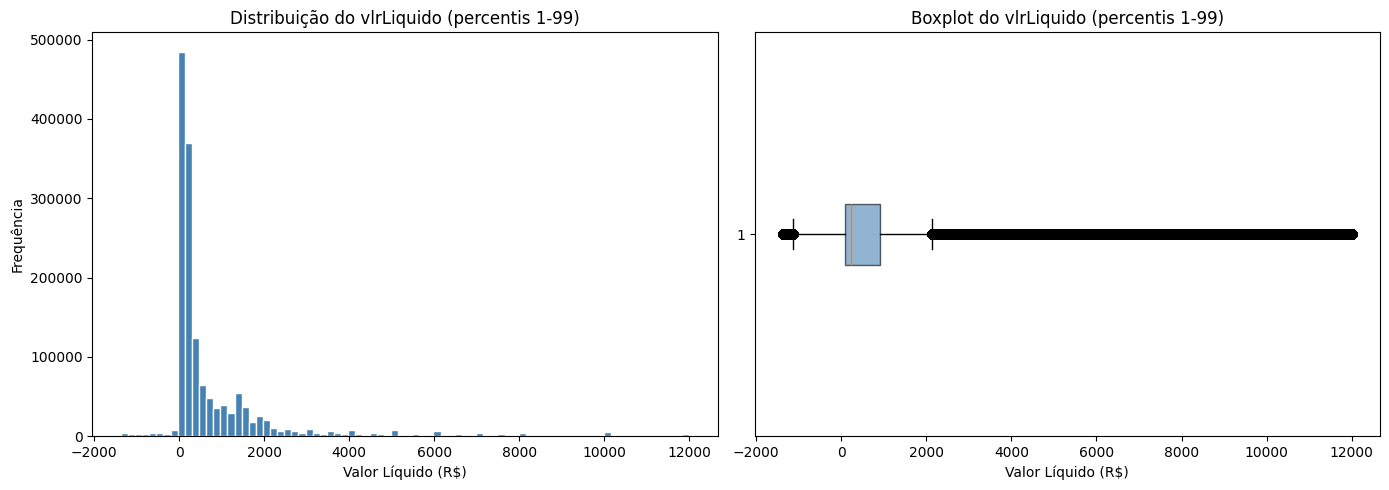


Valores negativos: 53,107
Valores zero: 689

Estatísticas descritivas:
count    1.556210e+06
mean     1.000330e+03
std      2.802054e+03
min     -6.683440e+03
25%      8.000000e+01
50%      2.359000e+02
75%      9.342775e+02
max      1.844280e+05
Name: vlrLiquido, dtype: float64


In [6]:
# Distribuição do vlrLiquido
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_plot = df_raw["vlrLiquido"].dropna()
dados_plot = dados_plot[dados_plot.between(dados_plot.quantile(0.01),
                                           dados_plot.quantile(0.99))]

axes[0].hist(dados_plot, bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição do vlrLiquido (percentis 1-99)")
axes[0].set_xlabel("Valor Líquido (R$)")
axes[0].set_ylabel("Frequência")

axes[1].boxplot(dados_plot, vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot do vlrLiquido (percentis 1-99)")
axes[1].set_xlabel("Valor Líquido (R$)")

plt.tight_layout()
plt.show()

print(f"\nValores negativos: {(df_raw['vlrLiquido'] < 0).sum():,}")
print(f"Valores zero: {(df_raw['vlrLiquido'] == 0).sum():,}")
print(f"\nEstatísticas descritivas:")
print(df_raw["vlrLiquido"].describe())

## 4.4 Volume de registros por ano
Foi verificado a consistência do volume de registros ao longo dos anos.

Variações bruscas podem indicar problemas na carga ou mudanças metodológicas na CEAP.

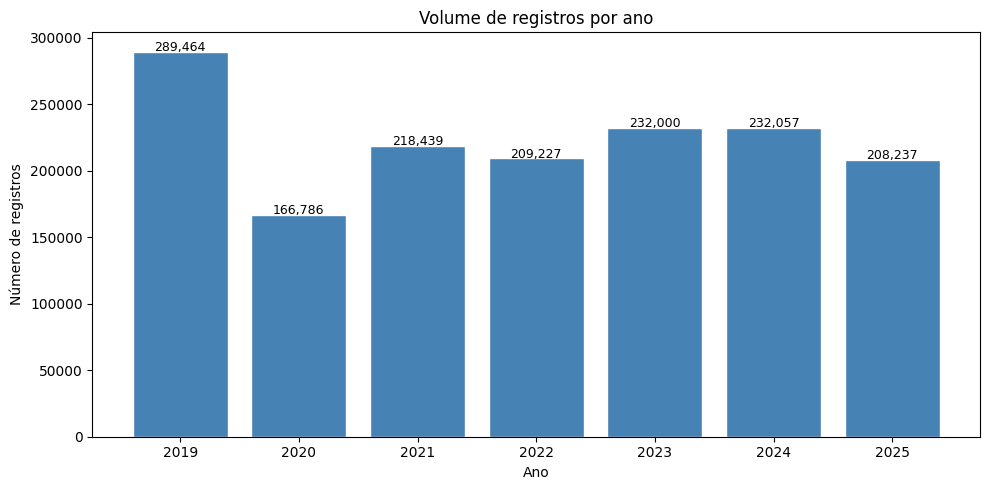

In [7]:
# Volume por ano
contagem_ano = df_raw["ano_carga"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(contagem_ano.index, contagem_ano.values, color="steelblue", edgecolor="white")
ax.set_title("Volume de registros por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de registros")
for i, (ano, val) in enumerate(contagem_ano.items()):
    ax.text(ano, val + 500, f"{val:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4.5 Distribuição por categoria de despesa
A CEAP possui 18 categorias fixas de despesa.

Entender a frequência de cada uma orienta a criação do z-score por categoria e revela quais categorias dominam o volume.

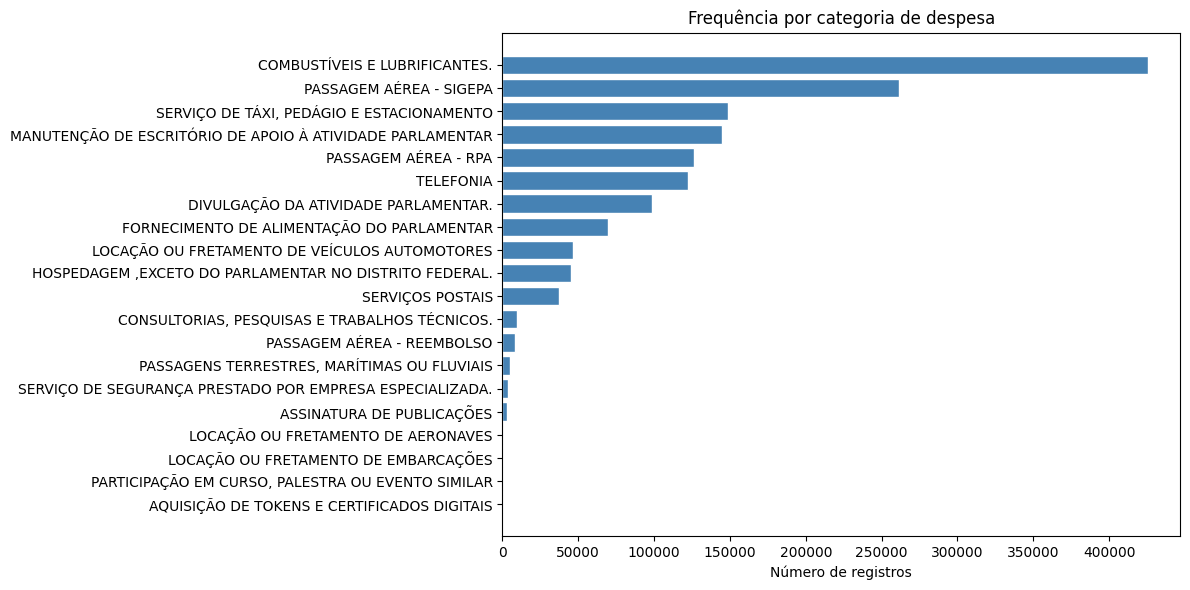

In [8]:
# Distribuição por categoria
contagem_cat = df_raw["txtDescricao"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(contagem_cat.index, contagem_cat.values, color="steelblue", edgecolor="white")
ax.set_title("Frequência por categoria de despesa")
ax.set_xlabel("Número de registros")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4.6 Distribuição por UF
Foi analisado o volume de despesas por estado.

Diferenças regionais justificam o agrupamento por UF no cálculo do z-score.

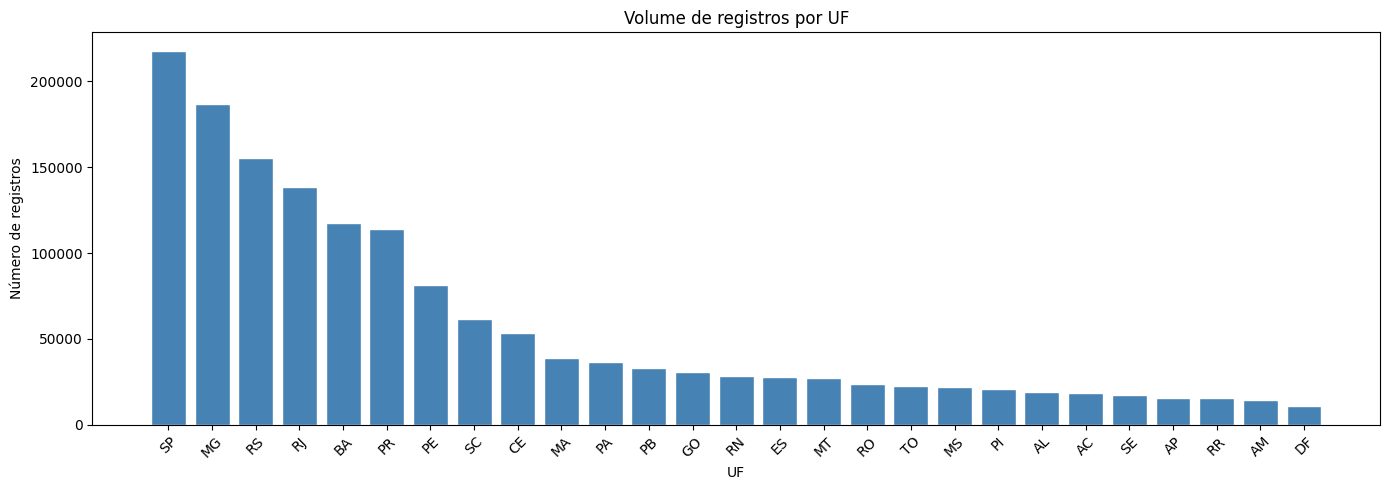

In [9]:
# Distribuição por UF
contagem_uf = df_raw["sgUF"].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(contagem_uf.index, contagem_uf.values, color="steelblue", edgecolor="white")
ax.set_title("Volume de registros por UF")
ax.set_xlabel("UF")
ax.set_ylabel("Número de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.7 Estatísticas descritivas do valorLiquido por categoria

Média, mediana e desvio padrão do valor líquido por categoria de despesa.

Essa análise antecipa o que o z-score vai capturar. Categorias com alto desvio
padrão tendem a gerar mais flags.

In [10]:
# Estatísticas por categoria
stats_cat = (df_raw.groupby("txtDescricao")["vlrLiquido"]
             .agg(["mean", "median", "std", "count"])
             .rename(columns={"mean": "média", "median": "mediana",
                               "std": "desvio_padrão", "count": "registros"})
             .sort_values("média", ascending=False)
             .round(2))

print(stats_cat.to_string())

                                                              média   mediana  desvio_padrão  registros
txtDescricao                                                                                           
LOCAÇÃO OU FRETAMENTO DE AERONAVES                         18112.08  15000.00       13200.09        642
CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.               9262.79   7500.00        7592.00       9674
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                        5227.07   2500.00        7750.25      98874
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES               4960.91   4381.44        2991.16      46764
LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES                        4733.83   6000.00        2464.29        321
PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR           3852.98   3120.00        2752.64         77
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA.    2248.56    349.60        3140.35       3662
PASSAGEM AÉREA - REEMBOLSO                                  1555

## Conclusões da EDA

Os principais achados desta análise exploratória:

**Valores ausentes**
- `txtCNPJCPF` ausente em 16,80% dos registros: Tratado como fornecedor desconhecido nas features de suspeição.
- `datEmissao` ausente em 3,07%: Registros sem data receberão `flag_fim_semana = 2` (ausência de data é tratada como sinal de suspeição, não como ausência neutra).
- `sgUF` ausente em 0,35% (~ 5.477 registros): Serão removidos na preparação dos dados.
- `txtFornecedor` ausente em 33 registros: Serão removidos.

**Valores negativos e zeros em `vlrLiquido`**
- Valores negativos: Representam glosas já processadas e compensações de passagens aéreas (SIGEPA), serão removidos.
- Valores zero: Despesas sem valor líquido, serão removidos.

**Volume por ano**
- Queda em 2020 (~ 167k registros) explicada pela pandemia, não indica problema na carga.
- 2025 com volume compatível com ano completo, conjunto de teste robusto.

**Categorias de despesa**
- Combustíveis domina com ~ 420k registros; aeronaves, embarcações e tokens têm volume muito baixo (< 700 registros), z-score estatisticamente instável nessas categorias.
- Categorias com alto desvio padrão relativo (Divulgação, Serviços Postais, Segurança) tenderão a gerar mais flags e serão interpretadas com cautela.

**Distribuição regional**
- SP concentra ~ 220k registros. Estados menores (RR, AP, AM) têm poucos registros.
- A variação regional confirma a necessidade do agrupamento por categoria + UF no z-score.
- Grupos com menos de 30 registros no treino serão sinalizados como estatisticamente instáveis.

**Distribuição do `vlrLiquido`**
- Forte assimetria positiva confirmada: mediana R\$235 vs média R\$1.000.
- Valor máximo expressivo: outlier candidato natural à anomalia.
- A assimetria justifica o uso de RobustScaler no pré-processamento.

# 5. Preparação dos dados

Esta seção realiza a limpeza do dataset bruto, preparando-o para a divisão treino/teste e a engenharia de features que ocorrerão na Seção 6.

Cada etapa segue um padrão de três passos:
1. Explicação da decisão e justificativa
2. Validação das premissas nos dados reais
3. Execução da etapa

As etapas executadas são:
- 5.1 Remoção de colunas com risco de leakage
- 5.2 Remoção de colunas irrelevantes para o MVP
- 5.3 Remoção de registros inválidos
- 5.4 Conversão de tipos
- 5.5 Verificação final do dataset limpo

Nenhuma estatística de referência é calculada aqui. Isso ocorre somente após a divisão treino/teste na Seção 6, para evitar vazamento de dados.

## 5.1 Remoção de colunas com risco de leakage

Leakage ocorre quando o modelo recebe durante o treino informações que não
estariam disponíveis no momento real de uso ou que entregam diretamente
a resposta que ele deveria descobrir sozinho.

As colunas candidatas à remoção são:

| Coluna | Risco identificado |
|---|---|
| `vlrDocumento` | Leakage matemático - `vlrLiquido = vlrDocumento - vlrGlosa` |
| `vlrGlosa` | Leakage matemático + temporal - resultado de auditoria já realizada |
| `numSubCota` | Redundância direta com `txtDescricao` |
| `txtDescricaoEspecificacao` | 72,66% ausente + derivada de `txtDescricao` |
| `numEspecificacaoSubCota` | Redundância direta com `txtDescricaoEspecificacao` |

Antes de remover, validamos empiricamente cada premissa nos dados reais.

In [11]:
# Validação 5.1: premissas de leakage

# Premissa 1: vlrLiquido = vlrDocumento - vlrGlosa
df_raw["_vlr_calc"] = df_raw["vlrDocumento"] - df_raw["vlrGlosa"]
df_raw["_diferenca"] = (df_raw["vlrLiquido"] - df_raw["_vlr_calc"]).abs()
pct_valida = (df_raw["_diferenca"] <= 0.01).mean() * 100
print("Premissa 1: vlrLiquido = vlrDocumento - vlrGlosa")
print(f"Confirmada em: {pct_valida:.2f}% dos registros")
print(f"Diferença máxima: R$ {df_raw['_diferenca'].max():.2f}")
df_raw.drop(columns=["_vlr_calc", "_diferenca"], inplace=True)

# Premissa 2: numSubCota mapeia 1:1 com txtDescricao
print("\nPremissa 2: numSubCota <-> txtDescricao (1:1?)")
mapa = df_raw.groupby("numSubCota")["txtDescricao"].nunique()
ambiguos = mapa[mapa > 1]
print(f"Mapeamento 1:1 confirmado" if len(ambiguos) == 0
      else f"{len(ambiguos)} valores ambíguos")

# Premissa 3: numEspecificacaoSubCota mapeia 1:1 com txtDescricaoEspecificacao
print("\nPremissa 3: numEspecificacaoSubCota <-> txtDescricaoEspecificacao (1:1?)")
mapa_esp = (df_raw.dropna(subset=["txtDescricaoEspecificacao"])
            .groupby("numEspecificacaoSubCota")["txtDescricaoEspecificacao"]
            .nunique())
ambiguos_esp = mapa_esp[mapa_esp > 1]
print(f"Mapeamento 1:1 confirmado" if len(ambiguos_esp) == 0
      else f"{len(ambiguos_esp)} valores ambíguos")

Premissa 1: vlrLiquido = vlrDocumento - vlrGlosa
Confirmada em: 99.83% dos registros
Diferença máxima: R$ 110237.40

Premissa 2: numSubCota <-> txtDescricao (1:1?)
Mapeamento 1:1 confirmado

Premissa 3: numEspecificacaoSubCota <-> txtDescricaoEspecificacao (1:1?)
Mapeamento 1:1 confirmado


In [12]:
# Execução 5.1: remoção de colunas com risco de leakage
colunas_leakage = [
    "vlrDocumento",               # leakage matemático com vlrLiquido
    "vlrGlosa",                   # leakage matemático + temporal
    "numSubCota",                 # redundante com txtDescricao
    "txtDescricaoEspecificacao",  # 72,66% ausente + derivada de txtDescricao
    "numEspecificacaoSubCota",    # redundante com txtDescricaoEspecificacao
]

df = df_raw.drop(columns=colunas_leakage)
print(f"Colunas removidas: {len(colunas_leakage)}")
print(f"Colunas restantes: {df.shape[1]}")

Colunas removidas: 5
Colunas restantes: 28


## 5.2 Remoção de colunas irrelevantes

As colunas abaixo foram inspecionadas nos dados reais e confirmadas como sem valor analítico para o MVP, por redundância, alta taxa de ausência, ou natureza puramente administrativa.

| Coluna | Critério | Evidência nos dados |
|---|---|---|
| `cpf` | Identificador pessoal | 1.145 únicos - substituído por `nuDeputadoId` |
| `ideCadastro` | Redundante com `nuDeputadoId` | Mapeamento 1:1 confirmado |
| `nuCarteiraParlamentar` | Identificador administrativo | 630 únicos, validade de uma legislatura |
| `nuLegislatura` | Redundante com `codLegislatura` | Mapeamento 1:1 confirmado |
| `txtNumero` | Alta cardinalidade, formatos heterogêneos | 691k únicos, formatos mistos |
| `txtPassageiro` | Alta taxa de ausência | 75% ausente |
| `txtTrecho` | Alta taxa de ausência | 75% ausente |
| `numLote` | Controle administrativo | 567k únicos, 13,85 lotes/deputado/mês |
| `numRessarcimento` | Sem informação útil | 68% ausente, único valor não nulo é 0 |
| `datPagamentoRestituicao` | Ausente na prática | 100% ausente |
| `vlrRestituicao` | Ausente na prática | 100% ausente |
| `ideDocumento` | Sem valor analítico | Múltiplos registros confirmados como rateios legítimos |
| `urlDocumento` | Link para comprovante | 35% ausente, sem valor analítico |
| `ano_carga` | Redundante com `numAno` | Zero divergências confirmadas |

Antes de remover, validamos as premissas de cada coluna nos dados reais.

In [13]:
# Validação das colunas candidatas a remoção por irrelevância

colunas_inspecionar = [
    "cpf", "ideCadastro", "nuCarteiraParlamentar", "nuLegislatura",
    "codLegislatura", "txtNumero", "txtPassageiro", "txtTrecho",
    "numLote", "numParcela", "numRessarcimento", "datPagamentoRestituicao",
    "vlrRestituicao", "ideDocumento", "urlDocumento"
]

for col in colunas_inspecionar:
    n_unicos = df_raw[col].nunique()
    n_ausentes = df_raw[col].isna().sum()
    pct_ausentes = n_ausentes / len(df_raw) * 100
    exemplos = df_raw[col].dropna().unique()[:3]
    print(f"\n{col}:")
    print(f" Únicos: {n_unicos} | Ausentes: {n_ausentes:,} ({pct_ausentes:.1f}%)")
    print(f" Exemplos: {exemplos}")


cpf:
 Únicos: 1145 | Ausentes: 5,621 (0.4%)
 Exemplos: [1.04813894e+10 6.80148020e+09 1.21337284e+10]

ideCadastro:
 Únicos: 1145 | Ausentes: 5,477 (0.4%)
 Exemplos: [ 4930.  4931. 62881.]

nuCarteiraParlamentar:
 Únicos: 631 | Ausentes: 5,477 (0.4%)
 Exemplos: [160. 408.  91.]

nuLegislatura:
 Únicos: 3 | Ausentes: 0 (0.0%)
 Exemplos: [2015 2019 2023]

codLegislatura:
 Únicos: 3 | Ausentes: 0 (0.0%)
 Exemplos: [55 56 57]

txtNumero:
 Únicos: 913681 | Ausentes: 27 (0.0%)
 Exemplos: ['693' '716' '723']

txtPassageiro:
 Únicos: 14034 | Ausentes: 1,166,933 (75.0%)
 Exemplos: ['ADRIANO DE AQUINO OLIVEIRA E SILVA;'
 'ROBERTO RICARDO VIZENTIN; ROBERTO RICARDO VIZENTIN;'
 'CRISVANO QUEIROZ ALVES;']

txtTrecho:
 Únicos: 6311 | Ausentes: 1,168,627 (75.1%)
 Exemplos: ['CGH/REC' 'REC/CGH' 'CGH/SDU']

numLote:
 Únicos: 567855 | Ausentes: 0 (0.0%)
 Exemplos: [1554246 1570078 1570503]

numParcela:
 Únicos: 2 | Ausentes: 0 (0.0%)
 Exemplos: [0 1]

numRessarcimento:
 Únicos: 1 | Ausentes: 1,063,370 (

Antes de confirmar a remoção de `ideDocumento` como coluna irrelevante,
validamos se seus registros duplicados representam erro de dado ou rateios/correções legítimas. O padrão varia por categoria: em passagens aéreas costuma ser compra + estorno parcial; em outras categorias, pode ser um ajuste direto de valor líquido na mesma nota fiscal, sem glosa registrada. Em ambos os casos, é uma duplicata legítima, não um erro, o que justifica remover a coluna sem tratar isso como um problema de qualidade de dado.

In [66]:
# Validação: duplicatas lógicas por ideDocumento

docs_duplos = (df_raw[df_raw["ideDocumento"] != 0]
               .groupby("ideDocumento")
               .size()
               .reset_index(name="n_registros")
               .query("n_registros > 1"))

print(f"Documentos com mais de 1 registro: {len(docs_duplos):,}")
print(f"\nDistribuição de registros por documento:")
print(docs_duplos["n_registros"].value_counts().sort_index())

print("\nCategorias envolvidas nos documentos com múltiplos registros")
docs_ids = docs_duplos["ideDocumento"].values
cats = (df_raw[df_raw["ideDocumento"].isin(docs_ids)]
        .groupby("txtDescricao")
        .size()
        .sort_values(ascending=False))
print(cats)

# Exemplo 1: passagem aérea (compra + estorno)
print("\nExemplo 1: PASSAGEM AÉREA - SIGEPA")
exemplo_aereo = docs_duplos.merge(
    df_raw[df_raw["txtDescricao"] == "PASSAGEM AÉREA - SIGEPA"][["ideDocumento"]],
    on="ideDocumento"
)["ideDocumento"].iloc[0]
print(df_raw[df_raw["ideDocumento"] == exemplo_aereo][
    ["txNomeParlamentar", "txtDescricao", "txtFornecedor",
     "vlrDocumento", "vlrGlosa", "vlrLiquido", "numMes", "numAno"]
].to_string())

# Exemplo 2: categoria fora de telefonia/manutenção/aéreo
print("\nExemplo 2: outra categoria")
exemplo_outro = (df_raw[
    (df_raw["ideDocumento"].isin(docs_ids)) &
    (~df_raw["txtDescricao"].isin([
        "TELEFONIA",
        "MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR",
        "PASSAGEM AÉREA - SIGEPA"
    ]))
]["ideDocumento"].iloc[0])
print(df_raw[df_raw["ideDocumento"] == exemplo_outro][
    ["txNomeParlamentar", "txtDescricao", "txtFornecedor",
     "vlrDocumento", "vlrGlosa", "vlrLiquido", "numMes", "numAno"]
].to_string())

Documentos com mais de 1 registro: 61,277

Distribuição de registros por documento:
n_registros
2    51605
3     8491
4      963
5      158
6       45
7        9
8        5
9        1
Name: count, dtype: int64

Categorias envolvidas nos documentos com múltiplos registros
txtDescricao
PASSAGEM AÉREA - SIGEPA                                      131789
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR       363
FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR                      334
SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO                       300
COMBUSTÍVEIS E LUBRIFICANTES.                                   265
TELEFONIA                                                       250
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                            152
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES                   106
HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.           72
CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.                    41
PASSAGEM AÉREA - REEMBOLSO         

In [15]:
# Validação: nuLegislatura e codLegislatura vs numAno
print("nuLegislatura")
print(f"Valores únicos: {sorted(df_raw['nuLegislatura'].unique())}")

print("\ncodLegislatura")
print(f"Valores únicos: {sorted(df_raw['codLegislatura'].unique())}")

print("\nMapeamento nuLegislatura <-> anos")
print(df_raw.groupby("nuLegislatura")["numAno"]
      .agg(["min", "max", "nunique"])
      .rename(columns={"min": "ano_min", "max": "ano_max", "nunique": "anos_distintos"}))

print("\nMapeamento codLegislatura <-> anos")
print(df_raw.groupby("codLegislatura")["numAno"]
      .agg(["min", "max", "nunique"])
      .rename(columns={"min": "ano_min", "max": "ano_max", "nunique": "anos_distintos"}))

print("\nnuLegislatura <-> codLegislatura (1:1?)")
mapa = df_raw.groupby("nuLegislatura")["codLegislatura"].nunique()
print(mapa)

nuLegislatura
Valores únicos: [np.int64(2015), np.int64(2019), np.int64(2023)]

codLegislatura
Valores únicos: [np.int64(55), np.int64(56), np.int64(57)]

Mapeamento nuLegislatura <-> anos
               ano_min  ano_max  anos_distintos
nuLegislatura                                  
2015              2019     2019               1
2019              2019     2023               5
2023              2023     2025               3

Mapeamento codLegislatura <-> anos
                ano_min  ano_max  anos_distintos
codLegislatura                                  
55                 2019     2019               1
56                 2019     2023               5
57                 2023     2025               3

nuLegislatura <-> codLegislatura (1:1?)
nuLegislatura
2015    1
2019    1
2023    1
Name: codLegislatura, dtype: int64


In [16]:
# Validação: numParcela
print("Valores únicos")
print(df_raw["numParcela"].value_counts().sort_index())

print("\nRegistros com numParcela = 1 (parcelados)")
parcelas = df_raw[df_raw["numParcela"] == 1]
print(f"Total: {len(parcelas):,} ({len(parcelas)/len(df_raw)*100:.2f}%)")

print("\nDistribuição por categoria")
print(parcelas["txtDescricao"].value_counts())

print("\nEstatísticas de vlrLiquido: parcelados vs não parcelados")
print(df_raw.groupby("numParcela")["vlrLiquido"]
      .agg(["mean", "median", "min", "max", "count"])
      .rename(columns={"mean": "média", "median": "mediana",
                       "min": "mínimo", "max": "máximo", "count": "registros"})
      .round(2))

print("\nAmostra de registros parcelados")
print(parcelas[["txNomeParlamentar", "txtDescricao", "txtFornecedor",
                "vlrDocumento", "vlrGlosa", "vlrLiquido",
                "numMes", "numAno"]].head(5).to_string())

Valores únicos
numParcela
0    1555560
1        650
Name: count, dtype: int64

Registros com numParcela = 1 (parcelados)
Total: 650 (0.04%)

Distribuição por categoria
txtDescricao
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                         218
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES                143
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR    130
COMBUSTÍVEIS E LUBRIFICANTES.                                 74
CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.                 26
TELEFONIA                                                     14
PASSAGEM AÉREA - REEMBOLSO                                    11
FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR                    10
HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.         8
SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO                      7
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA.       4
LOCAÇÃO OU FRETAMENTO DE AERONAVES                             2
ASSINATURA DE PUBLICAÇÕES              

In [17]:
# Validação: nuDeputadoId
print("Visão geral")
print(f"Valores únicos: {df_raw['nuDeputadoId'].nunique()}")
print(f"Ausentes: {df_raw['nuDeputadoId'].isna().sum()}")
print(f"Exemplos: {df_raw['nuDeputadoId'].unique()[:5]}")

print("\nnuDeputadoId vs ideCadastro (1:1?)")
mapa = df_raw.groupby("nuDeputadoId")["ideCadastro"].nunique()
print(f"nuDeputadoId com mais de 1 ideCadastro: {(mapa > 1).sum()}")

print("\nnuDeputadoId vs txNomeParlamentar")
mapa_nome = df_raw.groupby("nuDeputadoId")["txNomeParlamentar"].nunique()
print(f"nuDeputadoId com mais de 1 nome: {(mapa_nome > 1).sum()}")

print("\nRegistros por deputado")
registros_dep = df_raw.groupby("nuDeputadoId").size()
print(registros_dep.describe().round(2))

Visão geral
Valores únicos: 1166
Ausentes: 0
Exemplos: [2812 3175 3453 2713 3441]

nuDeputadoId vs ideCadastro (1:1?)
nuDeputadoId com mais de 1 ideCadastro: 0

nuDeputadoId vs txNomeParlamentar
nuDeputadoId com mais de 1 nome: 0

Registros por deputado
count    1166.00
mean     1334.66
std      1409.92
min         1.00
25%        75.00
50%      1014.50
75%      1991.00
max      8930.00
dtype: float64


In [18]:
# Validação: indTipoDocumento
print("Visão geral")
print(f"Valores únicos: {sorted(df_raw['indTipoDocumento'].unique())}")
print(f"Ausentes: {df_raw['indTipoDocumento'].isna().sum()}")

print("\nDistribuição de valores")
print(df_raw["indTipoDocumento"].value_counts().sort_index())

print("\nDistribuição por categoria de despesa")
print(df_raw.groupby("indTipoDocumento")["txtDescricao"]
      .value_counts()
      .groupby(level=0)
      .head(3))

print("\nEstatísticas de vlrLiquido por tipo de documento")
print(df_raw.groupby("indTipoDocumento")["vlrLiquido"]
      .agg(["mean", "median", "min", "max", "count"])
      .rename(columns={"mean": "média", "median": "mediana",
                       "min": "mínimo", "max": "máximo",
                       "count": "registros"})
      .round(2))

print("\nAmostra de tipo 2 (documento emitido no exterior)")
print(df_raw[df_raw["indTipoDocumento"] == 2][
    ["txNomeParlamentar", "txtDescricao", "txtFornecedor",
     "vlrLiquido", "numMes", "numAno"]
].head(5).to_string())

Visão geral
Valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Ausentes: 0

Distribuição de valores
indTipoDocumento
0    915412
1    267785
2       394
3       818
4    371801
Name: count, dtype: int64

Distribuição por categoria de despesa
indTipoDocumento  txtDescricao                                             
0                 PASSAGEM AÉREA - SIGEPA                                      261396
                  COMBUSTÍVEIS E LUBRIFICANTES.                                135012
                  PASSAGEM AÉREA - RPA                                         126187
1                 SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO                    129266
                  MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR     61340
                  SERVIÇOS POSTAIS                                              37037
2                 PASSAGEM AÉREA - REEMBOLSO                                      135
                  SERVIÇO DE TÁXI, PEDÁGIO E ESTA

In [19]:
# Validação: txtNumero e numLote
print("txtNumero")
print(f"Únicos: {df_raw['txtNumero'].nunique():,}")
print(f"Ausentes: {df_raw['txtNumero'].isna().sum():,}")
print(f"\nAmostra de valores:")
print(df_raw["txtNumero"].dropna().sample(20, random_state=42).values)

print("\ntxtNumero por categoria")
print(df_raw.groupby("txtDescricao")["txtNumero"]
      .agg(["nunique", "count"])
      .rename(columns={"nunique": "únicos", "count": "total"})
      .assign(pct_unicos=lambda x: (x["únicos"]/x["total"]*100).round(1))
      .sort_values("pct_unicos", ascending=False))

print("\nnumLote")
print(f"Únicos: {df_raw['numLote'].nunique():,}")
print(f"Ausentes: {df_raw['numLote'].isna().sum():,}")

print("\nnumLote: mesmos valores para registros do mesmo deputado/mês?")
exemplo = (df_raw.groupby(["txNomeParlamentar", "numMes", "numAno"])["numLote"]
           .nunique()
           .reset_index()
           .rename(columns={"numLote": "lotes_distintos"}))
print(f"Grupos deputado+mês+ano com mais de 1 lote: {(exemplo['lotes_distintos'] > 1).sum():,}")
print(f"Média de lotes por grupo: {exemplo['lotes_distintos'].mean():.2f}")

txtNumero
Únicos: 913,681
Ausentes: 27

Amostra de valores:
['6971636' '0007093545' '25806' '9133' '1272119384059' '30840' '224350'
 '4527' '4004081560761305' '42004' '866' '9572164667606' '005253' 'GJGTE'
 '33802' '9572124248557' '137' '47607' '9572151576345' '463714115']

txtNumero por categoria
                                                    únicos   total  pct_unicos
txtDescricao                                                                  
AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS             56      56       100.0
PASSAGEM AÉREA - REEMBOLSO                            7952    8011        99.3
SERVIÇOS POSTAIS                                     36987   37405        98.9
PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR       75      77        97.4
PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS           4675    4820        97.0
LOCAÇÃO OU FRETAMENTO DE AERONAVES                     602     642        93.8
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPEC...    3403    3662   

In [20]:
#Validação 5.2: premissas de colunas irrelevantes

# Premissa 1: ideCadastro é redundante com nuDeputadoId
print("Premissa 1: ideCadastro <-> nuDeputadoId (1:1?)")
mapa = df.groupby("nuDeputadoId")["ideCadastro"].nunique()
print(f"Mapeamento 1:1 confirmado" if (mapa > 1).sum() == 0
      else f"{(mapa > 1).sum()} IDs com mais de um ideCadastro")

# Premissa 2: nuLegislatura é redundante com codLegislatura
print("\nPremissa 2: nuLegislatura <-> codLegislatura (1:1?)")
mapa = df.groupby("codLegislatura")["nuLegislatura"].nunique()
print(f"Mapeamento 1:1 confirmado" if (mapa > 1).sum() == 0
      else f"{(mapa > 1).sum()} legislaturas com mais de um nuLegislatura")

# Premissa 3: ano_carga é redundante com numAno
print("\nPremissa 3: ano_carga <-> numAno (zero divergências?)")
divergentes = (df["ano_carga"] != df["numAno"]).sum()
print(f"Zero divergências confirmadas" if divergentes == 0
      else f"{divergentes:,} divergências encontradas")

# Premissa 4: numRessarcimento tem apenas 0 como valor não nulo
print("\nPremissa 4: numRessarcimento - valores únicos não nulos")
valores = df["numRessarcimento"].dropna().unique()
print(f"Valores únicos não nulos: {valores}")

# Premissa 5: ideDocumento - múltiplos registros são rateios legítimos
print("\n Premissa 5: ideDocumento - padrão de múltiplos registros")
docs_multiplos = (df[df["ideDocumento"] != 0]
                  .groupby("ideDocumento").size()
                  .reset_index(name="n")
                  .query("n > 1"))
print(f"Documentos com mais de 1 registro (excluindo id=0): {len(docs_multiplos):,}")
cats = df[df["ideDocumento"].isin(docs_multiplos["ideDocumento"])]["txtDescricao"].unique()
print(f"Categorias envolvidas: {cats}")

# Premissa 6: taxas de ausência confirmadas
print("\nPremissa 6: taxas de ausência")
cols_ausencia = ["txtPassageiro", "txtTrecho", "numRessarcimento",
                 "datPagamentoRestituicao", "vlrRestituicao", "urlDocumento"]
for col in cols_ausencia:
    pct = df[col].isna().mean() * 100
    print(f"{col}: {pct:.1f}% ausente")

Premissa 1: ideCadastro <-> nuDeputadoId (1:1?)
Mapeamento 1:1 confirmado

Premissa 2: nuLegislatura <-> codLegislatura (1:1?)
Mapeamento 1:1 confirmado

Premissa 3: ano_carga <-> numAno (zero divergências?)
Zero divergências confirmadas

Premissa 4: numRessarcimento - valores únicos não nulos
Valores únicos não nulos: [0.]

 Premissa 5: ideDocumento - padrão de múltiplos registros
Documentos com mais de 1 registro (excluindo id=0): 61,277
Categorias envolvidas: ['PASSAGEM AÉREA - SIGEPA' 'FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR'
 'MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR' 'TELEFONIA'
 'LOCAÇÃO OU FRETAMENTO DE AERONAVES'
 'SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO'
 'COMBUSTÍVEIS E LUBRIFICANTES.' 'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.'
 'SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA.'
 'ASSINATURA DE PUBLICAÇÕES'
 'HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.'
 'LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES'
 'CONSULTORIAS, PESQUISAS E TRABALHOS

In [21]:
# Execução 5.2: remoção de colunas irrelevantes
colunas_irrelevantes = [
    "cpf", "ideCadastro", "nuCarteiraParlamentar", "nuLegislatura",
    "txtNumero", "txtPassageiro", "txtTrecho", "numLote",
    "numRessarcimento", "datPagamentoRestituicao", "vlrRestituicao",
    "ideDocumento", "urlDocumento", "ano_carga",
]

df = df.drop(columns=colunas_irrelevantes)
print(f"Colunas removidas: {len(colunas_irrelevantes)}")
print(f"Colunas restantes: {df.shape[1]}")
print(f"\nColunas mantidas: {df.columns.tolist()}")

Colunas removidas: 14
Colunas restantes: 14

Colunas mantidas: ['txNomeParlamentar', 'sgUF', 'sgPartido', 'codLegislatura', 'txtDescricao', 'txtFornecedor', 'txtCNPJCPF', 'indTipoDocumento', 'datEmissao', 'vlrLiquido', 'numMes', 'numAno', 'numParcela', 'nuDeputadoId']


## 5.3 Remoção de registros inválidos

Removemos registros que comprometem a qualidade da análise por três critérios distintos. Antes de remover, validamos o conteúdo real de cada grupo e confirmamos que os critérios são mutuamente exclusivos.

| Critério | Justificativa |
|---|---|
| `vlrLiquido <= 0` | Glosas processadas e compensações de passagens aéreas (SIGEPA) |
| `sgUF` ausente | Lideranças partidárias sem UF - impossível calcular z-score por categoria + UF |
| `txtFornecedor` ausente | Erro de registro - impossível calcular features de fornecedor |

In [22]:
# Validação: registros inválidos
mask_vlr = df_raw["vlrLiquido"] <= 0
mask_uf = df_raw["sgUF"].isna()
mask_forn = df_raw["txtFornecedor"].isna()

print("Contagem individual por critério")
print(f"vlrLiquido <= 0:       {mask_vlr.sum():,} ({mask_vlr.mean()*100:.2f}%)")
print(f"sgUF ausente:          {mask_uf.sum():,} ({mask_uf.mean()*100:.2f}%)")
print(f"txtFornecedor ausente: {mask_forn.sum():,} ({mask_forn.mean()*100:.2f}%)")

print("\nSobreposição entre critérios")
print(f"vlrLiquido <= 0  AND  sgUF ausente:          {(mask_vlr & mask_uf).sum():,}")
print(f"vlrLiquido <= 0  AND  txtFornecedor ausente: {(mask_vlr & mask_forn).sum():,}")
print(f"sgUF ausente     AND  txtFornecedor ausente: {(mask_uf & mask_forn).sum():,}")
print(f"Todos simultaneamente:                       {(mask_vlr & mask_uf & mask_forn).sum():,}")

print("\nTotal de registros a remover (união)")
mask_total = mask_vlr | mask_uf | mask_forn
print(f"Registros a remover: {mask_total.sum():,} ({mask_total.mean()*100:.2f}%)")
print(f"Registros a manter:  {(~mask_total).sum():,} ({(~mask_total).mean()*100:.2f}%)")

Contagem individual por critério
vlrLiquido <= 0:       53,796 (3.46%)
sgUF ausente:          5,477 (0.35%)
txtFornecedor ausente: 33 (0.00%)

Sobreposição entre critérios
vlrLiquido <= 0  AND  sgUF ausente:          0
vlrLiquido <= 0  AND  txtFornecedor ausente: 1
sgUF ausente     AND  txtFornecedor ausente: 0
Todos simultaneamente:                       0

Total de registros a remover (união)
Registros a remover: 59,305 (3.81%)
Registros a manter:  1,496,905 (96.19%)


In [23]:
# Investigação da discrepância em vlrLiquido <= 0
print("Volume total carregado")
print(f"Registros: {len(df_raw):,}")

print("\nvlrLiquido: negativos, zeros e ausentes")
print(f"Negativos (< 0):  {(df_raw['vlrLiquido'] < 0).sum():,}")
print(f"Zeros (== 0):     {(df_raw['vlrLiquido'] == 0).sum():,}")
print(f"Ausentes (NaN):   {df_raw['vlrLiquido'].isna().sum():,}")
print(f"Total <= 0:       {(df_raw['vlrLiquido'] <= 0).sum():,}")

print("\nDistribuição de negativos por ano")
print(df_raw[df_raw["vlrLiquido"] < 0]
      .groupby("numAno")["vlrLiquido"]
      .agg(["count", "min", "max"])
      .rename(columns={"count": "registros", "min": "mínimo", "max": "máximo"}))

Volume total carregado
Registros: 1,556,210

vlrLiquido: negativos, zeros e ausentes
Negativos (< 0):  53,107
Zeros (== 0):     689
Ausentes (NaN):   0
Total <= 0:       53,796

Distribuição de negativos por ano
        registros   mínimo  máximo
numAno                            
2019        10742 -6605.57   -0.78
2020         4176 -4079.82   -1.00
2021         7592 -6666.00   -0.02
2022         3147 -5500.29   -0.33
2023         9383 -6683.44   -0.64
2024        10879 -4193.99   -0.66
2025         7188 -6252.04   -0.12


In [24]:
# Investigação da discrepância - volume por ano
print("Registros por ano na carga atual")
print(df_raw["ano_carga"].value_counts().sort_index())

print("\nRegistros por numAno (coluna nativa)")
print(df_raw["numAno"].value_counts().sort_index())

print("\nano_carga vs numAno - consistência")
divergentes = df_raw[df_raw["ano_carga"] != df_raw["numAno"]]
print(f"Registros onde ano_carga ≠ numAno: {len(divergentes):,}")

Registros por ano na carga atual
ano_carga
2019    289464
2020    166786
2021    218439
2022    209227
2023    232000
2024    232057
2025    208237
Name: count, dtype: int64

Registros por numAno (coluna nativa)
numAno
2019    289464
2020    166786
2021    218439
2022    209227
2023    232000
2024    232057
2025    208237
Name: count, dtype: int64

ano_carga vs numAno - consistência
Registros onde ano_carga ≠ numAno: 0


In [25]:
# Validação: registros com txtFornecedor ausente
mask_forn = df_raw["txtFornecedor"].isna()

print(f"Total de registros sem fornecedor: {mask_forn.sum():,}")

print("\nAmostra completa dos registros sem fornecedor")
print(df_raw[mask_forn][
    ["txNomeParlamentar", "sgUF", "sgPartido", "txtDescricao",
     "txtCNPJCPF", "vlrLiquido", "numMes", "numAno"]
].to_string())

Total de registros sem fornecedor: 33

Amostra completa dos registros sem fornecedor
               txNomeParlamentar sgUF      sgPartido                                               txtDescricao          txtCNPJCPF  vlrLiquido  numMes  numAno
14438               Sérgio Brito   BA            PSD              CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.  083.229.980/0015-2    10000.00      11    2019
16603            Wilson Santiago   PB   REPUBLICANOS                         LOCAÇÃO OU FRETAMENTO DE AERONAVES  283.674.620/0024-1     8250.00       9    2019
26658             Roberto Pessoa   CE           PSDB              CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.  200.781.330/0019-8    14900.00       9    2019
26663             Roberto Pessoa   CE           PSDB                       DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.  413.399.950/0010-5     1500.00      11    2019
56984         Edmilson Rodrigues   PA           PSOL                       DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.  17

In [26]:
# Validação 5.3: premissas de registros inválidos
mask_vlr  = df["vlrLiquido"] <= 0
mask_uf   = df["sgUF"].isna()
mask_forn = df["txtFornecedor"].isna()

# Premissa 1: contagens individuais
print("Premissa 1: contagens individuais")
print(f"vlrLiquido <= 0:       {mask_vlr.sum():,} ({mask_vlr.mean()*100:.2f}%)")
print(f"sgUF ausente:          {mask_uf.sum():,} ({mask_uf.mean()*100:.2f}%)")
print(f"txtFornecedor ausente: {mask_forn.sum():,} ({mask_forn.mean()*100:.2f}%)")

# Premissa 2: critérios mutuamente exclusivos
print("\nPremissa 2: sobreposição entre critérios")
print(f"vlrLiquido <= 0 AND sgUF ausente:          {(mask_vlr & mask_uf).sum():,}")
print(f"vlrLiquido <= 0 AND txtFornecedor ausente: {(mask_vlr & mask_forn).sum():,}")
print(f"sgUF ausente    AND txtFornecedor ausente: {(mask_uf & mask_forn).sum():,}")
print(f"Todos simultaneamente:                     {(mask_vlr & mask_uf & mask_forn).sum():,}")

# Premissa 3: conteúdo dos grupos removidos
print("\nPremissa 3: amostra de vlrLiquido <= 0")
print(df[mask_vlr][["txNomeParlamentar", "txtDescricao",
                     "txtFornecedor", "vlrLiquido", "numAno"]]
      .head(5).to_string())

print("\nPremissa 4: amostra de sgUF ausente")
print(df[mask_uf][["txNomeParlamentar", "sgUF", "sgPartido",
                    "txtDescricao", "vlrLiquido", "numAno"]]
      .head(5).to_string())

print("\nPremissa 5: amostra de txtFornecedor ausente")
print(df[mask_forn][["txNomeParlamentar", "txtDescricao",
                      "txtCNPJCPF", "vlrLiquido", "numAno"]]
      .head(5).to_string())

Premissa 1: contagens individuais
vlrLiquido <= 0:       53,796 (3.46%)
sgUF ausente:          5,477 (0.35%)
txtFornecedor ausente: 33 (0.00%)

Premissa 2: sobreposição entre critérios
vlrLiquido <= 0 AND sgUF ausente:          0
vlrLiquido <= 0 AND txtFornecedor ausente: 1
sgUF ausente    AND txtFornecedor ausente: 0
Todos simultaneamente:                     0

Premissa 3: amostra de vlrLiquido <= 0
     txNomeParlamentar             txtDescricao    txtFornecedor  vlrLiquido  numAno
920       SILVIO COSTA     PASSAGEM AÉREA - RPA  Cia Aérea - TAM    -1175.17    2019
1759     Fausto Pinato  PASSAGEM AÉREA - SIGEPA              GOL    -1318.71    2019
1763     Fausto Pinato  PASSAGEM AÉREA - SIGEPA              GOL    -1703.52    2019
1766     Fausto Pinato  PASSAGEM AÉREA - SIGEPA              GOL      -30.67    2019
1772     Fausto Pinato  PASSAGEM AÉREA - SIGEPA              GOL    -1362.88    2019

Premissa 4: amostra de sgUF ausente
  txNomeParlamentar sgUF sgPartido              

In [27]:
# Execução 5.3: remoção de registros inválidos
shape_antes = df.shape[0]

df = df[df["vlrLiquido"] > 0]
df = df[df["sgUF"].notna()]
df = df[df["txtFornecedor"].notna()]
df = df.reset_index(drop=True)

shape_depois = df.shape[0]
removidos = shape_antes - shape_depois
print(f"Registros antes: {shape_antes:,}")
print(f"Registros após:  {shape_depois:,}")
print(f"Removidos:       {removidos:,} ({removidos/shape_antes*100:.2f}%)")

Registros antes: 1,556,210
Registros após:  1,496,905
Removidos:       59,305 (3.81%)


## 5.4 Conversão de tipos

A `datEmissao` está armazenada como texto no formato ISO 8601 (`YYYY-MM-DDTHH:MM:SS`). A conversão para `datetime` é necessária para calcular a feature `flag_fim_semana` na Seção 6.

Registros com data ausente ou inválida receberão `NaT` e serão tratados com `flag_fim_semana = 2` na engenharia de features, a ausência de data é tratada como sinal de suspeição, não como ausência neutra.

In [28]:
# Validação: formato real de datEmissao
print("Visão geral")
print(f"Tipo atual: {df_raw['datEmissao'].dtype}")
print(f"Ausentes: {df_raw['datEmissao'].isna().sum():,}")

print("\nAmostra de valores únicos")
print(df_raw["datEmissao"].dropna().unique()[:20])

print("\nFormatos distintos encontrados")
formatos = (df_raw["datEmissao"]
            .dropna()
            .astype(str)
            .str.replace(r'\d', 'N', regex=True)
            .value_counts()
            .head(10))
print(formatos)

print("\nTeste de conversão com pd.to_datetime")
convertido = pd.to_datetime(df_raw["datEmissao"], errors="coerce")
nat_count = convertido.isna().sum()
ausentes_originais = df_raw["datEmissao"].isna().sum()
falhas_conversao = nat_count - ausentes_originais
print(f"NaT após conversão:       {nat_count:,}")
print(f"Ausentes originais:       {ausentes_originais:,}")
print(f"Falhas de conversão:      {falhas_conversao:,}")

Visão geral
Tipo atual: object
Ausentes: 47,837

Amostra de valores únicos
['2019-01-16T00:00:00' '2019-02-04T00:00:00' '2019-02-25T00:00:00'
 '2019-03-28T00:00:00' '2019-05-07T00:00:00' '2019-06-04T00:00:00'
 '2019-02-21T00:00:00' '2019-11-07T23:00:00' '2019-03-01T00:00:00'
 '2019-05-02T00:00:00' '2019-06-03T00:00:00' '2019-07-02T00:00:00'
 '2019-08-06T00:00:00' '2019-09-09T00:00:00' '2019-12-17T00:00:00'
 '2019-06-06T00:00:00' '2019-06-25T00:00:00' '2019-06-26T00:00:00'
 '2019-07-04T00:00:00' '2019-07-12T00:00:00']

Formatos distintos encontrados
datEmissao
NNNN-NN-NNTNN:NN:NN    1508373
Name: count, dtype: int64

Teste de conversão com pd.to_datetime
NaT após conversão:       47,837
Ausentes originais:       47,837
Falhas de conversão:      0


In [29]:
# Validação 5.4: premissas de conversão de tipos

# Premissa 1: formato único e consistente
print("Premissa 1: formato de datEmissao")
formatos = (df["datEmissao"]
            .dropna()
            .astype(str)
            .str.replace(r'\d', 'N', regex=True)
            .value_counts())
print(formatos)

# Premissa 2: zero falhas de conversão esperadas
print("\nPremissa 2: teste de conversão")
convertido = pd.to_datetime(df["datEmissao"], errors="coerce")
falhas = convertido.isna().sum() - df["datEmissao"].isna().sum()
print(f"Falhas de conversão: {falhas:,}")
print(f"Zero falhas confirmadas" if falhas == 0
      else f"{falhas:,} valores não parseáveis")

Premissa 1: formato de datEmissao
datEmissao
NNNN-NN-NNTNN:NN:NN    1449068
Name: count, dtype: int64

Premissa 2: teste de conversão
Falhas de conversão: 0
Zero falhas confirmadas


In [30]:
# Execução 5.4: conversão de tipos
df["datEmissao"] = pd.to_datetime(df["datEmissao"], errors="coerce")

nat_count = df["datEmissao"].isna().sum()
print(f"Tipo de datEmissao: {df['datEmissao'].dtype}")
print(f"Registros com datEmissao ausente/inválida: {nat_count:,}")
print(f"Esses registros receberão flag_fim_semana = 2 na Seção 6")

Tipo de datEmissao: datetime64[ns]
Registros com datEmissao ausente/inválida: 47,837
Esses registros receberão flag_fim_semana = 2 na Seção 6


## 5.5 Verificação final do dataset limpo

Confirmação do estado final do dataset após todas as etapas de limpeza,
antes de avançar para a divisão treino/teste.

In [31]:
# Verificação final
print(f"Shape final: {df.shape[0]:,} registros x {df.shape[1]} colunas")

print(f"\nColunas mantidas ({df.shape[1]}):")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

print(f"\nValores ausentes restantes:")
ausentes = df.isnull().sum()
ausentes = ausentes[ausentes > 0]
if len(ausentes) > 0:
    for col, n in ausentes.items():
        print(f"  {col}: {n:,} ({n/len(df)*100:.2f}%)")
else:
    print("  Nenhum nas colunas de interesse")

print(f"\nAmostra:")
df.head(3)

Shape final: 1,496,905 registros x 14 colunas

Colunas mantidas (14):
  txNomeParlamentar: object
  sgUF: object
  sgPartido: object
  codLegislatura: int64
  txtDescricao: object
  txtFornecedor: object
  txtCNPJCPF: object
  indTipoDocumento: int64
  datEmissao: datetime64[ns]
  vlrLiquido: float64
  numMes: int64
  numAno: int64
  numParcela: int64
  nuDeputadoId: int64

Valores ausentes restantes:
  txtCNPJCPF: 223,017 (14.90%)
  datEmissao: 47,837 (3.20%)

Amostra:


,txNomeParlamentar,sgUF,sgPartido,codLegislatura,txtDescricao,txtFornecedor,txtCNPJCPF,indTipoDocumento,datEmissao,vlrLiquido,numMes,numAno,numParcela,nuDeputadoId
0,SILVIO COSTA,PE,AVANTE,55,COMBUSTÍVEIS E LUBRIFICANTES.,POSTO SAO SEBASTIAO LTDA,111.881.330/0015-0,4,2019-01-23,5990.37,1,2019,0,1973
1,SILVIO COSTA,PE,AVANTE,55,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.",PLURAL PESQUISAS & MARKETING LTDA,079.064.680/0019-9,0,2019-01-30,22000.00,1,2019,0,1973
2,SILVIO COSTA,PE,AVANTE,55,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,Editora Paradox Zero Eireli Me,146.780.750/0013-0,4,2019-01-18,5500.00,1,2019,0,1973


# 6. Divisão treino/teste, Feature Engineering e Normalização

Esta seção executa três blocos em sequência obrigatória:

1. **Divisão temporal** - Separação dos dados em treino (2019-2024) e teste (2025).
2. **Feature engineering** - Cálculo das 7 features de suspeição com estatísticas exclusivamente do treino, aplicadas ao teste.
3. **Normalização** - Ajuste do RobustScaler no treino, aplicado ao teste.

A ordem é crítica: nenhuma estatística de referência pode ser calculada antes da divisão, sob risco de vazamento de dados do teste para o treino.

## 6.1 Divisão temporal

A divisão segue o corte temporal definido na Seção 1:

| Conjunto | Anos | Finalidade |
|---|---|---|
| Treino | 2019-2024 | Aprender o padrão de normalidade |
| Teste | 2025 | Avaliar o modelo em dados não vistos |

A divisão temporal foi escolhida em vez da divisão aleatória porque:
- Simula o uso real do modelo, treinado no passado, aplicado no futuro.
- Elimina vazamento temporal, nenhum dado futuro contamina o treino.
- As estatísticas de referência das features refletem apenas o histórico disponível no momento de treinamento.

**Limitação:** o modelo não deve ser aplicado em dados anteriores a 2019. As estatísticas de referência foram calculadas com dados de 2019-2024 e não são válidas para períodos anteriores.

In [32]:
# Validação 6.1: premissas da divisão temporal

# Premissa 1: valores únicos de numAno
print("Premissa 1: anos disponíveis no dataset")
anos = sorted(df["numAno"].unique())
print(f"Anos encontrados: {anos}")
esperados = list(range(2019, 2026))
inesperados = [a for a in anos if a not in esperados]
print(f"Anos inesperados: {inesperados if inesperados else 'Nenhum'}")

# Premissa 2: volumes por ano
print("\nPremissa 2: volume de registros por ano")
print(df["numAno"].value_counts().sort_index()
      .rename("registros").to_frame()
      .assign(conjunto=lambda x: x.index.map(
          lambda a: "TREINO" if a <= 2024 else "TESTE")))

# Premissa 3: categorias presentes em ambos os conjuntos
print("\nPremissa 3: categorias no treino vs teste")
cats_treino = set(df[df["numAno"] <= 2024]["txtDescricao"].unique())
cats_teste  = set(df[df["numAno"] == 2025]["txtDescricao"].unique())
cats_so_treino = cats_treino - cats_teste
cats_so_teste  = cats_teste  - cats_treino
print(f"Categorias só no treino: {cats_so_treino if cats_so_treino else 'Nenhuma'}")
print(f"Categorias só no teste:  {cats_so_teste  if cats_so_teste  else 'Nenhuma'}")

# Premissa 4: UFs presentes em ambos os conjuntos
print("\nPremissa 4: UFs no treino vs teste")
ufs_treino = set(df[df["numAno"] <= 2024]["sgUF"].unique())
ufs_teste  = set(df[df["numAno"] == 2025]["sgUF"].unique())
ufs_so_treino = ufs_treino - ufs_teste
ufs_so_teste  = ufs_teste  - ufs_treino
print(f"UFs só no treino: {ufs_so_treino if ufs_so_treino else 'Nenhuma'}")
print(f"UFs só no teste:  {ufs_so_teste  if ufs_so_teste  else 'Nenhuma'}")

Premissa 1: anos disponíveis no dataset
Anos encontrados: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Anos inesperados: Nenhum

Premissa 2: volume de registros por ano
        registros conjunto
numAno                    
2019       277544   TREINO
2020       162078   TREINO
2021       209933   TREINO
2022       205408   TREINO
2023       221668   TREINO
2024       220213   TREINO
2025       200061    TESTE

Premissa 3: categorias no treino vs teste
Categorias só no treino: {'CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.'}
Categorias só no teste:  Nenhuma

Premissa 4: UFs no treino vs teste
UFs só no treino: Nenhuma
UFs só no teste:  Nenhuma


In [33]:
# Execução 6.1: divisão temporal
df_train = df[df["numAno"] <= 2024].copy().reset_index(drop=True)
df_test  = df[df["numAno"] == 2025].copy().reset_index(drop=True)

# Confirmação de ausência de vazamento
assert df_train["numAno"].max() <= 2024, "Vazamento: dados de 2025 no treino"
assert df_test["numAno"].min() == 2025,  "Vazamento: dados anteriores a 2025 no teste"

print(f"Treino: {df_train.shape[0]:,} registros | {df_train['numAno'].min()}-{df_train['numAno'].max()}")
print(f"Teste:  {df_test.shape[0]:,} registros  | {df_test['numAno'].min()}-{df_test['numAno'].max()}")
print(f"\nSem vazamento confirmado")

Treino: 1,296,844 registros | 2019-2024
Teste:  200,061 registros  | 2025-2025

Sem vazamento confirmado


## 6.2 Feature 1: z_score_valor

Mede quantos desvios padrão o `vlrLiquido` de uma despesa se afasta da média do seu grupo `txtDescricao` + `sgUF` no treino.

`z = (vlrLiquido - média_grupo) / desvio_padrão_grupo`

**Padrão suspeito:** `|z| > 3` Apenas ~ 0,3% dos valores numa distribuição normal estão além desse limiar.

**Grupos com menos de 30 registros no treino**: Receberão `z_score_valor = NaN`
- Média e desvio padrão calculados sobre poucos registros são estatisticamente instáveis e produziriam flags não confiáveis.

**Combinações `txtDescricao` + `sgUF` ausentes no treino**: Também receberão
`z_score_valor = NaN`, sem referência histórica não é possível calcular o desvio.

In [34]:
# Validação 6.2: premissas do z_score_valor

# Premissa 1: distribuição de tamanho dos grupos no treino
print("Premissa 1: tamanho dos grupos txtDescricao + sgUF no treino")
tamanho_grupos = (df_train.groupby(["txtDescricao", "sgUF"])
                  .size()
                  .reset_index(name="n_registros"))

print(f"Total de grupos: {len(tamanho_grupos):,}")
print(f"Grupos com < 30 registros: {(tamanho_grupos['n_registros'] < 30).sum():,}")
print(f"Grupos com >= 30 registros: {(tamanho_grupos['n_registros'] >= 30).sum():,}")
print(f"\nDistribuição de tamanho dos grupos:")
print(tamanho_grupos["n_registros"].describe().round(2))

print(f"\nGrupos com menos de 30 registros:")
print(tamanho_grupos[tamanho_grupos["n_registros"] < 30]
      .sort_values("n_registros")
      .to_string())

# Premissa 2: cobertura no teste
print("\nPremissa 2: grupos no teste ausentes no treino")
grupos_treino = set(df_train.groupby(["txtDescricao", "sgUF"]).groups.keys())
grupos_teste  = set(df_test.groupby(["txtDescricao", "sgUF"]).groups.keys())
grupos_ausentes = grupos_teste - grupos_treino
print(f"Grupos no teste sem referência no treino: {len(grupos_ausentes):,}")
if grupos_ausentes:
    for g in sorted(grupos_ausentes):
        print(f"  {g}")

Premissa 1: tamanho dos grupos txtDescricao + sgUF no treino
Total de grupos: 482
Grupos com < 30 registros: 81
Grupos com >= 30 registros: 401

Distribuição de tamanho dos grupos:
count      482.00
mean      2690.55
std       5434.42
min          1.00
25%         94.75
50%        657.50
75%       2661.25
max      43618.00
Name: n_registros, dtype: float64

Grupos com menos de 30 registros:
                                                 txtDescricao sgUF  n_registros
0                 AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS   AC            1
1                 AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS   BA            1
2                 AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS   CE            1
3                 AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS   MA            1
5                 AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS   PB            1
6                 AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS   PE            1
9                 AQUISIÇÃO DE TOKENS E CERTIF

In [35]:
# Execução 6.2: z_score_valor

# Calcular média e desvio padrão por grupo no treino
stats_grupo = (df_train.groupby(["txtDescricao", "sgUF"])["vlrLiquido"]
               .agg(["mean", "std", "count"])
               .rename(columns={"mean": "media_grupo",
                                 "std": "std_grupo",
                                 "count": "n_grupo"})
               .reset_index())

# Marcar grupos instáveis
stats_grupo.loc[stats_grupo["n_grupo"] < 30, ["media_grupo", "std_grupo"]] = None

def calcular_z_score(df_input, stats):
    """Calcula z_score_valor usando estatísticas do treino."""
    df_merged = df_input.merge(stats[["txtDescricao", "sgUF",
                                       "media_grupo", "std_grupo"]],
                                on=["txtDescricao", "sgUF"],
                                how="left")
    z = ((df_merged["vlrLiquido"] - df_merged["media_grupo"])
         / df_merged["std_grupo"])
    return z.values

df_train["z_score_valor"] = calcular_z_score(df_train, stats_grupo)
df_test["z_score_valor"]  = calcular_z_score(df_test, stats_grupo)

# Verificação
print("Treino")
print(f"NaN: {df_train['z_score_valor'].isna().sum():,} ({df_train['z_score_valor'].isna().mean()*100:.2f}%)")
print(df_train["z_score_valor"].describe().round(2))

print("\nTeste")
print(f"NaN: {df_test['z_score_valor'].isna().sum():,} ({df_test['z_score_valor'].isna().mean()*100:.2f}%)")
print(df_test["z_score_valor"].describe().round(2))

Treino
NaN: 602 (0.05%)
count    1296242.00
mean          -0.00
std            1.00
min           -5.20
25%           -0.43
50%           -0.20
75%            0.18
max           68.10
Name: z_score_valor, dtype: float64

Teste
NaN: 60 (0.03%)
count    200001.00
mean          0.13
std           1.12
min          -3.08
25%          -0.35
50%          -0.12
75%           0.26
max          37.91
Name: z_score_valor, dtype: float64


## 6.3 Feature 2: conc_fornecedor

Mede o percentual do gasto total de um deputado (no treino) concentrado em um único fornecedor.

`conc_fornecedor = maior gasto com 1 fornecedor / gasto total do deputado`

**Padrão suspeito:** concentração > 80% pode indicar dependência anômala de um único fornecedor, um padrão atípico frente à diversidade de fornecedores esperada num gabinete parlamentar.

**Identificação do fornecedor por chave composta:**

`txtCNPJCPF` isoladamente não é confiável, pois 14,90% dos registros têm o campo
ausente (concentrado em `PASSAGEM AÉREA - SIGEPA`), e 7,72% usam códigos
placeholder do tipo `000.000.000/xxxx-x`, atribuídos a fornecedores estrangeiros sem CNPJ brasileiro (confirmado: o código `000.000.000/0001-0`
aparece associado a nomes como "Sheraton Montevideo" e "Restaurante Garcia -
Uruguay", claramente fornecedores distintos, não um único fornecedor).

`txtFornecedor` isoladamente também não é confiável, pois o mesmo fornecedor real aparece com múltiplas grafias (ex.: "Telefônica Brasil S.A." aparece em pelo menos 10 variações de escrita sob o mesmo CNPJ válido).

Por isso, a chave de fornecedor é definida linha a linha:
- Se `txtCNPJCPF` é válido (não nulo e não bate no padrão `000.000.000/...`) -> usa `txtCNPJCPF`.
- Caso contrário -> usa `txtFornecedor` como fallback

**Caso especial:** deputados com menos de 30 registros no treino (mesmo critério de estabilidade usado em `z_score_valor`) recebem `conc_fornecedor = NaN`, a razão calculada sobre poucos registros é estatisticamente instável.

**Limitação conhecida:** para os ~ 22,6% de registros que caem no fallback por
nome (SIGEPA + placeholders), pode persistir alguma fragmentação por grafia não normalizada. Corrigir isso exigiria fuzzy matching de texto, complexidade desnecessária para o escopo do MVP. Documentado como limitação na Seção 13.1.

**Nota sobre a natureza da feature:** diferente de `z_score_valor` (que varia
por registro individual), `conc_fornecedor` é calculada por deputado, onde todos
os registros do mesmo deputado recebem o mesmo valor. Por isso, o mínimo e o máximo observados no treino e no teste tendem a coincidir: o deputado com a razão mais alta/mais baixa no treino "carrega" esse mesmo valor extremo para suas linhas no teste, já que a maioria dos deputados aparece em ambos os conjuntos. Isso é um comportamento estrutural esperado, não uma coincidência estatística.

In [36]:
# Validação 6.3: premissas do conc_fornecedor

# Premissa 1: ausência de txtCNPJCPF concentrada em PASSAGEM AÉREA - SIGEPA
print("Premissa 1: ausência de txtCNPJCPF")
pct_ausente = df_train["txtCNPJCPF"].isna().mean() * 100
print(f"Registros com txtCNPJCPF ausente: {df_train['txtCNPJCPF'].isna().sum():,} ({pct_ausente:.2f}%)")
print(f"\nCategorias associadas aos ausentes:")
print(df_train[df_train["txtCNPJCPF"].isna()]["txtDescricao"].value_counts())

# Premissa 2: padrão placeholder "000.000.000/xxxx-x" é usado para fornecedores estrangeiros
print("\nPremissa 2: padrão placeholder de CNPJ")
padrao_zeros = df_train["txtCNPJCPF"].str.match(r"^000\.000\.000", na=False)
pct_placeholder = padrao_zeros.mean() * 100
print(f"Registros com CNPJ placeholder: {padrao_zeros.sum():,} ({pct_placeholder:.2f}%)")
print(f"\nExemplo - fornecedores distintos sob o placeholder mais comum:")
print(df_train[df_train["txtCNPJCPF"] == "000.000.000/0001-0"]["txtFornecedor"]
      .drop_duplicates().head(5).to_string(index=False))

# Premissa 3: CNPJ válido é confiável mesmo com variação de grafia no nome
print("\nPremissa 3: CNPJ válido agrupa corretamente fornecedor com grafia variável")
cnpj_exemplo = "025.581.570/0016-2"
n_grafias = df_train[df_train["txtCNPJCPF"] == cnpj_exemplo]["txtFornecedor"].nunique()
print(f"CNPJ {cnpj_exemplo} ({df_train[df_train['txtCNPJCPF'] == cnpj_exemplo]['txtFornecedor'].iloc[0]}):")
print(f"  {n_grafias} grafias distintas de nome sob o mesmo CNPJ válido")

# Premissa 4: impacto combinado - % de registros que dependerão do fallback por nome
print("\nPremissa 4: impacto do fallback")
cnpj_invalido = df_train["txtCNPJCPF"].isna() | padrao_zeros
pct_fallback = cnpj_invalido.mean() * 100
print(f"Registros que usarão txtFornecedor como fallback: {cnpj_invalido.sum():,} ({pct_fallback:.2f}%)")
print(f"Deputados com ao menos 1 registro em fallback: {df_train[cnpj_invalido]['nuDeputadoId'].nunique():,} de {df_train['nuDeputadoId'].nunique():,}")

Premissa 1: ausência de txtCNPJCPF
Registros com txtCNPJCPF ausente: 193,065 (14.89%)

Categorias associadas aos ausentes:
txtDescricao
PASSAGEM AÉREA - SIGEPA    193065
Name: count, dtype: int64

Premissa 2: padrão placeholder de CNPJ
Registros com CNPJ placeholder: 100,175 (7.72%)

Exemplo - fornecedores distintos sob o placeholder mais comum:
              cafe bar tabare
         ES MERCAT, RESTO BAR
 Garcia Pariila Clasica y bar
Garcia Parrilla Clasica Y Bar
           RESTAURANTE GARCIA

Premissa 3: CNPJ válido agrupa corretamente fornecedor com grafia variável
CNPJ 025.581.570/0016-2 (Telefônica Brasil S. A. VIVO):
  117 grafias distintas de nome sob o mesmo CNPJ válido

Premissa 4: impacto do fallback
Registros que usarão txtFornecedor como fallback: 293,240 (22.61%)
Deputados com ao menos 1 registro em fallback: 1,123 de 1,123


In [37]:
# Execução 6.3: conc_fornecedor

def calcular_chave_fornecedor(df_input):
    """Define a chave de fornecedor: CNPJ quando válido, nome como fallback."""
    cnpj_valido = (df_input["txtCNPJCPF"].notna()
                   & ~df_input["txtCNPJCPF"].str.match(r"^000\.000\.000", na=False))
    return df_input["txtFornecedor"].where(~cnpj_valido, df_input["txtCNPJCPF"])

df_train["chave_fornecedor"] = calcular_chave_fornecedor(df_train)
df_test["chave_fornecedor"]  = calcular_chave_fornecedor(df_test)

# Gasto total por deputado + fornecedor, calculado apenas no treino
gasto_dep_fornecedor = (df_train.groupby(["nuDeputadoId", "chave_fornecedor"])["vlrLiquido"]
                         .sum()
                         .reset_index(name="gasto_fornecedor"))

# Gasto total e nº de registros por deputado no treino
stats_dep = (df_train.groupby("nuDeputadoId")
             .agg(gasto_total_dep=("vlrLiquido", "sum"),
                  n_registros_dep=("vlrLiquido", "count"))
             .reset_index())

# Maior gasto com um único fornecedor, por deputado
maior_gasto_fornecedor = (gasto_dep_fornecedor.groupby("nuDeputadoId")["gasto_fornecedor"]
                           .max()
                           .reset_index(name="maior_gasto_fornecedor"))

# Junta e calcula a concentração
stats_conc = stats_dep.merge(maior_gasto_fornecedor, on="nuDeputadoId")
stats_conc["conc_fornecedor"] = (stats_conc["maior_gasto_fornecedor"]
                                  / stats_conc["gasto_total_dep"])

# Deputados com menos de 30 registros no treino -> estatisticamente instável
stats_conc.loc[stats_conc["n_registros_dep"] < 30, "conc_fornecedor"] = None

def aplicar_conc_fornecedor(df_input, stats):
    df_merged = df_input.merge(stats[["nuDeputadoId", "conc_fornecedor"]],
                                on="nuDeputadoId", how="left")
    return df_merged["conc_fornecedor"].values

df_train["conc_fornecedor"] = aplicar_conc_fornecedor(df_train, stats_conc)
df_test["conc_fornecedor"]  = aplicar_conc_fornecedor(df_test, stats_conc)

# Verificação
print("Treino")
print(f"NaN: {df_train['conc_fornecedor'].isna().sum():,} ({df_train['conc_fornecedor'].isna().mean()*100:.2f}%)")
print(df_train["conc_fornecedor"].describe().round(3))

print("\nTeste")
print(f"NaN: {df_test['conc_fornecedor'].isna().sum():,} ({df_test['conc_fornecedor'].isna().mean()*100:.2f}%)")
print(df_test["conc_fornecedor"].describe().round(3))

deps_teste_ausentes_treino = df_test[df_test["conc_fornecedor"].isna()]["nuDeputadoId"].nunique()
print(f"\nDeputados no teste sem conc_fornecedor calculável: {deps_teste_ausentes_treino:,}")

Treino
NaN: 2,819 (0.22%)
count    1294025.000
mean           0.195
std            0.081
min            0.072
25%            0.138
50%            0.180
75%            0.227
max            0.827
Name: conc_fornecedor, dtype: float64

Teste
NaN: 3,891 (1.94%)
count    196170.000
mean          0.203
std           0.083
min           0.072
25%           0.142
50%           0.187
75%           0.243
max           0.827
Name: conc_fornecedor, dtype: float64

Deputados no teste sem conc_fornecedor calculável: 23


## 6.4 Feature 3: flag_fim_semana

Indica se a despesa foi emitida em um fim de semana, um padrão potencialmente
atípico para categorias de despesa tipicamente associadas a dias úteis (ex.: consultorias, manutenção de escritório).

| Valor | Significado |
|---|---|
| `0` | `datEmissao` em dia útil (segunda a sexta) |
| `1` | `datEmissao` em sábado ou domingo |
| `2` | `datEmissao` ausente |

**Ausência de data tratada como sinal de suspeição:** um documento fiscal sem `datEmissao` registrada é, por si, uma anomalia de dado que merece atenção, por isso recebe um valor próprio (`2`), em vez de ser tratado como neutro (`0`) ou descartado (`NaN`).

**Sem risco de vazamento por estatística de treino:** diferente de `z_score_valor` e `conc_fornecedor`, esta feature é uma transformação determinística da própria data do registro e não depende de nenhuma estatística agregada do treino. A lógica é aplicada de forma idêntica e independente em treino e teste.

In [38]:
# Validação 6.4: premissas do flag_fim_semana

# Premissa 1: taxa de ausência de datEmissao, treino e teste separadamente
print("Premissa 1: ausência de datEmissao")
pct_ausente_train = df_train["datEmissao"].isna().mean() * 100
pct_ausente_test  = df_test["datEmissao"].isna().mean() * 100
print(f"Treino: {df_train['datEmissao'].isna().sum():,} ({pct_ausente_train:.2f}%)")
print(f"Teste:  {df_test['datEmissao'].isna().sum():,} ({pct_ausente_test:.2f}%)")

# Premissa 2: extração de dia da semana funciona como esperado
print("\nPremissa 2: extração de dia da semana (dayofweek)")
amostra = df_train[df_train["datEmissao"].notna()].sample(5, random_state=42)
for _, row in amostra.iterrows():
    data = row["datEmissao"]
    dow = data.dayofweek  # 0=segunda, 5=sábado, 6=domingo
    dias = ["segunda", "terça", "quarta", "quinta", "sexta", "sábado", "domingo"]
    print(f"  {data.date()} -> dayofweek={dow} ({dias[dow]})")

# Premissa 3: distribuição geral de fim de semana vs dia útil (treino)
print("\nPremissa 3: distribuição fim de semana no treino")
dow_train = df_train.loc[df_train["datEmissao"].notna(), "datEmissao"].dt.dayofweek
pct_fds = (dow_train >= 5).mean() * 100
print(f"Registros em fim de semana: {(dow_train >= 5).sum():,} ({pct_fds:.2f}%)")
print(f"Registros em dia útil: {(dow_train < 5).sum():,} ({100 - pct_fds:.2f}%)")

# Premissa 4: categorias com maior incidência de fim de semana
print("\nPremissa 4: top 10 categorias com maior % de emissão em fim de semana")
df_temp = df_train[df_train["datEmissao"].notna()].copy()
df_temp["fds"] = df_temp["datEmissao"].dt.dayofweek >= 5
pct_fds_categoria = (df_temp.groupby("txtDescricao")["fds"]
                     .agg(["mean", "count"])
                     .rename(columns={"mean": "pct_fds"}))
pct_fds_categoria["pct_fds"] = (pct_fds_categoria["pct_fds"] * 100).round(2)
# Filtra categorias com volume mínimo para não distorcer com poucos registros
print(pct_fds_categoria[pct_fds_categoria["count"] >= 100]
      .sort_values("pct_fds", ascending=False).head(10))

Premissa 1: ausência de datEmissao
Treino: 39,996 (3.08%)
Teste:  7,841 (3.92%)

Premissa 2: extração de dia da semana (dayofweek)
  2022-09-10 -> dayofweek=5 (sábado)
  2021-06-29 -> dayofweek=1 (terça)
  2022-08-02 -> dayofweek=1 (terça)
  2021-07-22 -> dayofweek=3 (quinta)
  2023-03-19 -> dayofweek=6 (domingo)

Premissa 3: distribuição fim de semana no treino
Registros em fim de semana: 152,860 (12.16%)
Registros em dia útil: 1,103,988 (87.84%)

Premissa 4: top 10 categorias com maior % de emissão em fim de semana
                                                    pct_fds   count
txtDescricao                                                       
HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO F...    28.10   36908
PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS           21.33    3948
COMBUSTÍVEIS E LUBRIFICANTES.                         19.05  353076
TELEFONIA                                             18.69   69045
PASSAGEM AÉREA - REEMBOLSO                            16.11    7541
S

In [39]:
# Execução 6.4: flag_fim_semana

def calcular_flag_fim_semana(df_input):
    """
    0 = dia útil, 1 = fim de semana (sábado/domingo), 2 = datEmissao ausente.
    Transformação determinística - aplicada de forma independente a cada conjunto.
    """
    flag = df_input["datEmissao"].dt.dayofweek.apply(
        lambda dow: 1 if dow >= 5 else 0
    )
    flag = flag.where(df_input["datEmissao"].notna(), 2)
    return flag.astype(int)

df_train["flag_fim_semana"] = calcular_flag_fim_semana(df_train)
df_test["flag_fim_semana"]  = calcular_flag_fim_semana(df_test)

# Verificação
print("Treino")
print(df_train["flag_fim_semana"].value_counts().sort_index())
print(df_train["flag_fim_semana"].value_counts(normalize=True).sort_index().round(4) * 100)

print("\nTeste")
print(df_test["flag_fim_semana"].value_counts().sort_index())
print(df_test["flag_fim_semana"].value_counts(normalize=True).sort_index().round(4) * 100)

# Confirmação: nenhum NaN restante na coluna
print(f"\nNaN em flag_fim_semana - treino: {df_train['flag_fim_semana'].isna().sum()}, "
      f"teste: {df_test['flag_fim_semana'].isna().sum()}")

Treino
flag_fim_semana
0    1103988
1     152860
2      39996
Name: count, dtype: int64
flag_fim_semana
0    85.13
1    11.79
2     3.08
Name: proportion, dtype: float64

Teste
flag_fim_semana
0    165506
1     26714
2      7841
Name: count, dtype: int64
flag_fim_semana
0    82.73
1    13.35
2     3.92
Name: proportion, dtype: float64

NaN em flag_fim_semana - treino: 0, teste: 0


In [40]:
# Exploração: distribuição de tamanho dos grupos deputado + categoria

tamanho_grupos_dep_cat = (df_train.groupby(["nuDeputadoId", "txtDescricao"])
                           .size()
                           .reset_index(name="n_registros"))

print(f"Total de combinações deputado+categoria no treino: {len(tamanho_grupos_dep_cat):,}")
print(f"\nDistribuição de tamanho dos grupos:")
print(tamanho_grupos_dep_cat["n_registros"].describe().round(2))

print(f"\nGrupos com < 30 registros: {(tamanho_grupos_dep_cat['n_registros'] < 30).sum():,} "
      f"({(tamanho_grupos_dep_cat['n_registros'] < 30).mean()*100:.2f}%)")
print(f"Grupos com < 10 registros: {(tamanho_grupos_dep_cat['n_registros'] < 10).sum():,} "
      f"({(tamanho_grupos_dep_cat['n_registros'] < 10).mean()*100:.2f}%)")
print(f"Grupos com < 5 registros:  {(tamanho_grupos_dep_cat['n_registros'] < 5).sum():,} "
      f"({(tamanho_grupos_dep_cat['n_registros'] < 5).mean()*100:.2f}%)")
print(f"Grupos com apenas 1 registro: {(tamanho_grupos_dep_cat['n_registros'] == 1).sum():,} "
      f"({(tamanho_grupos_dep_cat['n_registros'] == 1).mean()*100:.2f}%)")

# Impacto em nº de registros (não só grupos) se aplicarmos limiar de 30
registros_afetados_30 = tamanho_grupos_dep_cat[tamanho_grupos_dep_cat["n_registros"] < 30]["n_registros"].sum()
print(f"\nRegistros do treino em grupos < 30: {registros_afetados_30:,} "
      f"({registros_afetados_30/len(df_train)*100:.2f}% do treino)")

# Quantas dessas combinações de baixo volume também aparecem no teste?
grupos_baixo_volume = set(tamanho_grupos_dep_cat[tamanho_grupos_dep_cat["n_registros"] < 30]
                           .apply(lambda r: (r["nuDeputadoId"], r["txtDescricao"]), axis=1))
grupos_teste = set(df_test.groupby(["nuDeputadoId", "txtDescricao"]).groups.keys())
print(f"\nCombinações de baixo volume (<30) que também aparecem no teste: "
      f"{len(grupos_baixo_volume & grupos_teste):,}")
registros_teste_afetados = df_test.set_index(["nuDeputadoId", "txtDescricao"]).index.isin(grupos_baixo_volume).sum()
print(f"Registros do teste afetados (em grupo de baixo volume do treino): {registros_teste_afetados:,} "
      f"({registros_teste_afetados/len(df_test)*100:.2f}% do teste)")

Total de combinações deputado+categoria no treino: 11,125

Distribuição de tamanho dos grupos:
count    11125.00
mean       116.57
std        211.98
min          1.00
25%          5.00
50%         37.00
75%        139.00
max       2964.00
Name: n_registros, dtype: float64

Grupos com < 30 registros: 5,216 (46.89%)
Grupos com < 10 registros: 3,534 (31.77%)
Grupos com < 5 registros:  2,533 (22.77%)
Grupos com apenas 1 registro: 1,112 (10.00%)

Registros do treino em grupos < 30: 42,305 (3.26% do treino)

Combinações de baixo volume (<30) que também aparecem no teste: 921
Registros do teste afetados (em grupo de baixo volume do treino): 8,255 (4.13% do teste)


## 6.5 Feature 4: ratio_vs_proprio_hist

Mede o quanto uma despesa se desvia do padrão de gasto **do próprio deputado**
naquela categoria. Diferente de `z_score_valor` (que compara com a média de todos os deputados na categoria+UF), esta feature captura desvio de comportamento individual histórico.

`ratio_vs_proprio_hist = vlrLiquido / mediana_histórica(deputado, categoria)`

A mediana histórica é calculada **exclusivamente com dados de treino**, por
combinação `nuDeputadoId` + `txtDescricao`, e aplicada a treino e teste.

**Por que mediana, e não média:** mediana é mais robusta a outliers. Se o próprio histórico do deputado já contém 1-2 gastos anômalos, a média seria puxada por eles, distorcendo a referência de "normal". A mediana resiste melhor a isso.

**Padrão suspeito:** `ratio > 5x`, um gasto 5 vezes maior que a mediana histórica do próprio deputado naquela categoria.

**Combinações deputado + categoria com menos de 30 registros no treino** recebem `ratio_vs_proprio_hist = NaN`, mesmo critério de estabilidade já usado em `z_score_valor` e `conc_fornecedor`. Aqui o impacto é mais tangível que nas features anteriores: 46,89% das combinações têm menos de 30 registros (10% têm exatamente 1, o que tornaria o ratio trivialmente igual a 1.0, um artefato matemático, não um sinal real de desvio). Em volume de dados, isso afeta 3,26% do treino e 4,13% do teste.

**Combinações ausentes no treino** (deputado nunca gastou naquela categoria antes) também recebem `NaN`, sem histórico não é possível calcular desvio.

**Melhoria futura (não implementada no MVP):** uma abordagem mais sofisticada usaria um fallback hierárquico (ex.: mediana da categoria entre todos os deputados) para grupos esparsos, em vez de descartar via NaN. Optou-se por não implementar por complexidade desproporcional ao escopo do MVP. Registrado
como ponto de melhoria na Seção 13.1.

**Nota sobre heterogeneidade de subcategoria:** investigação do maior ratio observado no treino (3.150,73x, categoria "SERVIÇOS POSTAIS") confirmou que não se trata de erro de dado, mas de heterogeneidade dentro da própria categoria. Ela agrega itens postais individuais (R\$1-100, ex.: carta registrada, SEDEX) e campanhas de mala direta em massa (R\$300-100.000+), subtipos de escala muito diferente que não podem ser separados após a remoção de `txtDescricaoEspecificacao` na Seção 5.2 (alta ausência de dados). Ratios extremos nessa e em categorias similares tendem a refletir essa mistura de subtipos, não necessariamente comportamento anômalo do deputado, mas isso não invalida o uso da feature: o objetivo do projeto é sinalizar despesas estatisticamente atípicas para revisão humana, não provar irregularidade, e um salto abrupto no padrão de gasto (ainda que explicável) é exatamente esse tipo de sinal.

In [41]:
# Validação 6.5: premissas do ratio_vs_proprio_hist

# Premissa 1: distribuição de tamanho dos grupos deputado + categoria
print("Premissa 1: tamanho dos grupos nuDeputadoId + txtDescricao no treino")
tamanho_grupos_dep_cat = (df_train.groupby(["nuDeputadoId", "txtDescricao"])
                           .size()
                           .reset_index(name="n_registros"))
print(f"Total de combinações: {len(tamanho_grupos_dep_cat):,}")
print(f"Combinações com < 30 registros: {(tamanho_grupos_dep_cat['n_registros'] < 30).sum():,} "
      f"({(tamanho_grupos_dep_cat['n_registros'] < 30).mean()*100:.2f}%)")

registros_afetados = tamanho_grupos_dep_cat[tamanho_grupos_dep_cat["n_registros"] < 30]["n_registros"].sum()
print(f"Registros do treino nesses grupos: {registros_afetados:,} "
      f"({registros_afetados/len(df_train)*100:.2f}% do treino)")

# Premissa 2: grupo de 1 registro produziria ratio trivialmente igual a 1.0
print("\nPremissa 2: grupo de 1 registro produz ratio trivial")
grupo_exemplo = tamanho_grupos_dep_cat[tamanho_grupos_dep_cat["n_registros"] == 1].iloc[0]
dep_exemplo, cat_exemplo = grupo_exemplo["nuDeputadoId"], grupo_exemplo["txtDescricao"]
registro_exemplo = df_train[(df_train["nuDeputadoId"] == dep_exemplo)
                             & (df_train["txtDescricao"] == cat_exemplo)]
valor = registro_exemplo["vlrLiquido"].iloc[0]
mediana = registro_exemplo["vlrLiquido"].median()
print(f"Deputado {dep_exemplo}, categoria '{cat_exemplo}':")
print(f"  vlrLiquido = {valor:.2f} | mediana do grupo (1 registro) = {mediana:.2f} "
      f"| ratio = {valor/mediana:.2f}")

# Premissa 3: combinações no teste ausentes no treino
print("\nPremissa 3: combinações no teste sem referência no treino")
grupos_treino = set(df_train.groupby(["nuDeputadoId", "txtDescricao"]).groups.keys())
grupos_teste  = set(df_test.groupby(["nuDeputadoId", "txtDescricao"]).groups.keys())
grupos_ausentes = grupos_teste - grupos_treino
registros_teste_ausentes = df_test.set_index(["nuDeputadoId", "txtDescricao"]).index.isin(grupos_ausentes).sum()
print(f"Combinações no teste sem referência no treino: {len(grupos_ausentes):,}")
print(f"Registros do teste afetados: {registros_teste_ausentes:,} "
      f"({registros_teste_ausentes/len(df_test)*100:.2f}% do teste)")

# Premissa 4: combinações de baixo volume (<30) que também aparecem no teste
print("\nPremissa 4: impacto do limiar de 30 no teste")
grupos_baixo_volume = set(tamanho_grupos_dep_cat[tamanho_grupos_dep_cat["n_registros"] < 30]
                           .apply(lambda r: (r["nuDeputadoId"], r["txtDescricao"]), axis=1))
registros_teste_baixo_volume = df_test.set_index(["nuDeputadoId", "txtDescricao"]).index.isin(grupos_baixo_volume).sum()
print(f"Registros do teste em grupos de baixo volume do treino: {registros_teste_baixo_volume:,} "
      f"({registros_teste_baixo_volume/len(df_test)*100:.2f}% do teste)")

# Total combinado de NaN esperado no teste (ausentes + baixo volume)
total_nan_esperado_teste = len(grupos_ausentes | grupos_baixo_volume)
print(f"\nTotal de combinações que gerarão NaN no teste (ausentes ∪ baixo volume): "
      f"{total_nan_esperado_teste:,}")

Premissa 1: tamanho dos grupos nuDeputadoId + txtDescricao no treino
Total de combinações: 11,125
Combinações com < 30 registros: 5,216 (46.89%)
Registros do treino nesses grupos: 42,305 (3.26% do treino)

Premissa 2: grupo de 1 registro produz ratio trivial
Deputado 19, categoria 'FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR':
  vlrLiquido = 146.72 | mediana do grupo (1 registro) = 146.72 | ratio = 1.00

Premissa 3: combinações no teste sem referência no treino
Combinações no teste sem referência no treino: 277
Registros do teste afetados: 4,130 (2.06% do teste)

Premissa 4: impacto do limiar de 30 no teste
Registros do teste em grupos de baixo volume do treino: 8,255 (4.13% do teste)

Total de combinações que gerarão NaN no teste (ausentes ∪ baixo volume): 5,493


In [42]:
# Execução 6.5: ratio_vs_proprio_hist

# Mediana e contagem por deputado + categoria, calculadas apenas no treino
stats_dep_cat = (df_train.groupby(["nuDeputadoId", "txtDescricao"])["vlrLiquido"]
                  .agg(["median", "count"])
                  .rename(columns={"median": "mediana_hist", "count": "n_grupo"})
                  .reset_index())

# Grupos com menos de 30 registros -> estatisticamente instável
stats_dep_cat.loc[stats_dep_cat["n_grupo"] < 30, "mediana_hist"] = None

def calcular_ratio_hist(df_input, stats):
    """Calcula ratio_vs_proprio_hist usando mediana histórica do treino."""
    df_merged = df_input.merge(stats[["nuDeputadoId", "txtDescricao", "mediana_hist"]],
                                on=["nuDeputadoId", "txtDescricao"],
                                how="left")
    ratio = df_merged["vlrLiquido"] / df_merged["mediana_hist"]
    return ratio.values

df_train["ratio_vs_proprio_hist"] = calcular_ratio_hist(df_train, stats_dep_cat)
df_test["ratio_vs_proprio_hist"]  = calcular_ratio_hist(df_test, stats_dep_cat)

# Verificação
print("Treino")
print(f"NaN: {df_train['ratio_vs_proprio_hist'].isna().sum():,} "
      f"({df_train['ratio_vs_proprio_hist'].isna().mean()*100:.2f}%)")
print(df_train["ratio_vs_proprio_hist"].describe().round(2))

print("\nTeste")
print(f"NaN: {df_test['ratio_vs_proprio_hist'].isna().sum():,} "
      f"({df_test['ratio_vs_proprio_hist'].isna().mean()*100:.2f}%)")
print(df_test["ratio_vs_proprio_hist"].describe().round(2))

# Confirmação: quantos registros acima do limiar de suspeição (>5x)
n_suspeitos_train = (df_train["ratio_vs_proprio_hist"] > 5).sum()
n_suspeitos_test  = (df_test["ratio_vs_proprio_hist"] > 5).sum()
print(f"\nRegistros com ratio > 5x - treino: {n_suspeitos_train:,} "
      f"({n_suspeitos_train/len(df_train)*100:.2f}%), "
      f"teste: {n_suspeitos_test:,} ({n_suspeitos_test/len(df_test)*100:.2f}%)")

Treino
NaN: 42,305 (3.26%)
count    1254539.00
mean           1.66
std            6.54
min            0.00
25%            0.64
50%            1.00
75%            1.41
max         3150.73
Name: ratio_vs_proprio_hist, dtype: float64

Teste
NaN: 12,385 (6.19%)
count    187676.00
mean          1.92
std           5.79
min           0.00
25%           0.75
50%           1.10
75%           1.56
max         433.46
Name: ratio_vs_proprio_hist, dtype: float64

Registros com ratio > 5x - treino: 52,903 (4.08%), teste: 9,045 (4.52%)


In [43]:
# Investigação: registro com ratio_vs_proprio_hist máximo (treino)

idx_max = df_train["ratio_vs_proprio_hist"].idxmax()
registro_max = df_train.loc[idx_max]

print("Registro com ratio máximo")
print(f"nuDeputadoId: {registro_max['nuDeputadoId']}")
print(f"txtDescricao: {registro_max['txtDescricao']}")
print(f"vlrLiquido: {registro_max['vlrLiquido']:.2f}")
print(f"ratio_vs_proprio_hist: {registro_max['ratio_vs_proprio_hist']:.2f}")
print(f"datEmissao: {registro_max['datEmissao']}")
print(f"txtFornecedor: {registro_max['txtFornecedor']}")

# Todos os registros do mesmo deputado na mesma categoria, para ver o histórico completo
dep_max = registro_max["nuDeputadoId"]
cat_max = registro_max["txtDescricao"]
historico_grupo = df_train[(df_train["nuDeputadoId"] == dep_max)
                            & (df_train["txtDescricao"] == cat_max)]

print(f"\nHistórico completo do grupo (deputado {dep_max}, '{cat_max}')")
print(f"Nº de registros no grupo: {len(historico_grupo)}")
print(f"Mediana do grupo: {historico_grupo['vlrLiquido'].median():.2f}")
print(f"\nDistribuição de vlrLiquido no grupo:")
print(historico_grupo["vlrLiquido"].describe().round(2))

print(f"\nTodos os valores do grupo (ordenados):")
print(historico_grupo[["datEmissao", "vlrLiquido", "txtFornecedor"]]
      .sort_values("vlrLiquido").to_string(index=False))

# Checagem geral: quantos dos casos de ratio > 100x vêm de grupos muito pequenos (mas ainda >= 30)?
print("\nCasos extremos (ratio > 100x): tamanho do grupo de origem")
casos_extremos = df_train[df_train["ratio_vs_proprio_hist"] > 100]
grupos_extremos = casos_extremos.merge(
    stats_dep_cat[["nuDeputadoId", "txtDescricao", "n_grupo"]],
    on=["nuDeputadoId", "txtDescricao"], how="left"
)
print(f"Registros com ratio > 100x: {len(casos_extremos):,}")
print(grupos_extremos["n_grupo"].describe().round(2))

Registro com ratio máximo
nuDeputadoId: 2871
txtDescricao: SERVIÇOS POSTAIS
vlrLiquido: 100587.00
ratio_vs_proprio_hist: 3150.73
datEmissao: 2020-12-17 18:34:37
txtFornecedor: CORREIOS - MALA DIRETA ENDEREÇADA (POSTAL BÁSICA)

Histórico completo do grupo (deputado 2871, 'SERVIÇOS POSTAIS')
Nº de registros no grupo: 52
Mediana do grupo: 31.93

Distribuição de vlrLiquido no grupo:
count        52.00
mean       2377.98
std       13951.10
min           1.00
25%          21.82
50%          31.92
75%          74.94
max      100587.00
Name: vlrLiquido, dtype: float64

Todos os valores do grupo (ordenados):
         datEmissao  vlrLiquido                                        txtFornecedor
2022-12-29 12:00:30        1.00                        CORREIOS - SEDEX CONVENCIONAL
2022-12-29 12:00:08        1.00                           CORREIOS - CARTA COMERCIAL
2022-01-05 00:00:00        7.10                ECT EMP BRAS DE CORREIOS E TELEGRAFOS
2022-07-19 14:32:42        7.60   CORREIOS - CAIXA DE

## 6.6 Feature 5: flag_valor_redondo

Indica se o valor da despesa é um número "redondo" múltiplo exato de R\$1.000 e maior ou igual a esse valor. Valores redondos em despesas reais tendem a ser menos comuns que valores "naturais" (com centavos, decorrentes de cálculo real de produto/serviço). Uma alta incidência pode sinalizar valores definidos arbitrariamente.

`flag_valor_redondo = 1 se (vlrLiquido % 1000 == 0) e (vlrLiquido >= 1000), senão 0`

**Padrão suspeito observado:** validação nos dados reais mostrou maior incidência em categorias de contratação "por pacote/projeto", liderando com "Consultorias, Pesquisas e Trabalhos Técnicos" (65,13%), seguida por locação de embarcações (57,76%), locação de aeronaves (48,63%) e divulgação da atividade parlamentar (40,70%). Categorias de consumo do dia a dia (combustível, hospedagem, passagens) têm incidência quase nula (< 0,2%), reforçando que o sinal está associado à natureza contratual da despesa, não a ruído aleatório.

**Nota:** a categoria "Consultorias, Pesquisas e Trabalhos Técnicos", a de maior incidência de valor redondo, é a mesma identificada como ausente no conjunto de teste de 2025 (ver pendência de revisão final sobre categorias instáveis entre treino e teste). Relevante para a análise crítica da Seção 13.1.

**Limiar escolhido (R\$1.000, não R\$500):** validação mostrou que múltiplos de R\$500 capturariam 2,09% de registros adicionais, mas não foi testado se esse conjunto adicional mantém a mesma concentração limpa nas categorias de "pacote/contrato", optou-se pelo limiar mais conservador (R\$1.000) por já apresentar um sinal forte e pouco ruidoso nos dados validados, evitando introduzir incerteza sem necessidade.

**Sem risco de vazamento por estatística de treino:** assim como `flag_fim_semana`, é uma transformação determinística sobre o próprio registro,aplicada de forma idêntica e independente em treino e teste.

**Sem caso de ausência:** `vlrLiquido` não possui valores nulos no dataset já preparado (confirmado na verificação final da Seção 5.5), então não há necessidade de um valor especial para dado ausente, diferente de `flag_fim_semana`.

In [44]:
# Validação 6.6: premissas do flag_valor_redondo

# Premissa 1: taxa geral de valores múltiplos de 1000 (>= 1000) no treino
print("Premissa 1: taxa geral de valores redondos (múltiplos de R$1.000)")
redondo_1000 = (df_train["vlrLiquido"] % 1000 == 0) & (df_train["vlrLiquido"] >= 1000)
print(f"Registros com valor múltiplo de R$1.000: {redondo_1000.sum():,} "
      f"({redondo_1000.mean()*100:.2f}%)")

# Premissa 2: incidência por categoria - confirmar hipótese sobre "Divulgação"
print("\nPremissa 2: top 10 categorias por % de valor redondo (múltiplo de 1000)")
df_temp = df_train.copy()
df_temp["redondo_1000"] = redondo_1000
pct_redondo_categoria = (df_temp.groupby("txtDescricao")["redondo_1000"]
                          .agg(["mean", "count"])
                          .rename(columns={"mean": "pct_redondo"}))
pct_redondo_categoria["pct_redondo"] = (pct_redondo_categoria["pct_redondo"] * 100).round(2)
print(pct_redondo_categoria[pct_redondo_categoria["count"] >= 100]
      .sort_values("pct_redondo", ascending=False).head(10))

print("\nPosição específica de 'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.':")
if "DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR." in pct_redondo_categoria.index:
    print(pct_redondo_categoria.loc["DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR."])

# Premissa 3: testar se limiar de 500 captura padrão suspeito adicional relevante
print("\nPremissa 3: comparação de limiares (múltiplos de 500 vs 1000)")
redondo_500 = (df_train["vlrLiquido"] % 500 == 0) & (df_train["vlrLiquido"] >= 500)
print(f"Múltiplos de R$500 (>= 500): {redondo_500.sum():,} ({redondo_500.mean()*100:.2f}%)")
print(f"Múltiplos de R$1.000 (>= 1000): {redondo_1000.sum():,} ({redondo_1000.mean()*100:.2f}%)")

# Quantos são múltiplos de 500 mas NÃO de 1000 (ex.: 500, 1500, 2500...)
so_multiplo_500 = redondo_500 & ~redondo_1000
print(f"Múltiplos de 500 mas não de 1000 (ex.: R$500, R$1.500, R$2.500...): "
      f"{so_multiplo_500.sum():,} ({so_multiplo_500.mean()*100:.2f}%)")

# Confirmação: valores mínimo e máximo entre os flagados, para checar plausibilidade
print(f"\nValores flagados (múltiplo de 1000) - min: {df_train.loc[redondo_1000, 'vlrLiquido'].min():.2f}, "
      f"max: {df_train.loc[redondo_1000, 'vlrLiquido'].max():.2f}")

Premissa 1: taxa geral de valores redondos (múltiplos de R$1.000)
Registros com valor múltiplo de R$1.000: 53,232 (4.10%)

Premissa 2: top 10 categorias por % de valor redondo (múltiplo de 1000)
                                                    pct_redondo   count
txtDescricao                                                           
CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.             65.13    9550
LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES                      57.76     277
LOCAÇÃO OU FRETAMENTO DE AERONAVES                        48.63     549
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                      40.70   80117
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES             19.50   39506
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPEC...         7.63    3171
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE P...         4.38  123895
COMBUSTÍVEIS E LUBRIFICANTES.                              0.15  353076
HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO F...         0.12   36908
PASSAGEM AÉRE

In [45]:
# Execução 6.6: flag_valor_redondo

def calcular_flag_valor_redondo(df_input):
    """
    1 = vlrLiquido é múltiplo exato de R$1.000 e >= R$1.000, senão 0.
    Transformação determinística - aplicada de forma independente a cada conjunto.
    """
    flag = ((df_input["vlrLiquido"] % 1000 == 0)
            & (df_input["vlrLiquido"] >= 1000)).astype(int)
    return flag

df_train["flag_valor_redondo"] = calcular_flag_valor_redondo(df_train)
df_test["flag_valor_redondo"]  = calcular_flag_valor_redondo(df_test)

# Verificação
print("Treino")
print(df_train["flag_valor_redondo"].value_counts().sort_index())
print(df_train["flag_valor_redondo"].value_counts(normalize=True).sort_index().round(4) * 100)

print("Teste")
print(df_test["flag_valor_redondo"].value_counts().sort_index())
print(df_test["flag_valor_redondo"].value_counts(normalize=True).sort_index().round(4) * 100)

# Confirmação: nenhum NaN (vlrLiquido não tem ausentes)
print(f"\nNaN em flag_valor_redondo - treino: {df_train['flag_valor_redondo'].isna().sum()}, "
      f"teste: {df_test['flag_valor_redondo'].isna().sum()}")

# Checagem cruzada: taxa em 'Consultorias' no teste (categoria ausente - deve dar 0 registros)
print(f"\nRegistros de 'CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.' no teste: "
      f"{(df_test['txtDescricao'] == 'CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.').sum()}")

Treino
flag_valor_redondo
0    1243612
1      53232
Name: count, dtype: int64
flag_valor_redondo
0    95.9
1     4.1
Name: proportion, dtype: float64
Teste
flag_valor_redondo
0    189260
1     10801
Name: count, dtype: int64
flag_valor_redondo
0    94.6
1     5.4
Name: proportion, dtype: float64

NaN em flag_valor_redondo - treino: 0, teste: 0

Registros de 'CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.' no teste: 0


## 6.7 Feature 6: freq_fornecedor_dep

Mede o número de vezes que o mesmo fornecedor aparece para o mesmo deputado no treino, frequência bruta de transações, diferente de `conc_fornecedor` (que mede % do gasto total, não contagem de ocorrências).

`freq_fornecedor_dep = nº de registros da combinação (nuDeputadoId, chave_fornecedor) no treino`

**Reaproveita a `chave_fornecedor`** já definida e validada em 6.3 (CNPJ quando válido, nome como fallback), mesmo critério de identificação de fornecedor, sem necessidade de nova decisão.

**Nota sobre interpretação - frequência alta não é universalmente suspeita:** validação nos dados reais mostrou que as combinações de maior frequência são dominadas por serviços de uso recorrente legítimo (Uber: 6 das 10 posições do topo do treino; pedágios como Autopista Fernão Dias e Concessionária BR-040). Um deputado que usa aplicativo de transporte ou passa por pedágio regularmente acumula naturalmente centenas de transações com o mesmo fornecedor ao longo de 6 anos, sem que isso indique comportamento atípico. Por isso, esta feature funciona melhor em conjunto com as demais (ex.: `conc_fornecedor`, que mede concentração de gasto, não apenas contagem) do que como sinal isolado de suspeição, combinação de sinais é justamente o papel do Isolation Forest e do LOF na modelagem.

**Combinações deputado+fornecedor ausentes no treino recebem `0`, não NaN:** diferente de `z_score_valor`, `conc_fornecedor` e `ratio_vs_proprio_hist` (onde ausência de histórico impede o cálculo de uma razão), aqui "nunca apareceu" é uma contagem legítima e informativa por si só, não um dado faltante. No teste, 20,65% dos registros correspondem a combinações não vistas no treino (proporção maior que nas features anteriores, esperado dada a alta cardinalidade de fornecedor específico x deputado).

**Natureza da feature - contagem bruta, não estatística normalizada:** diferente das features anteriores (z-score, razão, flags binários), esta é uma contagem cuja escala pode variar amplamente (mediana 1, máximo 1.742 no treino). A normalização (RobustScaler, Seção 6.9) será responsável por trazer essa feature a uma escala comparável às demais antes da modelagem.

**Nota sobre níveis de agregação:** a média de 7,62 vista na validação (Premissa 1) é calculada por combinação deputado+fornecedor; a média de ~ 119 vista na execução é calculada por registro - maior porque combinações de alta frequência contribuem proporcionalmente mais linhas ao dataframe. Ambos os números estão corretos, apenas em níveis de agregação diferentes.

In [46]:
# Validação 6.7: premissas do freq_fornecedor_dep

# Premissa 1: distribuição geral de frequência deputado+fornecedor no treino
print("Premissa 1: distribuição de freq_fornecedor_dep no treino ")
freq_dep_fornecedor = (df_train.groupby(["nuDeputadoId", "chave_fornecedor"])
                        .size()
                        .reset_index(name="freq"))
print(f"Total de combinações deputado+fornecedor: {len(freq_dep_fornecedor):,}")
print(freq_dep_fornecedor["freq"].describe().round(2))

# Premissa 2: inspecionar os casos de maior frequência
print("\nPremissa 2: top 10 combinações deputado+fornecedor por frequência")
top_freq = freq_dep_fornecedor.sort_values("freq", ascending=False).head(10)
# Trazer nome do fornecedor para leitura (via txtFornecedor mais comum daquela chave)
for _, row in top_freq.iterrows():
    dep, chave, freq = row["nuDeputadoId"], row["chave_fornecedor"], row["freq"]
    nome_exemplo = df_train[(df_train["nuDeputadoId"] == dep)
                             & (df_train["chave_fornecedor"] == chave)]["txtFornecedor"].iloc[0]
    print(f"  Deputado {dep} | {chave} ({nome_exemplo}) | freq={freq}")

# Premissa 3: combinações no teste ausentes no treino (candidatas a freq=0)
print("\nPremissa 3: combinações deputado+fornecedor no teste ausentes no treino")
combos_treino = set(df_train.groupby(["nuDeputadoId", "chave_fornecedor"]).groups.keys())
combos_teste  = set(df_test.groupby(["nuDeputadoId", "chave_fornecedor"]).groups.keys())
combos_ausentes = combos_teste - combos_treino
registros_teste_novos = df_test.set_index(["nuDeputadoId", "chave_fornecedor"]).index.isin(combos_ausentes).sum()
print(f"Combinações no teste sem histórico no treino: {len(combos_ausentes):,}")
print(f"Registros do teste afetados (receberão freq=0): {registros_teste_novos:,} "
      f"({registros_teste_novos/len(df_test)*100:.2f}% do teste)")

Premissa 1: distribuição de freq_fornecedor_dep no treino 
Total de combinações deputado+fornecedor: 170,136
count    170136.00
mean          7.62
std          29.14
min           1.00
25%           1.00
50%           1.00
75%           4.00
max        1742.00
Name: freq, dtype: float64

Premissa 2: top 10 combinações deputado+fornecedor por frequência
  Deputado 1605 | 178.956.460/0018-7 (UBER DO BRASIL TECNOLOGIA LTDA) | freq=1742
  Deputado 3230 | 178.956.460/0018-7 (UBER DO BRASIL TECNOLOGIA LTDA) | freq=1729
  Deputado 3043 | 178.956.460/0018-7 (UBER DO BRASIL TECNOLOGIA LTDA) | freq=1559
  Deputado 3677 | 178.956.460/0018-7 (UBER DO BRASIL TECNOLOGIA LTDA.) | freq=1507
  Deputado 3220 | 178.956.460/0018-7 (UBER DO BRASIL TECNOLOGIA LTDA) | freq=1465
  Deputado 2356 | 093.263.420/0017-0 ('Autopista Fernão Dias) | freq=1387
  Deputado 1963 | 180.335.520/0016-1 (99 POP) | freq=1305
  Deputado 2238 | 178.956.460/0018-7 (UBER DO BRASIL TECNOLOGIA LTDA) | freq=1248
  Deputado 3411 | 17

In [47]:
# Execução 6.7: freq_fornecedor_dep

# Frequência por combinação deputado + fornecedor, calculada apenas no treino
freq_dep_fornecedor = (df_train.groupby(["nuDeputadoId", "chave_fornecedor"])
                        .size()
                        .reset_index(name="freq_fornecedor_dep"))

def aplicar_freq_fornecedor(df_input, stats):
    """Aplica a frequência calculada no treino; combinações ausentes -> 0."""
    df_merged = df_input.merge(stats, on=["nuDeputadoId", "chave_fornecedor"], how="left")
    return df_merged["freq_fornecedor_dep"].fillna(0).astype(int).values

df_train["freq_fornecedor_dep"] = aplicar_freq_fornecedor(df_train, freq_dep_fornecedor)
df_test["freq_fornecedor_dep"]  = aplicar_freq_fornecedor(df_test, freq_dep_fornecedor)

# Verificação
print("Treino")
print(f"NaN: {df_train['freq_fornecedor_dep'].isna().sum():,}")
print(df_train["freq_fornecedor_dep"].describe().round(2))

print("\nTeste")
print(f"NaN: {df_test['freq_fornecedor_dep'].isna().sum():,}")
print(df_test["freq_fornecedor_dep"].describe().round(2))

# Confirmação: quantos registros do teste receberam freq=0 (combinação nova)
n_zero_teste = (df_test["freq_fornecedor_dep"] == 0).sum()
print(f"\nRegistros do teste com freq_fornecedor_dep = 0: {n_zero_teste:,} "
      f"({n_zero_teste/len(df_test)*100:.2f}%)")

Treino
NaN: 0
count    1296844.00
mean         118.99
std          215.98
min            1.00
25%           12.00
50%           45.00
75%          128.00
max         1742.00
Name: freq_fornecedor_dep, dtype: float64

Teste
NaN: 0
count    200061.00
mean         98.39
std         228.17
min           0.00
25%           1.00
50%          20.00
75%          83.00
max        1742.00
Name: freq_fornecedor_dep, dtype: float64

Registros do teste com freq_fornecedor_dep = 0: 41,322 (20.65%)


## 6.8 Feature 7: flag_parcela

Indica se a despesa foi reembolsada de forma parcelada. Despesas parceladas tendem a ter valor bem mais alto que despesas à vista (validado na Seção 5), e o padrão de parcelamento pode ser relevante como sinal de revisão, por exemplo, concentração incomum de parcelamentos, ou parcelamento em categorias onde isso é atípico.

`flag_parcela = 1 se numParcela != 0, senão 0`

**Padrão observado nos dados reais:** flag extremamente rara, apenas 0,04% dos registros do treino (524 de 1.296.844) têm `flag_parcela = 1`, a menor prevalência entre as 7 features. Quando ocorre, o valor mediano é 12,98x maior que despesas não parceladas (R\$3.181,05 vs R\$244,99), consistente com a decisão original de manter `numParcela` como feature (Seção 5), ainda que a razão exata varie ligeiramente entre execuções devido à variabilidade de dados já documentada como limitação do projeto.

Não há concentração forte em categoria específica, mesmo a categoria líder (Locação de Aeronaves) tem só 0,36% de incidência, refletindo a raridade geral do parcelamento mais do que uma associação categórica.

**Sem risco de vazamento por estatística de treino:** assim como `flag_fim_semana` e `flag_valor_redondo`, é uma transformação determinística sobre o próprio registro, aplicada de forma idêntica e independente em treino e teste.

**Sem caso de ausência:** `numParcela` não possui valores nulos (confirmado
na validação da Seção 5.2).

In [48]:
# Validação 6.8: premissas do flag_parcela

# Premissa 1: taxa geral de despesas parceladas, treino e teste
print("Premissa 1: taxa de flag_parcela")
parcela_train = (df_train["numParcela"] != 0)
parcela_test  = (df_test["numParcela"] != 0)
print(f"Treino: {parcela_train.sum():,} ({parcela_train.mean()*100:.2f}%)")
print(f"Teste:  {parcela_test.sum():,} ({parcela_test.mean()*100:.2f}%)")

# Premissa 2: razão de mediana parcelado vs não parcelado (reconfirmação nos dados atuais)
print("\nPremissa 2: mediana vlrLiquido - parcelado vs não parcelado (treino)")
mediana_parcelado = df_train.loc[parcela_train, "vlrLiquido"].median()
mediana_nao_parcelado = df_train.loc[~parcela_train, "vlrLiquido"].median()
print(f"Mediana parcelado: {mediana_parcelado:.2f}")
print(f"Mediana não parcelado: {mediana_nao_parcelado:.2f}")
print(f"Razão: {mediana_parcelado / mediana_nao_parcelado:.2f}x")

# Premissa 3: concentração por categoria
print("\nPremissa 3: top 10 categorias por % de flag_parcela (treino)")
df_temp = df_train.copy()
df_temp["flag_parcela"] = parcela_train
pct_parcela_categoria = (df_temp.groupby("txtDescricao")["flag_parcela"]
                          .agg(["mean", "count"])
                          .rename(columns={"mean": "pct_parcela"}))
pct_parcela_categoria["pct_parcela"] = (pct_parcela_categoria["pct_parcela"] * 100).round(2)
print(pct_parcela_categoria[pct_parcela_categoria["count"] >= 100]
      .sort_values("pct_parcela", ascending=False).head(10))

Premissa 1: taxa de flag_parcela
Treino: 524 (0.04%)
Teste:  115 (0.06%)

Premissa 2: mediana vlrLiquido - parcelado vs não parcelado (treino)
Mediana parcelado: 3181.05
Mediana não parcelado: 244.99
Razão: 12.98x

Premissa 3: top 10 categorias por % de flag_parcela (treino)
                                                    pct_parcela   count
txtDescricao                                                           
LOCAÇÃO OU FRETAMENTO DE AERONAVES                         0.36     549
LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES                       0.36     277
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES              0.29   39506
CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.              0.27    9550
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                       0.21   80117
PASSAGEM AÉREA - REEMBOLSO                                 0.12    7541
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPEC...         0.09    3171
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE P...         0.08  123895
ASSI

In [49]:
# Execução 6.8: flag_parcela

def calcular_flag_parcela(df_input):
    """
    1 = despesa reembolsada de forma parcelada (numParcela != 0), senão 0.
    Transformação determinística - aplicada de forma independente a cada conjunto.
    """
    return (df_input["numParcela"] != 0).astype(int)

df_train["flag_parcela"] = calcular_flag_parcela(df_train)
df_test["flag_parcela"]  = calcular_flag_parcela(df_test)

# Verificação
print("Treino")
print(df_train["flag_parcela"].value_counts().sort_index())
print(df_train["flag_parcela"].value_counts(normalize=True).sort_index().round(4) * 100)

print("\nTeste")
print(df_test["flag_parcela"].value_counts().sort_index())
print(df_test["flag_parcela"].value_counts(normalize=True).sort_index().round(4) * 100)

# Confirmação: nenhum NaN (numParcela não tem ausentes)
print(f"\nNaN em flag_parcela - treino: {df_train['flag_parcela'].isna().sum()}, "
      f"teste: {df_test['flag_parcela'].isna().sum()}")

Treino
flag_parcela
0    1296320
1        524
Name: count, dtype: int64
flag_parcela
0    99.96
1     0.04
Name: proportion, dtype: float64

Teste
flag_parcela
0    199946
1       115
Name: count, dtype: int64
flag_parcela
0    99.94
1     0.06
Name: proportion, dtype: float64

NaN em flag_parcela - treino: 0, teste: 0


## 6.9 Tratamento de valores ausentes e Normalização

As 7 features de suspeição têm taxas de ausência distintas, resultado direto
das regras de estabilidade estatística já validadas em cada uma (grupos com
menos de 30 registros no treino, combinações sem histórico, etc.). Antes de
aplicar o RobustScaler (decisão já confirmada na Seção 4), é necessário:

1. **Mapear a extensão real do problema de ausência**
2. **Decidir e validar uma estratégia de tratamento de NaN**
3. **Corrigir disparidade de escala causada por outliers extremos**
4. **Aplicar o RobustScaler**

**Panorama de NaN:** apenas 3 das 7 features têm valores ausentes -
`z_score_valor` (0,05% treino / 0,03% teste), `conc_fornecedor` (0,22% /
1,94%) e `ratio_vs_proprio_hist` (3,26% / 6,19%). As demais (flags binários
e `freq_fornecedor_dep`) não têm NaN por design.

**Estrutura aninhada dos NaN:** o total de registros com ao menos 1 NaN entre
as 7 features (42.305 no treino, 12.385 no teste) é praticamente idêntico ao
total de NaN de `ratio_vs_proprio_hist` sozinha - indicando que os NaN de
`z_score_valor` e `conc_fornecedor` estão majoritariamente aninhados dentro
do conjunto de NaN de `ratio_vs_proprio_hist`. Faz sentido substantivo: um
deputado com histórico curto tende a gerar instabilidade estatística
simultaneamente em várias features baseadas em contagem de registros.

**Estratégia de tratamento - imputação neutra pela mediana do treino:** para
as 3 features afetadas, os valores NaN são preenchidos com a mediana
calculada exclusivamente no treino. Optou-se pela mediana em vez de descarte
de linhas (`dropna`) porque a causa do NaN aqui é estrutural (histórico
insuficiente do deputado), não um problema de qualidade de dado como em
`flag_fim_semana` - descartar esses registros os excluiria permanentemente
de qualquer possibilidade de revisão pelo modelo. A mediana (e não a média)
foi escolhida por robustez a outliers, mesma justificativa já usada na
própria `ratio_vs_proprio_hist`. Valores de imputação validados:
`z_score_valor` = -0,1967, `conc_fornecedor` = 0,1797,
`ratio_vs_proprio_hist` = 1,0000.

**Nota sobre a mediana de `z_score_valor` (-0,1967):** valor não intuitivo à
primeira vista, mas explicado pela assimetria à direita presente em 91,77%
dos grupos categoria+UF (média > mediana) - padrão típico de dados de gasto,
onde poucas despesas de valor muito alto puxam a média para cima. Como
consequência, 67,52% dos registros individuais têm z-score negativo,
tornando a mediana negativa uma propriedade esperada da distribuição.

**Correção de disparidade de escala - log-transform em `ratio_vs_proprio_hist`:**
uma primeira aplicação do RobustScaler revelou que, mesmo após normalização,
`ratio_vs_proprio_hist` atingia valores extremos (máximo escalado de 4.299,52
no treino), muito acima das demais features. A causa é a heterogeneidade de
subcategoria já documentada (caso Correios, Seção 6.5) - razões
multiplicativas produzem cauda longa muito mais extrema que diferenças
(como no z-score). Essa disparidade compromete especialmente o LOF, que
calcula distância euclidiana combinando todas as features: sem correção, a
análise se tornaria efetivamente dominada por uma única feature.

**Solução aplicada:** `log(ratio_vs_proprio_hist)` antes do RobustScaler,
aplicado após a imputação de NaN. Log é a transformação estatisticamente
apropriada para razões multiplicativas - comprime multiplicações em somas,
preservando a ordem relativa dos casos mais extremos sem descartar
informação. Confirmado ausência de valores zero exatos na feature (mínimo
observado: 0,000018), permitindo aplicar o log sem ajuste por épsilon. A
correção reduziu o máximo escalado de `ratio_vs_proprio_hist` de 4.299,52
para 10,78 no treino - redução de ~400x.

**Disparidade residual aceita - `z_score_valor`:** após a correção acima,
`z_score_valor` passa a ser a feature de maior amplitude (máximo escalado de
112,13, contra ~ 15 das demais). Optou-se por **não** aplicar transformação
adicional a essa feature, por dois motivos: (1) diferente de uma razão
multiplicativa, o z-score já é uma medida padronizada por construção -
comprimi-lo artificialmente enfraqueceria o próprio sinal que a feature foi
desenhada para capturar (um z-score de 68 é, por definição, um caso
extremamente atípico que deve se destacar); (2) a disparidade remanescente
(~ 7,7x) é ordens de grandeza menor que a original (~ 38x), não justificando a
complexidade adicional de uma transformação log com sinal (necessária dado
que z-score aceita valores negativos). Essa característica fica registrada
como ponto relevante para a análise crítica da Seção 13.1, especialmente ao
comparar o comportamento de Isolation Forest (pouco sensível a essa
disparidade, por usar divisões aleatórias por eixo) vs. LOF (mais sensível,
por depender de distância euclidiana combinada).

**RobustScaler:** ajustado exclusivamente com estatísticas do treino (após
imputação e log-transform), aplicado ao teste sem recálculo - mesmo
princípio de ausência de vazamento seguido em todas as features anteriores.

In [50]:
# Validação 6.9 (parte 1): panorama de NaN nas 7 features

features = ["z_score_valor", "conc_fornecedor", "flag_fim_semana",
            "ratio_vs_proprio_hist", "flag_valor_redondo",
            "freq_fornecedor_dep", "flag_parcela"]

print("Taxa de NaN por feature - Treino vs Teste\n")
resumo_nan = []
for feat in features:
    nan_train = df_train[feat].isna().sum()
    nan_test  = df_test[feat].isna().sum()
    pct_train = nan_train / len(df_train) * 100
    pct_test  = nan_test / len(df_test) * 100
    resumo_nan.append({
        "feature": feat,
        "nan_train": nan_train,
        "pct_train": round(pct_train, 2),
        "nan_test": nan_test,
        "pct_test": round(pct_test, 2)
    })

resumo_df = pd.DataFrame(resumo_nan)
print(resumo_df.to_string(index=False))

# Quantos registros do treino têm PELO MENOS 1 NaN entre as 7 features (visão de linha completa)
linhas_com_nan_train = df_train[features].isna().any(axis=1).sum()
linhas_com_nan_test  = df_test[features].isna().any(axis=1).sum()
print(f"\nRegistros do treino com ao menos 1 NaN entre as 7 features: "
      f"{linhas_com_nan_train:,} ({linhas_com_nan_train/len(df_train)*100:.2f}%)")
print(f"Registros do teste com ao menos 1 NaN entre as 7 features: "
      f"{linhas_com_nan_test:,} ({linhas_com_nan_test/len(df_test)*100:.2f}%)")

# Quantos registros têm 2+ NaN simultâneos (sobreposição entre features)
n_nans_por_linha_train = df_train[features].isna().sum(axis=1)
print(f"\nDistribuição de nº de NaN simultâneos por registro (treino):")
print(n_nans_por_linha_train.value_counts().sort_index())

Taxa de NaN por feature - Treino vs Teste

              feature  nan_train  pct_train  nan_test  pct_test
        z_score_valor        602       0.05        60      0.03
      conc_fornecedor       2819       0.22      3891      1.94
      flag_fim_semana          0       0.00         0      0.00
ratio_vs_proprio_hist      42305       3.26     12385      6.19
   flag_valor_redondo          0       0.00         0      0.00
  freq_fornecedor_dep          0       0.00         0      0.00
         flag_parcela          0       0.00         0      0.00

Registros do treino com ao menos 1 NaN entre as 7 features: 42,305 (3.26%)
Registros do teste com ao menos 1 NaN entre as 7 features: 12,385 (6.19%)

Distribuição de nº de NaN simultâneos por registro (treino):
0    1254539
1      38889
2       3411
3          5
Name: count, dtype: int64


In [51]:
# Validação 6.9 (parte 2): valores de mediana para imputação

features_com_nan = ["z_score_valor", "conc_fornecedor", "ratio_vs_proprio_hist"]

print("Mediana no treino (valor de imputação)\n")
medianas_imputacao = {}
for feat in features_com_nan:
    mediana = df_train[feat].median()
    medianas_imputacao[feat] = mediana
    print(f"{feat}: {mediana:.4f}")

print(f"\nSanity check: medianas fazem sentido substantivo?")
print(f"z_score_valor ≈ 0 esperado (definição de z-score): {medianas_imputacao['z_score_valor']:.4f}")
print(f"ratio_vs_proprio_hist ≈ 1 esperado (razão consigo mesmo): {medianas_imputacao['ratio_vs_proprio_hist']:.4f}")
print(f"conc_fornecedor: {medianas_imputacao['conc_fornecedor']:.4f} (sem expectativa teórica fixa, "
      f"mas deve estar na faixa observada no describe() já visto: 0,138-0,227)")

Mediana no treino (valor de imputação)

z_score_valor: -0.1967
conc_fornecedor: 0.1797
ratio_vs_proprio_hist: 1.0000

Sanity check: medianas fazem sentido substantivo?
z_score_valor ≈ 0 esperado (definição de z-score): -0.1967
ratio_vs_proprio_hist ≈ 1 esperado (razão consigo mesmo): 1.0000
conc_fornecedor: 0.1797 (sem expectativa teórica fixa, mas deve estar na faixa observada no describe() já visto: 0,138-0,227)


In [52]:
# Execução 6.9: imputação + log-transform + RobustScaler

features = ["z_score_valor", "conc_fornecedor", "flag_fim_semana",
            "ratio_vs_proprio_hist", "flag_valor_redondo",
            "freq_fornecedor_dep", "flag_parcela"]

# 1. Imputação: mediana do treino para as 3 features afetadas (valores brutos)
medianas_imputacao = {
    "z_score_valor": df_train["z_score_valor"].median(),
    "conc_fornecedor": df_train["conc_fornecedor"].median(),
    "ratio_vs_proprio_hist": df_train["ratio_vs_proprio_hist"].median(),
}

for feat, mediana in medianas_imputacao.items():
    df_train[feat] = df_train[feat].fillna(mediana)
    df_test[feat]  = df_test[feat].fillna(mediana)

print("Confirmação: NaN após imputação")
print(f"Treino: {df_train[features].isna().sum().sum()} | Teste: {df_test[features].isna().sum().sum()}")

# 2. Log-transform em ratio_vs_proprio_hist (após imputação)
df_train["ratio_vs_proprio_hist"] = np.log(df_train["ratio_vs_proprio_hist"])
df_test["ratio_vs_proprio_hist"]  = np.log(df_test["ratio_vs_proprio_hist"])

print("\n ratio_vs_proprio_hist após log-transform")
print("Treino:")
print(df_train["ratio_vs_proprio_hist"].describe().round(3))
print("\n Teste:")
print(df_test["ratio_vs_proprio_hist"].describe().round(3))

# 3. RobustScaler: ajustado só no treino, aplicado a treino e teste
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(df_train[features])
X_test_scaled  = scaler.transform(df_test[features])

df_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=df_train.index)
df_test_scaled  = pd.DataFrame(X_test_scaled, columns=features, index=df_test.index)

print("\n Estatísticas pós-normalização (treino)")
print(df_train_scaled.describe().round(3))

print("\n Estatísticas pós-normalização (teste)")
print(df_test_scaled.describe().round(3))

Confirmação: NaN após imputação
Treino: 0 | Teste: 0

 ratio_vs_proprio_hist após log-transform
Treino:
count    1296844.000
mean          -0.108
std            1.071
min          -10.915
25%           -0.417
50%            0.000
75%            0.330
max            8.055
Name: ratio_vs_proprio_hist, dtype: float64

 Teste:
count    200061.000
mean          0.013
std           1.078
min         -10.043
25%          -0.252
50%           0.061
75%           0.415
max           6.072
Name: ratio_vs_proprio_hist, dtype: float64

 Estatísticas pós-normalização (treino)
       z_score_valor  conc_fornecedor  flag_fim_semana  ratio_vs_proprio_hist  \
count    1296844.000      1296844.000      1296844.000            1296844.000   
mean           0.323            0.171            0.180                 -0.144   
std            1.641            0.917            0.457                  1.432   
min           -8.217           -1.217            0.000                -14.601   
25%           -0.389     

## 6.10 Verificação final da Seção 6

Antes de avançar para a modelagem (Seção 7), uma verificação consolidada
confirma que os dados estão prontos: estrutura correta, ausência de valores
faltantes, e rastreabilidade das decisões tomadas ao longo da seção.

In [53]:
# Verificação final 6.10

features = ["z_score_valor", "conc_fornecedor", "flag_fim_semana",
            "ratio_vs_proprio_hist", "flag_valor_redondo",
            "freq_fornecedor_dep", "flag_parcela"]

# 1. Confirmação estrutural
print("Estrutura dos dataframes escalados")
print(f"df_train_scaled: {df_train_scaled.shape}")
print(f"df_test_scaled:  {df_test_scaled.shape}")
print(f"\nColunas em df_train_scaled: {list(df_train_scaled.columns)}")
print(f"Colunas idênticas treino/teste: {list(df_train_scaled.columns) == list(df_test_scaled.columns)}")

# 2. Confirmação de integridade
print("\nIntegridade")
print(f"NaN em df_train_scaled: {df_train_scaled.isna().sum().sum()}")
print(f"NaN em df_test_scaled: {df_test_scaled.isna().sum().sum()}")
print(f"Inf em df_train_scaled: {np.isinf(df_train_scaled).sum().sum()}")
print(f"Inf em df_test_scaled: {np.isinf(df_test_scaled).sum().sum()}")

# 3. Confirmação de que chave_fornecedor permanece em df_train/df_test (decisão: manter)
print(f"\nColuna auxiliar")
print(f"chave_fornecedor presente em df_train: {'chave_fornecedor' in df_train.columns}")
print(f"chave_fornecedor presente em df_test: {'chave_fornecedor' in df_test.columns}")
print(f"chave_fornecedor presente em df_train_scaled (não deve estar): "
      f"{'chave_fornecedor' in df_train_scaled.columns}")

# 4. Tabela-resumo das 7 features
resumo_features = pd.DataFrame({
    "feature": features,
    "tipo": ["estatística", "estatística", "determinística",
             "estatística", "determinística", "contagem", "determinística"],
    "nan_tratado": ["mediana treino", "mediana treino", "N/A (sem NaN)",
                     "mediana treino + log", "N/A (sem NaN)", "N/A (usa 0)", "N/A (sem NaN)"],
    "transformação": ["RobustScaler", "RobustScaler", "RobustScaler (efeito nulo, IQR=0)",
                       "log + RobustScaler", "RobustScaler (efeito nulo, IQR=0)",
                       "RobustScaler", "RobustScaler (efeito nulo, IQR=0)"]
})
print(f"\nResumo das 7 features")
print(resumo_features.to_string(index=False))

Estrutura dos dataframes escalados
df_train_scaled: (1296844, 7)
df_test_scaled:  (200061, 7)

Colunas em df_train_scaled: ['z_score_valor', 'conc_fornecedor', 'flag_fim_semana', 'ratio_vs_proprio_hist', 'flag_valor_redondo', 'freq_fornecedor_dep', 'flag_parcela']
Colunas idênticas treino/teste: True

Integridade
NaN em df_train_scaled: 0
NaN em df_test_scaled: 0
Inf em df_train_scaled: 0
Inf em df_test_scaled: 0

Coluna auxiliar
chave_fornecedor presente em df_train: True
chave_fornecedor presente em df_test: True
chave_fornecedor presente em df_train_scaled (não deve estar): False

Resumo das 7 features
              feature           tipo          nan_tratado                     transformação
        z_score_valor    estatística       mediana treino                      RobustScaler
      conc_fornecedor    estatística       mediana treino                      RobustScaler
      flag_fim_semana determinística        N/A (sem NaN) RobustScaler (efeito nulo, IQR=0)
ratio_vs_proprio_hi

# 7. Modelagem

## 7.1 Split de validação interna

Antes de treinar os modelos candidatos, o período de treino (numAno
2019-2024) é subdividido para permitir comparação de hiperparâmetros sem
uso do conjunto de teste (numAno 2025):

- **Sub-treino** (numAno 2019-2023): 1.076.631 registros (83,02% do
  treino) - usado para ajustar os modelos com cada combinação de
  hiperparâmetros testada
- **Validação interna** (numAno 2024): 220.213 registros (16,98% do
  treino) - usado exclusivamente para comparar essas combinações

**Uso de `numAno`, não `datEmissao`:** o split usa a mesma coluna do split
original treino/teste (Seção 6.1) - `numAno`, o ano de referência da
prestação de contas, não a data real de emissão do documento. Isso é
importante porque as duas colunas podem divergir (uma despesa de dezembro
pode ter `datEmissao` já no ano seguinte, por atraso no processamento);
usar `datEmissao` aqui geraria uma inconsistência metodológica com o split
já validado, além de deixar ~3% dos registros do treino fora de qualquer
um dos dois subconjuntos.

O conjunto de teste (numAno 2025) permanece completamente isolado desse
processo, reservado para a avaliação final na Seção 8. Esse split segue o
mesmo princípio temporal já usado no split original treino/teste (Seção 5),
evitando vazamento de padrões futuros mesmo durante o processo de ajuste
de hiperparâmetros.

**Sobre a ausência de rótulo:** como o projeto trata detecção de anomalias
não supervisionada (framing estabelecido desde a Seção 1), não há uma
métrica de acerto (acurácia, F1) para guiar a escolha de hiperparâmetros. A
comparação entre combinações será feita por critérios indiretos -
concordância entre Isolation Forest e LOF, e estabilidade da taxa de
anomalias entre sub-treino e validação interna - detalhados quando essa
comparação for implementada.

In [54]:
# Validação 7.1: volumes do split de validação interna

sub_treino = df_train_scaled[df_train["numAno"] <= 2023]
validacao_interna = df_train_scaled[df_train["numAno"] == 2024]

print("Volumes do split interno (por numAno)")
print(f"Sub-treino (numAno 2019-2023): {len(sub_treino):,} registros "
      f"({len(sub_treino)/len(df_train_scaled)*100:.2f}% do treino original)")
print(f"Validação interna (numAno 2024): {len(validacao_interna):,} registros "
      f"({len(validacao_interna)/len(df_train_scaled)*100:.2f}% do treino original)")

print(f"\nSoma sub-treino + validação interna: {len(sub_treino) + len(validacao_interna):,}")
print(f"Total df_train_scaled: {len(df_train_scaled):,}")
print(f"Diferença (deve ser 0): {len(df_train_scaled) - len(sub_treino) - len(validacao_interna):,}")

print(f"\nDistribuição por numAno (treino original)")
print(df_train["numAno"].value_counts().sort_index())

Volumes do split interno (por numAno)
Sub-treino (numAno 2019-2023): 1,076,631 registros (83.02% do treino original)
Validação interna (numAno 2024): 220,213 registros (16.98% do treino original)

Soma sub-treino + validação interna: 1,296,844
Total df_train_scaled: 1,296,844
Diferença (deve ser 0): 0

Distribuição por numAno (treino original)
numAno
2019    277544
2020    162078
2021    209933
2022    205408
2023    221668
2024    220213
Name: count, dtype: int64


In [55]:
# Execução 7.1: split de validação interna (sub-treino / validação interna)

X_sub_treino = df_train_scaled[df_train["numAno"] <= 2023]
X_validacao_interna = df_train_scaled[df_train["numAno"] == 2024]

print("Split de validação interna")
print(f"X_sub_treino (numAno 2019-2023): {X_sub_treino.shape}")
print(f"X_validacao_interna (numAno 2024): {X_validacao_interna.shape}")

Split de validação interna
X_sub_treino (numAno 2019-2023): (1076631, 7)
X_validacao_interna (numAno 2024): (220213, 7)


## 7.2 Modelos candidatos

Com o split de validação interna definido, apresentam-se aqui os três
modelos que serão comparados no projeto: um baseline simples e dois
modelos candidatos de aprendizado não supervisionado. O treinamento
propriamente dito (ajuste dos parâmetros aos dados) é feito na Seção 8;
esta subseção cobre apenas a escolha e a justificativa de cada modelo.

**Baseline - Regra de z-score:**
Reutiliza a feature `z_score_valor` (Seção 6.2), que mede o desvio do
valor da despesa em relação à média da categoria e UF no treino. A regra
de baseline classifica como suspeita qualquer despesa com `|z_score_valor|
> 3`. É um critério simples, interpretável e amplamente usado como
primeira linha de corte em detecção de anomalias - mas tem duas
limitações relevantes: considera apenas 1 das 7 features construídas, e o
limiar de 3σ é uma convenção estatística, não um valor otimizado para
este problema.

**Modelo candidato 1 - Isolation Forest:**
Constrói múltiplas árvores de decisão que particionam os dados
aleatoriamente. Pontos anômalos, por serem "diferentes" da maioria,
tendem a ser isolados em poucas divisões - daí o nome. Foi escolhido
porque lida bem com múltiplas features simultaneamente (as 7 construídas),
não assume nenhuma distribuição específica dos dados, e escala
eficientemente para o volume de treino do projeto (~1,3M registros).

**Modelo candidato 2 - Local Outlier Factor (LOF, `novelty=True`):**
Mede o quão isolado um ponto está em relação à densidade local de seus
vizinhos, em vez de uma noção global de "normal". Foi escolhido como
complemento ao Isolation Forest: enquanto o IF isola anomalias globais
por partição, o LOF é mais sensível a anomalias *contextuais* - despesas
que destoam do seu entorno mais próximo, mesmo que não sejam extremas em
termos absolutos. O parâmetro `novelty=True` é necessário para permitir
que o modelo, depois de ajustado no sub-treino, seja aplicado a novos
dados (validação interna e teste) via `.predict()`.

Os hiperparâmetros de partida de ambos os modelos usam `random_state=42`
fixo, seguindo a prática de reprodutibilidade estabelecida no projeto. O
ajuste fino de hiperparâmetros específicos de cada modelo é o objeto da
Seção 9 (Otimização de hiperparâmetros).

In [56]:
# 7.2: Instanciação dos modelos candidatos (sem treinamento)

# Isolation Forest - hiperparâmetros de partida (ajuste fino na Seção 9)
modelo_if = IsolationForest(random_state=RANDOM_STATE)

# Local Outlier Factor - novelty=True permite uso em novos dados via .predict()
modelo_lof = LocalOutlierFactor(novelty=True)

print("Modelos instanciados (ainda não treinados):")
print(f"- Isolation Forest: {modelo_if}")
print(f"- Local Outlier Factor: {modelo_lof}")

Modelos instanciados (ainda não treinados):
- Isolation Forest: IsolationForest(random_state=42)
- Local Outlier Factor: LocalOutlierFactor(novelty=True)


# 8. Treinamento

Com os modelos candidatos definidos (Seção 7.2), esta seção realiza o
primeiro treinamento de referência de cada um, usando os hiperparâmetros
de partida (`random_state=42`, demais parâmetros no padrão do
scikit-learn). O ajuste e a comparação de diferentes combinações de
hiperparâmetros são tratados separadamente na Seção 9; aqui o objetivo é
estabelecer uma taxa de anomalias inicial para cada modelo, servindo de
referência para essa comparação futura.

Todos os modelos são ajustados exclusivamente com `X_sub_treino`
(numAno 2019-2023). As taxas de anomalia são reportadas tanto em
`X_sub_treino` quanto em `X_validacao_interna` (numAno 2024), permitindo
observar se a proporção de despesas sinalizadas como atípicas se mantém
estável entre os dois conjuntos - um primeiro indício da estabilidade do
modelo antes da comparação formal de hiperparâmetros.

**Baseline (regra de z-score):** não requer treinamento (`.fit()`) - é a
aplicação direta do critério `|z_score_valor| > 3` já validado na Seção
6.2, usado aqui apenas como ponto de comparação para os dois modelos de
aprendizado não supervisionado.

**Isolation Forest e LOF:** ambos retornam `-1` para anomalia e `1` para
normal via `.predict()` - convenção padrão do scikit-learn para detectores
de anomalia com interface `novelty`/`outlier`.

In [57]:
# Validação 8: premissas para o treinamento

# Premissa 1: z_score_valor original (df_train) está sem NaN e não escalado
print("z_score_valor em df_train (original, não escalado)")
print(df_train["z_score_valor"].describe())
print(f"NaN restantes: {df_train['z_score_valor'].isna().sum()}")

# Premissa 2: índice de X_sub_treino/X_validacao_interna é subconjunto do índice de df_train
print("\nAlinhamento de índice")
print(f"X_sub_treino ⊆ df_train.index: {X_sub_treino.index.isin(df_train.index).all()}")
print(f"X_validacao_interna ⊆ df_train.index: {X_validacao_interna.index.isin(df_train.index).all()}")

# Premissa 3: contagem preliminar de flags do baseline (|z_score_valor| > 3)
z_sub_treino = df_train.loc[X_sub_treino.index, "z_score_valor"]
z_validacao_interna = df_train.loc[X_validacao_interna.index, "z_score_valor"]

flags_sub_treino = (z_sub_treino.abs() > 3).sum()
flags_validacao_interna = (z_validacao_interna.abs() > 3).sum()

print("\nContagem preliminar de flags do baseline (|z_score_valor| > 3)")
print(f"Sub-treino: {flags_sub_treino:,} ({flags_sub_treino/len(z_sub_treino)*100:.2f}%)")
print(f"Validação interna: {flags_validacao_interna:,} "
      f"({flags_validacao_interna/len(z_validacao_interna)*100:.2f}%)")

z_score_valor em df_train (original, não escalado)
count    1.296844e+06
mean    -9.129701e-05
std      9.996226e-01
min     -5.201443e+00
25%     -4.335063e-01
50%     -1.966744e-01
75%      1.755952e-01
max      6.810349e+01
Name: z_score_valor, dtype: float64
NaN restantes: 0

Alinhamento de índice
X_sub_treino ⊆ df_train.index: True
X_validacao_interna ⊆ df_train.index: True

Contagem preliminar de flags do baseline (|z_score_valor| > 3)
Sub-treino: 16,032 (1.49%)
Validação interna: 4,133 (1.88%)


In [58]:
#  Execução 8: treinamento de referência (baseline + Isolation Forest + LOF) ─

# Baseline (z-score) - aplicação direta, sem treinamento
baseline_sub_treino = (z_sub_treino.abs() > 3)
baseline_validacao_interna = (z_validacao_interna.abs() > 3)

# Isolation Forest - treinado em X_sub_treino
modelo_if.fit(X_sub_treino)
pred_if_sub_treino = modelo_if.predict(X_sub_treino)
pred_if_validacao_interna = modelo_if.predict(X_validacao_interna)

# LOF - treinado em X_sub_treino
modelo_lof.fit(X_sub_treino)
pred_lof_sub_treino = modelo_lof.predict(X_sub_treino)
pred_lof_validacao_interna = modelo_lof.predict(X_validacao_interna)

# Taxas de anomalia (Isolation Forest e LOF retornam -1 para anomalia, 1 para normal)
def taxa_anomalia(pred):
    return (pred == -1).sum(), (pred == -1).mean() * 100

if_sub_n, if_sub_pct = taxa_anomalia(pred_if_sub_treino)
if_val_n, if_val_pct = taxa_anomalia(pred_if_validacao_interna)
lof_sub_n, lof_sub_pct = taxa_anomalia(pred_lof_sub_treino)
lof_val_n, lof_val_pct = taxa_anomalia(pred_lof_validacao_interna)

print("Taxas de anomalia - treinamento de referência\n")
print(f"{'Modelo':<20}{'Sub-treino':>25}{'Validação interna':>25}")
print(f"{'Baseline (z-score)':<20}{baseline_sub_treino.sum():>12,} ({baseline_sub_treino.mean()*100:>5.2f}%)"
      f"{baseline_validacao_interna.sum():>12,} ({baseline_validacao_interna.mean()*100:>5.2f}%)")
print(f"{'Isolation Forest':<20}{if_sub_n:>12,} ({if_sub_pct:>5.2f}%){if_val_n:>12,} ({if_val_pct:>5.2f}%)")
print(f"{'LOF':<20}{lof_sub_n:>12,} ({lof_sub_pct:>5.2f}%){lof_val_n:>12,} ({lof_val_pct:>5.2f}%)")

Taxas de anomalia - treinamento de referência

Modelo                             Sub-treino        Validação interna
Baseline (z-score)        16,032 ( 1.49%)       4,133 ( 1.88%)
Isolation Forest         148,757 (13.82%)      38,091 (17.30%)
LOF                       65,452 ( 6.08%)      23,506 (10.67%)


# 9. Otimização de hiperparâmetros

Como o projeto trata detecção de anomalias não supervisionada (sem
rótulo), a otimização de hiperparâmetros aqui não segue o formato
clássico de maximizar uma métrica de acerto - não existe "gabarito" para
comparar contra. Em vez disso, o critério usado é indireto, baseado em
dois sinais: **concordância entre Isolation Forest e LOF** (dois
mecanismos distintos - isolamento vs. densidade local - que, quando
concordam mais, sugerem estar capturando um padrão real e não ruído do
método) e **estabilidade da taxa de anomalias** entre sub-treino (numAno
2019-2023) e validação interna (numAno 2024).

**Hiperparâmetro testado:** `contamination`, presente em ambos os
modelos, que define a proporção esperada de anomalias no dataset. O
treinamento de referência (Seção 8), com `contamination="auto"`, produziu
taxas de anomalia bem acima da baseline de z-score (IF: 13,82%/17,30%;
LOF: 6,08%/10,67%; baseline: 1,49%/1,88%) - um indício de que o valor
padrão não está calibrado para este problema. Por isso, testam-se valores
mais próximos da taxa da baseline: **`[0.02, 0.05, 0.10]`**, em ambos os
modelos, permitindo comparar concordância de forma justa em cada ponto.

**Métricas comparadas para cada valor de `contamination`:**
- Taxa de anomalia no sub-treino e na validação interna, por modelo
- Estabilidade: diferença absoluta entre as duas taxas
- Concordância: proporção de registros em que IF e LOF classificam da
  mesma forma (ambos flagam ou ambos não flagam) na validação interna

**Critério de escolha final:** não há uma fórmula de argmax automática -
o valor de `contamination` escolhido é aquele que equilibra maior
concordância com maior estabilidade, e essa escolha é justificada por
escrito com base na tabela comparativa gerada, não apenas pelo valor
numérico isolado.

In [59]:
#  Execução 9: otimização de hiperparâmetro contamination (IF e LOF)

valores_contamination = [0.02, 0.05, 0.10]
resultados = []

for c in valores_contamination:
    # Instâncias novas por valor de contamination - não sobrescrevem modelo_if/modelo_lof
    # do treinamento de referência (Seção 8)
    modelo_if_c = IsolationForest(random_state=RANDOM_STATE, contamination=c)
    modelo_lof_c = LocalOutlierFactor(novelty=True, contamination=c)

    modelo_if_c.fit(X_sub_treino)
    modelo_lof_c.fit(X_sub_treino)

    pred_if_sub = modelo_if_c.predict(X_sub_treino)
    pred_if_val = modelo_if_c.predict(X_validacao_interna)
    pred_lof_sub = modelo_lof_c.predict(X_sub_treino)
    pred_lof_val = modelo_lof_c.predict(X_validacao_interna)

    taxa_if_sub = (pred_if_sub == -1).mean() * 100
    taxa_if_val = (pred_if_val == -1).mean() * 100
    taxa_lof_sub = (pred_lof_sub == -1).mean() * 100
    taxa_lof_val = (pred_lof_val == -1).mean() * 100

    estabilidade_if = abs(taxa_if_val - taxa_if_sub)
    estabilidade_lof = abs(taxa_lof_val - taxa_lof_sub)

    concordancia = (pred_if_val == pred_lof_val).mean() * 100

    resultados.append({
        "contamination": c,
        "taxa_if_sub (%)": round(taxa_if_sub, 2),
        "taxa_if_val (%)": round(taxa_if_val, 2),
        "taxa_lof_sub (%)": round(taxa_lof_sub, 2),
        "taxa_lof_val (%)": round(taxa_lof_val, 2),
        "estabilidade_if (p.p.)": round(estabilidade_if, 2),
        "estabilidade_lof (p.p.)": round(estabilidade_lof, 2),
        "concordancia_if_lof (%)": round(concordancia, 2),
    })

df_resultados_hiperparametros = pd.DataFrame(resultados)
print("Comparação de hiperparâmetros (contamination)\n")
print(df_resultados_hiperparametros.to_string(index=False))

Comparação de hiperparâmetros (contamination)

 contamination  taxa_if_sub (%)  taxa_if_val (%)  taxa_lof_sub (%)  taxa_lof_val (%)  estabilidade_if (p.p.)  estabilidade_lof (p.p.)  concordancia_if_lof (%)
          0.02             2.00             3.23              1.85              3.05                    1.24                     1.20                    93.95
          0.05             4.95             7.61              4.60              7.88                    2.66                     3.28                    86.42
          0.10            10.00            13.20              9.01             15.88                    3.20                     6.87                    77.59


### Resultado e decisão

A tabela acima mostra uma tendência monotônica clara: tanto a
concordância entre Isolation Forest e LOF quanto a estabilidade das
taxas de anomalia (sub-treino vs. validação interna) pioram
consistentemente conforme `contamination` aumenta. Não há trade-off
entre os dois critérios - `contamination=0.02` é superior nos dois ao
mesmo tempo (93,95% de concordância; instabilidade de 1,24 p.p. no IF e
1,20 p.p. no LOF), o que simplifica a decisão.

Reforça essa escolha o fato de que, em `contamination=0.02`, a taxa de
anomalias do LOF (1,85%/3,05%) fica próxima da taxa da baseline de
z-score (1,49%/1,88%, Seção 8) - três mecanismos distintos convergindo
para uma faixa parecida quando calibrados de forma conservadora. Além
disso, taxas de 10-17% (como em `contamination="auto"` ou 0.10) seriam
pouco compatíveis com o framing do projeto de "despesas que merecem
revisão humana".

**Decisão final: `contamination=0.02`**, aplicado a Isolation Forest e
LOF, usado no treinamento final da Seção 10.

# 10. Avaliação e comparação (conjunto de teste)

Com o hiperparâmetro `contamination=0.02` definido na Seção 9, esta
seção realiza a avaliação final do projeto: os modelos são retreinados
usando todo o período de treino disponível (`df_train_scaled`, numAno
2019-2024) - já que a divisão sub-treino/validação interna (Seção 7.1)
cumpriu seu papel apenas durante a comparação de hiperparâmetros e não
precisa mais ser mantida separada. O conjunto de teste (numAno 2025)
permanece isolado como sempre, recebendo apenas `.predict()`.

**Baseline (regra de z-score):** aplicada sobre `df_test["z_score_valor"]`
(já imputado na Seção 6.9), mesmo critério `|z_score_valor| > 3` usado
desde a Seção 8.

**Isolation Forest e LOF:** novas instâncias, treinadas em
`df_train_scaled` completo com `contamination=0.02`, aplicadas a
`df_test_scaled` via `.predict()`.

**Métricas reportadas:**
- Taxa de anomalia de cada método no teste 2025
- Concordância entre Isolation Forest e LOF no teste
- Comparação da taxa de anomalia ao longo dos três conjuntos já
  observados (sub-treino -> validação interna -> teste), para verificar
  se a leve tendência de alta identificada nas Seções 8 e 9 se confirma
  também no conjunto de teste totalmente isolado

A consolidação de todos os resultados em uma tabela comparativa única
fica reservada para a Seção 11.

In [60]:
#  Validação 10: premissas para a avaliação final

# Premissa 1: z_score_valor em df_test está sem NaN e não escalado
print("z_score_valor em df_test (original, não escalado)")
print(df_test["z_score_valor"].describe())
print(f"NaN restantes: {df_test['z_score_valor'].isna().sum()}")

# Premissa 2: colunas de df_train_scaled e df_test_scaled são idênticas e na mesma ordem
print("\n Consistência de colunas")
print(f"Colunas iguais e na mesma ordem: {list(df_train_scaled.columns) == list(df_test_scaled.columns)}")
print(f"Colunas: {list(df_train_scaled.columns)}")

# Premissa 3: shapes atuais dos conjuntos envolvidos
print("\n Shapes")
print(f"df_train_scaled (treino completo p/ modelo final): {df_train_scaled.shape}")
print(f"df_test_scaled (teste 2025, isolado): {df_test_scaled.shape}")

# Premissa 4: índice de df_test_scaled é subconjunto do índice de df_test
print(f"\ndf_test_scaled.index ⊆ df_test.index: {df_test_scaled.index.isin(df_test.index).all()}")

# Premissa 5: contagem preliminar de flags do baseline no teste
flags_teste = (df_test["z_score_valor"].abs() > 3).sum()
print(f"\n Contagem preliminar de flags do baseline no teste ")
print(f"Teste: {flags_teste:,} ({flags_teste/len(df_test)*100:.2f}%)")

── z_score_valor em df_test (original, não escalado) ──
count    200061.000000
mean          0.134760
std           1.119482
min          -3.077487
25%          -0.350978
50%          -0.120850
75%           0.262196
max          37.914461
Name: z_score_valor, dtype: float64
NaN restantes: 0

── Consistência de colunas ──
Colunas iguais e na mesma ordem: True
Colunas: ['z_score_valor', 'conc_fornecedor', 'flag_fim_semana', 'ratio_vs_proprio_hist', 'flag_valor_redondo', 'freq_fornecedor_dep', 'flag_parcela']

── Shapes ──
df_train_scaled (treino completo p/ modelo final): (1296844, 7)
df_test_scaled (teste 2025, isolado): (200061, 7)

df_test_scaled.index ⊆ df_test.index: True

── Contagem preliminar de flags do baseline no teste ──
Teste: 4,359 (2.18%)


In [61]:
#  Execução 10: avaliação final no teste 2025 (modelos retreinados com todo o treino) ─

# Baseline - aplicação direta no teste
baseline_teste = (df_test["z_score_valor"].abs() > 3)

# Isolation Forest - retreinado em df_train_scaled completo, contamination=0.02
modelo_if_final = IsolationForest(random_state=RANDOM_STATE, contamination=0.02)
modelo_if_final.fit(df_train_scaled)
pred_if_teste = modelo_if_final.predict(df_test_scaled)

# LOF - retreinado em df_train_scaled completo, contamination=0.02
modelo_lof_final = LocalOutlierFactor(novelty=True, contamination=0.02)
modelo_lof_final.fit(df_train_scaled)
pred_lof_teste = modelo_lof_final.predict(df_test_scaled)

# Taxas de anomalia no teste
taxa_if_teste = (pred_if_teste == -1).mean() * 100
taxa_lof_teste = (pred_lof_teste == -1).mean() * 100

# Concordância IF x LOF no teste
concordancia_teste = (pred_if_teste == pred_lof_teste).mean() * 100

print(" Resultado final no teste 2025 \n")
print(f"Baseline (z-score):  {baseline_teste.sum():>8,} ({baseline_teste.mean()*100:>5.2f}%)")
print(f"Isolation Forest:     {(pred_if_teste == -1).sum():>8,} ({taxa_if_teste:>5.2f}%)")
print(f"LOF:                  {(pred_lof_teste == -1).sum():>8,} ({taxa_lof_teste:>5.2f}%)")
print(f"\nConcordância IF x LOF no teste: {concordancia_teste:.2f}%")

# Evolução da taxa de anomalia ao longo dos três conjuntos (contamination=0.02)
linha_final = df_resultados_hiperparametros[
    df_resultados_hiperparametros["contamination"] == 0.02
].iloc[0]

print("\n Evolução da taxa de anomalia ao longo dos conjuntos ")
print(f"{'Modelo':<20}{'Sub-treino':>12}{'Val. interna':>15}{'Teste':>10}")
print(f"{'Baseline':<20}{baseline_sub_treino.mean()*100:>11.2f}%{baseline_validacao_interna.mean()*100:>14.2f}%{baseline_teste.mean()*100:>9.2f}%")
print(f"{'Isolation Forest':<20}{linha_final['taxa_if_sub (%)']:>11.2f}%{linha_final['taxa_if_val (%)']:>14.2f}%{taxa_if_teste:>9.2f}%")
print(f"{'LOF':<20}{linha_final['taxa_lof_sub (%)']:>11.2f}%{linha_final['taxa_lof_val (%)']:>14.2f}%{taxa_lof_teste:>9.2f}%")

── Resultado final no teste 2025 ──

Baseline (z-score):     4,359 ( 2.18%)
Isolation Forest:        6,172 ( 3.09%)
LOF:                     3,886 ( 1.94%)

Concordância IF x LOF no teste: 95.10%

── Evolução da taxa de anomalia ao longo dos conjuntos ──
Modelo                Sub-treino   Val. interna     Teste
Baseline                   1.49%          1.88%     2.18%
Isolation Forest           2.00%          3.23%     3.09%
LOF                        1.85%          3.05%     1.94%


### Amostra de despesas sinalizadas para revisão humana

Para tornar o resultado tangível, esta seção mostra despesas do teste 2025
em que os três métodos - baseline (z-score), Isolation Forest e LOF -
concordam simultaneamente em sinalizar a despesa como atípica. Essa é a
categoria de maior confiança: três mecanismos distintos (regra estatística
simples, isolamento por partição e densidade local) convergindo para o
mesmo registro reduz a chance de estar vendo apenas ruído de um método
específico.

No teste 2025, 30 despesas (0,01%) têm concordância tripla, distribuídas
em 6 categorias e 8 fornecedores distintos - não há um padrão único
dominando o resultado. Entre o caso mais extremo de cada categoria:

- **Serviço de Táxi/Pedágio** (10 das 30, a mais recorrente): fornecedor
  "Sem Parar" (tag de pedágio), valores na casa de R\$1.800-2.000, muito
  acima da mediana de ~ R\$15 da categoria (Seção 4.7) - provavelmente
  recargas de saldo do tag, não pedágios avulsos.
- **Hospedagem**: uma diária de R\$6.000 (valor redondo), z-score de 8,2.
- **Combustíveis**: R\$5.509,67, 27,5x acima da própria mediana histórica
  do deputado nessa categoria - um posto específico, não o padrão usual.
- **Divulgação da atividade parlamentar**: R\$24.000 (redondo), 30x a
  mediana histórica do próprio deputado, fornecedor usado só 1 vez antes.
- **Manutenção de escritório** (11 das 30): R\$7.000 (redondo), fornecedor
  recorrente (frequência 53 no treino).
- **Locação de veículos**: R\$15.000 (redondo), fornecedor nunca usado
  antes por esse deputado (frequência 0 no treino).

Um padrão comum a 4 das 6 categorias é `flag_valor_redondo = 1` -
reforçando o que já foi observado nas Seções 6.6 e 13.1: contratações
"por pacote" tendem a gerar valores redondos, e mesmo quando plausíveis
(hospedagem, divulgação, manutenção, locação são categorias tipicamente
contratuais), o desvio abrupto em relação ao padrão da categoria ou do
próprio deputado é exatamente o tipo de sinal que justifica revisão
humana - sem que isso implique irregularidade.

### Amostra de despesas sinalizadas para revisão humana

Para tornar o resultado tangível, esta seção mostra despesas do teste 2025
em que os três métodos - baseline (z-score), Isolation Forest e LOF -
concordam simultaneamente em sinalizar a despesa como atípica. Essa é a
categoria de maior confiança: três mecanismos distintos (regra estatística
simples, isolamento por partição e densidade local) convergindo para o
mesmo registro reduz a chance de estar vendo apenas ruído de um método
específico.

No teste 2025, 30 despesas (0,01%) têm concordância tripla, distribuídas
em 6 categorias e 8 fornecedores distintos - não há um único padrão
dominante. O caso mais recorrente (10 das 30) é da categoria "Serviço de
Táxi, Pedágio e Estacionamento", fornecedor "Sem Parar Instituição de
Pagamento" (empresa de tag de pedágio): valores na casa de R\$1.800-2.000,
muito acima da mediana de ~ R\$15 dessa categoria (Seção 4.7), gerando
z-scores entre 10 e 11,5. É plausível que representem recargas de saldo
do tag em vez de pedágios avulsos - um padrão análogo ao caso dos Correios
já documentado na Seção 13.1 (heterogeneidade de subcategoria), reforçando
por que o framing do projeto trata isso como candidato a revisão humana,
não como evidência de irregularidade.

In [62]:
#  Amostra de despesas sinalizadas para revisão humana
df_teste_resultado = df_test.copy()
df_teste_resultado["flag_baseline"] = baseline_teste.values
df_teste_resultado["flag_isolation_forest"] = (pred_if_teste == -1)
df_teste_resultado["flag_lof"] = (pred_lof_teste == -1)
df_teste_resultado["n_metodos_concordam"] = (
    df_teste_resultado["flag_baseline"].astype(int)
    + df_teste_resultado["flag_isolation_forest"].astype(int)
    + df_teste_resultado["flag_lof"].astype(int)
)

# ratio_vs_proprio_hist está em escala log - convertendo de volta para leitura
df_teste_resultado["ratio_vs_proprio_hist_x"] = np.exp(df_teste_resultado["ratio_vs_proprio_hist"])

concordancia_total = df_teste_resultado[df_teste_resultado["n_metodos_concordam"] == 3]
print(f"Despesas com concordância dos 3 métodos: {len(concordancia_total):,} "
      f"({len(concordancia_total)/len(df_teste_resultado)*100:.2f}% do teste)")

colunas_revisao = [
    "txNomeParlamentar", "sgUF", "sgPartido", "txtDescricao", "txtFornecedor",
    "vlrLiquido", "datEmissao", "numMes", "numAno",
    "z_score_valor", "conc_fornecedor", "ratio_vs_proprio_hist_x",
    "freq_fornecedor_dep", "flag_fim_semana", "flag_valor_redondo", "flag_parcela",
]

print("\n Top 10 despesas por |z_score_valor| (entre as de concordância total) ")
amostra = (concordancia_total
           .reindex(concordancia_total["z_score_valor"].abs().sort_values(ascending=False).index)
           .head(10))
print(amostra[colunas_revisao].to_string(index=False))

Despesas com concordância dos 3 métodos: 30 (0.01% do teste)

── Top 10 despesas por |z_score_valor| (entre as de concordância total) ──
txNomeParlamentar sgUF sgPartido                              txtDescricao                            txtFornecedor  vlrLiquido datEmissao  numMes  numAno  z_score_valor  conc_fornecedor  ratio_vs_proprio_hist_x  freq_fornecedor_dep  flag_fim_semana  flag_valor_redondo  flag_parcela
  Adilson Barroso   SP        PL SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO SEM PARAR INSTITUIÇÃO DE PAGAMENTO LTDA.     1975.35 2025-04-03       3    2025      11.548095         0.161246               201.566327                   13                0                   0             0
  Capitão Augusto   SP        PL SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO SEM PARAR INSTITUIÇÃO DE PAGAMENTO LTDA.     1936.48 2025-11-12      11    2025      11.314207         0.186790               212.800000                   72                0                   0             0
  Capitão A

In [63]:
print("Categorias entre as 30 despesas de concordância tripla")
print(concordancia_total["txtDescricao"].value_counts())
print("\nFornecedores entre as 30 despesas de concordância tripla")
print(concordancia_total["txtFornecedor"].value_counts())

── Categorias entre as 30 despesas de concordância tripla ──
txtDescricao
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR    11
SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO                    10
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES                 4
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                          3
COMBUSTÍVEIS E LUBRIFICANTES.                                 1
HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.        1
Name: count, dtype: int64

── Fornecedores entre as 30 despesas de concordância tripla ──
txtFornecedor
SEM PARAR INSTITUIÇÃO DE PAGAMENTO LTDA.         10
B&M PATRIMONIAL LTDA                              9
AMB CONSTRUÇÕES E SERVIÇOS LTDA                   4
MOTA E REGO LOBAO LTDA                            2
CARNAUBA ASSESSORIA DE COM E PIBLICIDADE          2
HIPER POSTO CAMINHO DAS ARVORES LTDA              1
VILA GALE BRASIL - ATIVIDADES HOTELEIRAS LTDA     1
K C SERVIÇOS DIGITAIS LTDA                        1
Name: count, dtype: in

In [64]:
print("Um exemplo por categoria, entre as despesas de concordância tripla")
amostra_diversa = (concordancia_total
                    .reindex(concordancia_total["z_score_valor"].abs().sort_values(ascending=False).index)
                    .groupby("txtDescricao", sort=False)
                    .head(1))
print(amostra_diversa[colunas_revisao].to_string(index=False))

── Um exemplo por categoria, entre as despesas de concordância tripla ──
txNomeParlamentar sgUF    sgPartido                                              txtDescricao                                 txtFornecedor  vlrLiquido datEmissao  numMes  numAno  z_score_valor  conc_fornecedor  ratio_vs_proprio_hist_x  freq_fornecedor_dep  flag_fim_semana  flag_valor_redondo  flag_parcela
  Adilson Barroso   SP           PL                 SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO      SEM PARAR INSTITUIÇÃO DE PAGAMENTO LTDA.     1975.35 2025-04-03       3    2025      11.548095         0.161246               201.566327                   13                0                   0             0
       Ely Santos   SP REPUBLICANOS    HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL. VILA GALE BRASIL - ATIVIDADES HOTELEIRAS LTDA     6000.00 2025-11-14      11    2025       8.249524         0.197131                 1.000000                    0                0                   1             0
   

# 11. Tabela comparativa final

Esta seção consolida os resultados já medidos nas Seções 8 (treinamento
de referência), 9 (otimização de hiperparâmetros) e 10 (avaliação no
teste), sem novos cálculos - apenas reunião e formatação para leitura
conjunta, servindo de base para a análise crítica e conclusão (Seções 12
a 14).

**Taxas de anomalia por modelo e conjunto**, com o critério final de cada
modelo (`\|z_score_valor\| > 3` para a baseline; `contamination=0.02`
para Isolation Forest e LOF, decidido na Seção 9).

**Concordância entre Isolation Forest e LOF**, medida na validação
interna (Seção 9) e no teste (Seção 10) - não calculada no sub-treino,
por não ter sido parte do critério de decisão original.

**Notas qualitativas** sobre os trade-offs entre os três modelos que não
aparecem nas taxas numéricas: interpretabilidade da baseline vs.
capacidade multidimensional de IF/LOF, e o custo computacional
significativamente maior do LOF em relação ao Isolation Forest.

In [65]:
#  Execução 11: tabela comparativa final

# 1. Tabela quantitativa principal
tabela_final = pd.DataFrame({
    "Modelo": ["Baseline (z-score)", "Isolation Forest", "LOF"],
    "Critério final": ["|z_score_valor| > 3", "contamination=0.02", "contamination=0.02"],
    "Sub-treino (%)": [
        round(baseline_sub_treino.mean() * 100, 2),
        linha_final["taxa_if_sub (%)"],
        linha_final["taxa_lof_sub (%)"],
    ],
    "Validação interna (%)": [
        round(baseline_validacao_interna.mean() * 100, 2),
        linha_final["taxa_if_val (%)"],
        linha_final["taxa_lof_val (%)"],
    ],
    "Teste 2025 (%)": [
        round(baseline_teste.mean() * 100, 2),
        round(taxa_if_teste, 2),
        round(taxa_lof_teste, 2),
    ],
})

print(" Tabela comparativa final - taxas de anomalia \n")
print(tabela_final.to_string(index=False))

# 2. Concordância IF x LOF
concordancia_validacao = linha_final["concordancia_if_lof (%)"]

print("\nConcordância Isolation Forest x LOF ")
print(f"Validação interna: {concordancia_validacao:.2f}%")
print(f"Teste 2025:         {concordancia_teste:.2f}%")

# 3. Notas qualitativas (impressas para registro, não calculadas)
print("\nNotas qualitativas ")
print("- Baseline: mais interpretável, mas considera só 1 das 7 features.")
print("- Isolation Forest e LOF: mecanismos opostos (isolamento global vs.")
print("  densidade local), concordância alta indica robustez, não redundância.")
print("- LOF tem custo computacional bem maior que Isolation Forest, por guardar")
print("  todo o conjunto de treino como referência para calcular densidade.")

── Tabela comparativa final - taxas de anomalia ──

            Modelo      Critério final  Sub-treino (%)  Validação interna (%)  Teste 2025 (%)
Baseline (z-score) |z_score_valor| > 3            1.49                   1.88            2.18
  Isolation Forest  contamination=0.02            2.00                   3.23            3.09
               LOF  contamination=0.02            1.85                   3.05            1.94

── Concordância Isolation Forest x LOF ──
Validação interna: 93.95%
Teste 2025:         95.10%

── Notas qualitativas ──
- Baseline: mais interpretável, mas considera só 1 das 7 features.
- Isolation Forest e LOF: mecanismos opostos (isolamento global vs.
  densidade local), concordância alta indica robustez, não redundância.
- LOF tem custo computacional bem maior que Isolation Forest, por guardar
  todo o conjunto de treino como referência para calcular densidade.


# 12. Boas práticas

Esta seção documenta as práticas de reprodutibilidade e organização
adotadas ao longo do projeto, respondendo diretamente aos itens do
enunciado (seed, organização, reprodutibilidade, pipelines).

**Seed fixa:** `RANDOM_STATE = 42` foi usada consistentemente em todos os
componentes com aleatoriedade - Isolation Forest (Seções 7, 8, 9 e 10).
O LOF não possui componente aleatória, então não recebe esse parâmetro.

**Organização do notebook:** o projeto segue uma estrutura numerada e
sequencial (Seções 1 a 14), com um padrão consistente por subseção -
proposta de abordagem, célula markdown explicando a decisão, célula de
validação de premissas nos dados reais, e só então célula de execução.
Esse padrão foi mantido do início ao fim, incluindo nesta reta final
(Seções 10 e 11).

**Reprodutibilidade:** o dataset é carregado por URL pública
(`http://www.camara.leg.br/cotas/Ano-{ano}.csv.zip`), sem necessidade de
login, API key ou upload manual - o notebook roda do início ao fim no
Google Colab sem configuração adicional. Uma limitação documentada desde
a Seção 3 é que o portal da CEAP atualiza diariamente, então os volumes
exatos de treino/teste podem variar levemente entre execuções em datas
diferentes - isso não compromete a reprodutibilidade da metodologia, mas
os números absolutos (ex.: contagens de registros) podem não ser
idênticos byte a byte se o notebook for executado novamente meses depois.

**Sobre o uso de `Pipeline` do scikit-learn:** o projeto optou
deliberadamente por transformações manuais (funções de imputação,
log-transform e `RobustScaler` aplicados passo a passo), em vez de
encapsular tudo em um objeto `sklearn.Pipeline`. Essa escolha decorre
diretamente da prática de validação de premissas com dados reais antes
de documentá-las (regra R8 do projeto) - um `Pipeline` tradicional
executaria as transformações como uma sequência opaca entre `fit` e
`transform`, dificultando a inspeção intermediária que este projeto fez
questão de manter em cada etapa (ex.: verificar medianas antes de
imputar, conferir disparidade de escala antes e depois do log-transform).
O fluxo manual, embora não use a classe `Pipeline` literalmente, cumpre
o mesmo objetivo de organização e reprodutibilidade que o item do
enunciado busca - a ordem das transformações é fixa, documentada, e
ajustada exclusivamente no treino antes de ser aplicada ao teste.

**Uso de assistente de IA:** a escrita e a depuração de trechos de código foram
apoiadas pelo Claude Code (Anthropic). Todas as saídas foram conferidas manualmente, e a lógica analítica e as decisões metodológicas são de autoria própria.

# 13. Análise crítica e conclusão

## 13.1 Achados metodológicos e limitações técnicas

Ao longo do projeto, diversos achados específicos emergiram da validação
de premissas com dados reais (regra R8). Esta subseção reúne esses
achados, muitos dos quais já influenciaram decisões técnicas tomadas nas
seções anteriores, mas que merecem ser revisitados em conjunto como
parte da análise crítica do projeto.

**`numAno` vs. `datEmissao`:** o split treino/teste (Seção 6.1) e o split
de validação interna (Seção 7.1) usam `numAno` - o ano de referência da
prestação de contas - e não `datEmissao`, a data real de emissão do
documento. As duas colunas podem divergir (uma despesa de dezembro pode
ter `datEmissao` já no ano seguinte, por atraso de processamento), o que
foi confirmado empiricamente na Seção 7.1 (932 registros com `datEmissao`
em 2025 dentro do treino). Qualquer extensão futura do projeto que
envolva agrupamento temporal deve manter `numAno` como referência, para
consistência metodológica.

**CNPJ placeholder para fornecedores estrangeiros:** a chave composta
usada em `conc_fornecedor` e `freq_fornecedor_dep` (Seção 6.3) trata
`txtCNPJCPF` como inválido quando segue o padrão `000.000.000/xxxx-x` -
confirmado como um código genérico usado pelo sistema CEAP para
fornecedores estrangeiros sem CNPJ brasileiro (ex.: hotéis e restaurantes
no Uruguai). Sem esse tratamento, esses fornecedores seriam
incorretamente agrupados como se fossem uma única entidade.

**Heterogeneidade de subcategoria em `ratio_vs_proprio_hist`:** o ratio
máximo observado no treino (3.150x, deputado 2871, categoria Correios)
não é um erro de dados, mas reflete a coexistência de itens postais
individuais e envios de mala direta em massa sob a mesma categoria -
um exemplo concreto de por que ratios extremos indicam candidatos a
revisão humana, não evidência definitiva de irregularidade.

**`freq_fornecedor_dep` isolada é enganosa:** os valores mais altos dessa
feature são dominados por serviços recorrentes legítimos, como Uber e
pedágios (Seção 6.7). Frequência alta, isoladamente, não é um sinal
confiável de suspeição - a feature só ganha utilidade combinada com as
demais (ex.: `conc_fornecedor`).

**Categoria ausente no teste:** `CONSULTORIAS, PESQUISAS E TRABALHOS
TÉCNICOS.` está presente no treino, mas tem zero ocorrências no teste
2025 (confirmado na Seção 6.6). Essa categoria é também a de maior
incidência de `flag_valor_redondo` (65,13%) - sua ausência no teste pode
atenuar artificialmente a taxa de anomalias relacionada a essa feature
especificamente no período mais recente.

**Disparidade residual de escala em `z_score_valor`:** mesmo após o
RobustScaler, essa feature mantém uma disparidade de escala bem menor
que a original, mas não nula (max escalado 112,13, Seção 6.9) - aceita
conscientemente, pois z-scores extremos carregam sinal genuíno e não
deveriam ser artificialmente comprimidos. Isso pode tornar o LOF, que é
sensível à densidade local em todas as dimensões, mais influenciado por
essa feature do que o Isolation Forest.

**`flag_fim_semana = 2` para datas ausentes:** decisão de tratar a
ausência de `datEmissao` como um sinal de suspeição (valor 2), não como
estado neutro - consistente com o framing do projeto de que ausência de
informação também é um dado relevante para revisão humana.

**Variabilidade diária do dataset CEAP:** o portal é atualizado
diariamente, e os volumes de treino/teste já mudaram entre sessões
anteriores deste projeto (ex.: treino passou de ~1,07M para ~1,29M
registros). Isso significa que os números absolutos reportados neste
notebook são específicos à execução documentada, não uma constante do
dataset.

**Limitação temporal do modelo:** dado que o treino cobre numAno 2019 a
2024, o modelo não deve ser aplicado a dados anteriores a 2019 - tanto
por risco de vazamento temporal invertido quanto por possíveis mudanças
metodológicas na CEAP ao longo do tempo que não foram investigadas neste
projeto.

## 13.2 Riscos de overfitting/underfitting e estabilidade

Como o projeto trata detecção de anomalias não supervisionada, não se
aplica o conceito clássico de overfitting (que depende de comparar
desempenho contra um rótulo). Ainda assim, dois riscos análogos foram
identificados e tratados ao longo do projeto, e um terceiro achado mais
sutil emergiu apenas na avaliação final (Seção 10).

**Vazamento de teste para o ajuste de hiperparâmetros - mitigado por
design:** o split de validação interna (Seção 7.1) garantiu que a
comparação de valores de `contamination` (Seção 9) nunca usasse o
conjunto de teste (2025). Isso é equivalente, em espírito, a evitar
overfitting do hiperparâmetro a dados que deveriam simular uso real do
modelo.

**Deriva distributiva treino->teste - documentada, não "corrigível":**
diversas features mostram estatísticas levemente diferentes entre treino
e teste (ex.: `z_score_valor` com média ≈0 no treino vs. 0,13 no teste,
Seção 10). Corrigir isso re-normalizando com estatísticas do teste
reintroduziria vazamento - por isso, essa deriva é aceita e documentada
como uma limitação do projeto, não um defeito a ser eliminado.

**Nuance identificada na avaliação final: a alta não é estritamente
monotônica em todos os modelos.** A baseline mostra alta constante ao
longo dos três conjuntos (1,49% -> 1,88% -> 2,18%), o que sugeriria uma
tendência crescente contínua. No entanto, Isolation Forest e LOF **não
seguem exatamente esse padrão**: ambos sobem de sub-treino para validação
interna (2024), mas recuam parcialmente no teste (2025) - IF de 3,23%
para 3,09%, e LOF de 3,05% para 1,94% (queda mais acentuada, quase
retornando ao nível do sub-treino). Isso sugere que a alta observada em
2024 pode refletir uma particularidade específica daquele ano, não
necessariamente uma tendência linear que se estende a 2025 - uma leitura
mais cautelosa do que "quanto mais recente, mais anomalias", e um lembrete
de que decisões sobre estabilidade de modelo não devem se basear em
apenas dois pontos no tempo (sub-treino e validação interna) sem
confirmação em um terceiro conjunto verdadeiramente novo.

**Concordância crescente entre IF e LOF como sinal de robustez:** a
concordância entre os dois modelos aumentou da validação interna (93,95%)
para o teste (95,10%) - uma evidência adicional de que a calibração de
`contamination=0.02` generaliza bem para dados não vistos durante o ajuste
de hiperparâmetros, e não foi um valor que "decorou" características
específicas da validação interna.

## 13.3 Conclusão geral e próximos passos

**Resumo da solução final:** este projeto construiu um pipeline de
detecção de anomalias não supervisionada sobre despesas parlamentares da
CEAP, comparando uma baseline de regra estatística (z-score > 3σ) com
dois modelos de aprendizado de máquina - Isolation Forest e Local Outlier
Factor - sobre 7 features de suspeição construídas a partir dos dados
brutos. O hiperparâmetro `contamination` foi calibrado em 0,02 através de
um critério indireto (concordância entre modelos + estabilidade entre
sub-treino e validação interna), validado depois no conjunto de teste
totalmente isolado (2025), onde a concordância entre Isolation Forest e
LOF se manteve alta (95,10%) e as taxas de anomalia dos três métodos
ficaram numa faixa relativamente próxima (1,94% a 3,09%).

**Por que "revisão humana", não "detecção de fraude":** os resultados
numéricos não permitem - e nunca permitiriam, dada a ausência de rótulos
- afirmar que as despesas flagadas são fraudulentas. O que o projeto
entrega é uma priorização estatisticamente fundamentada de quais despesas
merecem atenção de um auditor humano, reduzindo o espaço de busca de
milhões de registros para uma fração de poucos pontos percentuais. Os
achados da Seção 13.1 (heterogeneidade de subcategoria, frequência
legítima de fornecedores recorrentes) reforçam por que esse framing é
metodologicamente necessário, não apenas uma cautela retórica.

**Qual modelo usar na prática:** nenhum dos três métodos é estritamente
superior - cada um tem um papel:
- A **baseline** é a mais transparente e auditável, útil como primeira
  triagem interpretável.
- O **Isolation Forest** captura padrões multidimensionais com menor
  custo computacional.
- O **LOF** complementa com sensibilidade a anomalias contextuais/locais,
  ao custo de tempo de treinamento significativamente maior.

Dado que os três concordam razoavelmente entre si, uma aplicação prática
poderia usar a interseção ou união das flags como critério de priorização
final, em vez de escolher um único modelo "vencedor".

**Próximos passos sugeridos:**
1. **Validação por amostragem manual:** selecionar uma amostra das
   despesas flagadas pelos três métodos e submetê-la a um auditor humano,
   criando um pseudo-rótulo parcial que permitiria, futuramente, medir
   precisão/recall de forma aproximada.
2. **Explorar outros hiperparâmetros:** o projeto otimizou apenas
   `contamination`; outros parâmetros como `n_neighbors` do LOF ou
   `max_samples`/`n_estimators` do Isolation Forest não foram explorados
   e poderiam refinar ainda mais o modelo.
3. **Investigar a nuance da Seção 13.2:** entender por que IF e LOF
   recuam no teste enquanto a baseline continua subindo - possivelmente
   investigando se 2024 teve alguma particularidade orçamentária ou
   legislativa que não se repetiu em 2025.
4. **Reavaliação periódica:** dado que a CEAP atualiza diariamente e o
   modelo usa dados até 2024, uma reexecução periódica do pipeline
   (ex.: anual, incorporando o ano mais recente ao treino) manteria a
   relevância do modelo ao longo do tempo.

# 14. Checklist do MVP

## 14.1 Checklist detalhado - parte 1

### Definição do problema

**Qual é a descrição do problema?**

Identificar despesas de reembolso da Cota para Exercício da Atividade Parlamentar (CEAP) que sejam estatisticamente atípicas em relação ao padrão geral de gastos, para priorizar quais registros merecem revisão humana mais aprofundada.

---

**Qual é o objetivo do modelo?**

Atribuir a cada despesa um sinal de "atípica" ou "normal" (via baseline, Isolation Forest e LOF), permitindo reduzir o volume de registros que um auditor humano precisaria revisar manualmente, priorizando os casos estatisticamente mais incomuns.

---

**O problema é de classificação, regressão, clusterização, previsão de
séries temporais ou outro tipo?**

Detecção de anomalias não supervisionada - um tipo de problema não
listado explicitamente nas quatro categorias principais do enunciado,
mas contemplado pela opção "outro tipo de problema de ML, desde que seja
bem justificado". Não há rótulo de "fraude" ou "irregularidade" no
dataset, o que torna inviável tratar como classificação supervisionada.

---

**Por que esse problema pode ser resolvido com Machine Learning?**
Porque envolve identificar padrões multidimensionais (combinando 7
características de suspeição) que seriam difíceis de detectar
manualmente em mais de 1,4 milhão de registros, mas que algoritmos de
detecção de anomalias conseguem sinalizar de forma sistemática e
consistente.

---

**Você tem premissas ou hipóteses sobre o problema? Quais?**
Sim - a principal é que a ausência de rótulos de fraude não impede a
identificação de padrões estatisticamente atípicos; e que atipicidade
estatística não equivale a irregularidade real (framing "revisão
humana", detalhado na Seção 1 e reforçado na Seção 13.3). Também se
assumiu que features construídas a partir de agregações do próprio
treino (por categoria, UF, deputado) capturam sinal relevante sem
precisar de informação externa ao dataset CEAP.

---

**Que restrições ou condições foram consideradas na escolha dos dados?**
O dataset precisava ser público, carregável por URL sem autenticação, e
suficientemente grande para sustentar uma divisão temporal robusta
(treino/teste) e agregações estatísticas estáveis por grupo - todos
critérios que a CEAP atende.

---

### Descrição dos dados

**Qual dataset foi utilizado?**

Despesas pela Cota para Exercício da Atividade Parlamentar (CEAP), da
Câmara dos Deputados do Brasil.

---

**Qual é a fonte dos dados?**

Portal público da Câmara dos Deputados (`camara.leg.br/cotas`), com
documentação oficial dos campos disponível em
`dadosabertos.camara.leg.br`.

---

**Como os dados foram carregados no notebook?**

Diretamente por URL pública, em formato CSV comprimido (ZIP), um arquivo
por ano (`http://www.camara.leg.br/cotas/Ano-{ano}.csv.zip`), sem
necessidade de login, token ou configuração adicional.

---

**Quantos registros e atributos existem?**

Na execução documentada neste notebook: 1.296.844 registros de treino
(numAno 2019-2024) e 200.061 registros de teste (numAno 2025), com 15
colunas originais mantidas após a remoção de colunas por leakage ou
irrelevância (Seções 5.1 e 5.2). O volume exato varia entre execuções, já que o
portal da CEAP é atualizado diariamente (limitação documentada na Seção
13.1).

---

**Quais são os principais atributos?**

`vlrLiquido` (valor pago, variável central da análise), `txtDescricao`
(categoria da despesa), `sgUF` e `txNomeParlamentar` (identificação do
deputado), `txtFornecedor`/`txtCNPJCPF` (fornecedor), `datEmissao` e
`numAno` (informação temporal), `numParcela` (parcelamento).

---

**Existe variável-alvo? Se sim, qual?**

Não há variável-alvo no sentido supervisionado - não existe rótulo de
"fraude" ou "irregularidade" no dataset CEAP. O que existe são 7 features
de suspeição, construídas pelo próprio projeto, que alimentam os modelos
não supervisionados.

---

**Há limitações conhecidas no dataset?**

Sim, várias documentadas ao longo do projeto: atualização diária que
altera volumes entre execuções; ausência de `datEmissao` em ~3-4% dos
registros; `txtCNPJCPF` ausente ou com padrão placeholder para
fornecedores estrangeiros; e a divergência conceitual entre `numAno` e
`datEmissao` (Seção 13.1).

---

### Preparação dos dados

**Houve valores ausentes? Como foram tratados?**

Sim, em 3 das 7 features de suspeição (`z_score_valor`,
`conc_fornecedor`, `ratio_vs_proprio_hist`), originados de grupos com
menos de 30 registros no treino (limiar mínimo de estabilidade
estatística). Foram imputados com a **mediana do treino**, decisão
tratada como neutra (não como sinal de suspeição), diferente do
tratamento dado a `datEmissao` ausente (que virou sinal positivo em
`flag_fim_semana=2`).

---

**Houve necessidade de remover ou transformar atributos?**

Sim - colunas com leakage confirmado empiricamente (`vlrDocumento`,
`vlrGlosa`), colunas redundantes (`numSubCota`,
`numEspecificacaoSubCota`) e colunas irrelevantes analiticamente foram
removidas (lista completa nas Seções 5.1 e 5.2).

---

**Foram criados novos atributos?**

Sim - as 7 features de suspeição (Seção 6), todas derivadas
exclusivamente de estatísticas calculadas no treino.

---

**Foram aplicadas normalização, padronização, codificação ou outras
transformações?**

Sim - `log()` em `ratio_vs_proprio_hist` (correção de escala
multiplicativa) e `RobustScaler` em todas as 7 features, ajustado
apenas no treino e aplicado ao teste.

---

**Houve preocupação com vazamento de dados?**

Sim, de forma central ao projeto - todas as estatísticas usadas nas
features (médias, medianas, RobustScaler) foram calculadas
exclusivamente com dados de treino. Um vazamento indireto foi
identificado e corrigido durante o desenvolvimento: `vlrDocumento` e
`vlrGlosa` tinham relação matemática direta com o próprio
`vlrLiquido`.

---

**As transformações foram aplicadas de forma adequada à divisão
treino/teste?**

Sim - imputação por mediana, log-transform (com valores de referência
do treino) e RobustScaler foram todos ajustados (`fit`) apenas no
treino e só aplicados (`transform`) ao teste, sem recálculo com dados de
teste em nenhum momento.

---

### Divisão dos dados

**Como os dados foram separados?**

Divisão temporal por `numAno`: treino (2019-2024) e teste (2025) - não
uma divisão aleatória, pois o problema tem componente temporal (dados
mais recentes devem ser tratados como "futuro" em relação ao treino).

---

**Foi usada divisão treino/teste?**

Sim, treino/teste temporal. Adicionalmente, dentro do treino, foi criado
um split de validação interna (sub-treino 2019-2023 / validação 2024,
Seção 7.1), usado exclusivamente para comparar hiperparâmetros sem tocar
no teste.

---

**Foi usada validação ou validação cruzada?**

Não foi usada validação cruzada tradicional (k-fold) - não seria
adequada aqui, pois embaralharia a ordem temporal dos dados e poderia
misturar anos de treino e validação de forma não realista. Em vez disso,
usou-se uma validação interna baseada em ano (numAno), preservando a
ordem temporal, criada especificamente para a Seção 9.

---

**A estratégia de divisão é adequada para o tipo de problema?**

Sim - despesas parlamentares têm padrões que evoluem no tempo (novos
fornecedores, mudanças de categoria, inflação), então uma divisão
temporal simula de forma realista como o modelo seria usado na prática
(treinado com histórico, aplicado a dados futuros).

---

**No caso de séries temporais, a ordem temporal foi respeitada?**

Este projeto não é, estritamente, uma tarefa de séries temporais (não há
previsão de valores futuros ao longo do tempo), mas a ordem temporal foi
respeitada nas divisões treino/teste e sub-treino/validação interna,
usando sempre `numAno` como critério (nunca `datEmissao`, por
divergência documentada na Seção 13.1).

---

**No caso de clusterização, como a avaliação foi planejada?**

Este projeto não é clusterização, mas comparte com ela a ausência de
rótulo. A avaliação foi planejada por meio de um critério indireto -
concordância entre Isolation Forest e LOF, e estabilidade da taxa de
anomalia entre conjuntos - detalhado nas Seções 7.1, 9 e 10.

## 14.2 Checklist detalhado - parte 2

### Modelagem

**Qual foi o baseline utilizado?**

Uma regra estatística simples: flagar como atípica qualquer despesa com
`|z_score_valor| > 3` (mais de 3 desvios-padrão da média da categoria e
UF no treino). Não é um modelo de aprendizado de máquina propriamente
dito, mas uma referência interpretável para avaliar se os modelos mais
elaborados agregam valor real.

---

**Quais modelos foram treinados?**

Isolation Forest e Local Outlier Factor (LOF, com `novelty=True`), ambos
com `random_state=42` fixo (LOF não tem componente aleatória).

---

**Por que esses modelos foram escolhidos?**

Isolation Forest lida bem com alta dimensionalidade, não assume
distribuição dos dados e escala eficientemente para o volume do
projeto. LOF foi escolhido como complemento, por ser sensível a
anomalias contextuais/locais - um mecanismo (densidade) oposto ao do
Isolation Forest (isolamento por partição), o que permite usar a
concordância entre os dois como critério indireto de validação, dada a
ausência de rótulo.

---

**Os modelos foram comparados de forma justa?**

Sim - todos foram treinados exclusivamente com `X_sub_treino` durante a
fase de comparação (Seção 9), e depois retreinados com o mesmo conjunto
completo (treino 2019-2024) para a avaliação final (Seção 10), sempre
avaliados nos mesmos conjuntos (validação interna e teste).

---

**Foi observado algum indício de underfitting?**

Não diretamente aplicável no sentido supervisionado clássico (não há
métrica de acerto para comparar contra). Um sinal indireto seria os três
métodos convergirem para taxas de anomalia muito díspares sem relação
entre si - o que não ocorreu: com `contamination=0.02`, as taxas dos
três métodos ficaram numa faixa relativamente próxima e a concordância
IFxLOF foi alta (95,10% no teste), sugerindo que os modelos capturam
sinal real, não ruído aleatório.

---

**Algum modelo apresentou sinais de overfitting?**

Não no sentido clássico (não há overfitting a um rótulo). O risco
análogo identificado foi vazamento do conjunto de teste para o ajuste de
hiperparâmetros - mitigado pelo split de validação interna (Seção 7.1).
Uma nuance identificada na Seção 10 é discutida em detalhe na Seção
13.2: IF e LOF não seguem exatamente a mesma tendência de alta da
baseline entre validação interna e teste, o que foi investigado como
possível particularidade do ano de 2024, não como overfitting
propriamente dito.

---

### Otimização

**Algum modelo teve hiperparâmetros ajustados?**

Sim, ambos - Isolation Forest e LOF, no parâmetro `contamination`.

---

**Quais hiperparâmetros foram escolhidos?**

`contamination`, que define a proporção esperada de anomalias no
dataset. Foi o hiperparâmetro mais impactante identificado no
treinamento de referência (Seção 8): o valor padrão (`"auto"`) produzia
taxas de anomalia bem acima da baseline (13-17% contra ~1,5-1,9%).

---

**Qual estratégia de busca foi usada?**

Busca manual simples sobre um conjunto pequeno de valores candidatos
(`[0.02, 0.05, 0.10]`), comparados por dois critérios indiretos:
concordância entre Isolation Forest e LOF, e estabilidade da taxa de
anomalia entre sub-treino e validação interna (Seção 9). Não foi usada
Grid Search ou Random Search tradicional, pois essas estratégias
pressupõem uma métrica de acerto supervisionada para guiar a busca, que
não existe neste problema.

---

**O ajuste trouxe melhora em relação à versão inicial?**

Sim, de forma clara - `contamination=0.02` superou os demais valores
testados nos dois critérios simultaneamente (sem trade-off entre eles),
e produziu taxas de anomalia mais alinhadas com o framing de "revisão
humana" (poucos pontos percentuais, viável para auditoria manual) do que
o padrão `"auto"`.

---

**A otimização foi feita sem usar indevidamente os dados de teste?**

Sim - toda a comparação de `contamination` (Seção 9) usou exclusivamente
sub-treino e validação interna (2019-2023 e 2024), nunca o teste (2025),
que só foi usado na Seção 10, após a decisão de hiperparâmetro já estar
fechada.

---

### Avaliação

**Quais métricas foram utilizadas?**

Taxa de anomalia (proporção de registros flagados) por modelo e
conjunto, e concordância entre Isolation Forest e LOF (proporção de
registros em que os dois modelos concordam).

---

**Por que essas métricas são adequadas?**

Porque não existe rótulo para calcular métricas supervisionadas
(acurácia, F1, AUC). Taxa de anomalia e concordância entre modelos são
métricas aplicáveis a um cenário sem rótulo, e permitem avaliar tanto a
plausibilidade prática do resultado (a taxa é operacionalizável para
revisão humana?) quanto a robustez do sinal capturado (dois mecanismos
diferentes concordam?).

---

**Qual modelo teve melhor desempenho?**

Não há um "melhor" isolado - os três (baseline, Isolation Forest, LOF)
têm papéis complementares, detalhado na Seção 13.3. Isolation Forest e
LOF, calibrados com `contamination=0.02`, produziram taxas de anomalia
próximas da baseline e entre si, com alta concordância (95,10% no
teste).

---

**Os resultados fazem sentido para o problema?**

Sim - taxas de 1,9% a 3,1% no teste são compatíveis com o objetivo de
priorizar uma fração pequena e gerenciável de despesas para revisão
humana, diferente do que se obteria com `contamination="auto"` (13-17%,
inviável operacionalmente).

---

**Houve análise de erros?**

Não no sentido supervisionado (não há como calcular falsos
positivos/negativos sem rótulo). Em vez disso, houve análise qualitativa
de casos específicos flagados pelas features (ex.: caso Correios em
`ratio_vs_proprio_hist`, Seção 13.1), verificando se o padrão sinalizado
tinha explicação plausível não-fraudulenta - parte central do framing de
"revisão humana, não prova de fraude".

---

**Quais são as principais limitações da solução?**

Detalhadas extensamente na Seção 13.1 - destaque para: ausência de
rótulo (impede validação supervisionada real), deriva distributiva entre
anos, variabilidade diária do dataset fonte, e interpretação isolada
enganosa de `freq_fornecedor_dep`.

---

### Conclusão

**Qual foi a melhor solução encontrada?**

Uma combinação de baseline (z-score) + Isolation Forest + LOF, todos
calibrados com `contamination=0.02` (para os dois últimos), com alta
concordância entre si no teste (95,10%).

---

**Por que ela foi escolhida?**

Porque os três métodos, com mecanismos distintos, convergiram para uma
leitura consistente do que conta como atípico, numa faixa (~2-3%)
compatível com uso prático para revisão humana - critério objetivo,
já que não havia rótulo para escolher com base em acerto.

---

**O MVP cumpriu o objetivo definido no início?**

Sim - o objetivo era identificar despesas atipicamente candidatas à
revisão humana, não provar fraude, e o pipeline entrega exatamente isso,
de forma reproduzível e com premissas validadas em dados reais.

---

**Quais seriam os próximos passos para melhorar o projeto?**

Detalhados na Seção 13.3 - validação por amostragem manual, exploração
de outros hiperparâmetros (`n_neighbors` do LOF), investigação da
nuance de 2024 vs. 2025, e reavaliação periódica do pipeline.

## 14.3 Checklist de autoverificação rápida

Adaptado do template fornecido, com status e referência à seção onde
cada item foi tratado neste projeto.

| Item | Status | Onde |
|---|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ | Seção 1 |
| Dataset descrito, com fonte, atributos e restrições | ✅ | Seção 3 |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ | Seção 3 |
| Análise exploratória objetiva, conectada à modelagem | ✅ | Seção 4 |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ | Seções 6.1 e 7.1 |
| Prevenção de vazamento de dados | ✅ | Seções 5.1 e 6 (ajuste só no treino) |
| Tratamentos de dados justificados | ✅ | Seção 6 (NaN, log, RobustScaler) |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ | Seção 6.9 (sequência manual documentada; ver Seção 12 sobre a escolha de não usar `sklearn.Pipeline`) |
| Modelo baseline definido | ✅ | Seção 7.2 (regra de z-score) |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✅ | Seção 7.2 (Isolation Forest e LOF) |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✅ | Seção 9 (`contamination`, nos dois modelos) |
| Avaliação com métricas coerentes com o problema | ✅ | Seções 8, 9, 10, 11 (taxas de anomalia e concordância, sem rótulo) |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ | Seção 13 |
| Código limpo, organizado e executável do início ao fim | ✅ | Todo o notebook, seed fixa (Seção 12) |
| Conclusão conectada ao objetivo inicial | ✅ | Seção 13.3 |

> **Nota:** como discutido na Seção 14.1, "validação cruzada" (item
> adjacente à divisão de dados) não foi usada por não ser adequada a um
> problema com componente temporal - a divisão por `numAno` (com split
> de validação interna) cumpre o mesmo papel de evitar vazamento no
> ajuste de hiperparâmetros, de forma coerente com o tipo de problema.